In [ ]:
# -------------------------------------------------------------------------
# ANALYSIS SUMMARY & NOTEBOOK DOCUMENTATION
# -------------------------------------------------------------------------

## 1. PROJECT OVERVIEW
#**Goal:** Characterize the Galactic Center Excess (GCE) using 16 years of Fermi-LAT data (4FGL-DR4).
#**Methodology:** Template Fitting -> Spectral Extraction -> Covariance Estimation -> Chi-Square Minimization.
#**Key Result:** Determination of preferred Dark Matter particle masses and annihilation cross-sections.

## 2. WORKFLOW & CELL DESCRIPTIONS

### A. Flux Extraction & Covariance (Pre-Fitting)
#* **Spectrum Extraction:** Loaded flux data files for various GDE models (Front & Front+Back conversions).
#* **Spaghetti Plots:** Visualized the spread of GCE spectra across different background models to assess systematic variance.
#* **Covariance Calculation:** computed the "GDE Systematic Covariance Matrix" by comparing individual model spectra to the ensemble mean.
#* **Combined Spectrum:** Generated the final "Data" vectors (Mean Flux) and "Error" bands (Sqrt(Diagonal Covariance)) used for fitting.

### B. Dark Matter Fitting (Grid Scans)
#For each channel, two types of fits were performed:
#1.  **Combined Fit:** Includes GDE Systematics. (Conservative, larger contours).
#2.  **Model X Fit:** Uses only the best-fit background model. (Aggressive, tighter contours).

#| Channel | Physics Context | Mass Range | Key Findings |
#| :--- | :--- | :--- | :--- |
#| **$b\bar{b}$** | Standard WIMP channel. Soft spectrum. | 10 - 200 GeV | Good fit to GCE peak (~2 GeV). Consistent with literature. |
#| **$4b$** | $DM \to \phi \phi \to 4b$. Softer than $b\bar{b}$. | 20 - 200 GeV | Requires higher mass to match the spectral shape. |
#| **$4\tau$** | $DM \to \phi \phi \to 4\tau$. Harder leptons. | 10 - 180 GeV | Prefers lower mass (~20-30 GeV). |
#| **$2b2\tau$** | Mixed cascade. Hybrid spectral shape. | 20 - 200 GeV | Intermediate fit qualities. |
#| **$\tau^+\tau^-$** | Hard leptonic channel. | 0.1 - 100 GeV | Prefers very low mass (~10 GeV). Strong tension with dSphs limits. |
#| **$\mu^+\mu^-$** | Very hard FSR spectrum. | 0.1 - 50 GeV | Generally poor fit quality; heavily excluded by dSphs. |
#| **$L_\mu - L_\tau$** | Mixed 50% $\mu$ + 50% $\tau$. | 0.1 - 100 GeV | Theoretical model test; slight relaxation of pure leptonic tension. |

### C. Validation & Constraints
#* **Literature Comparison:** Reproduced contours from *I. Cholis et al. (2022)* (Model XLIX, 12yr) to validate the pipeline.
#* **dSphs Limits:** Overlaid exclusion limits from 30 Dwarf Spheroidal galaxies (14yr DR2, 16yr DR4, 17yr).
#    * *Result:* Hadronic channels ($b\bar{b}$) are generally compatible; Leptonic channels ($\tau, \mu$) show significant tension.
#* **Antiproton Limits:** Overlaid AMS-02 $\bar{p}$ bounds.
#    * *Result:* Checks if the hadronic cross-section is ruled out by cosmic-ray non-observations.

## 3. FILE DEPENDENCIES
#* **Flux Files:** `GDEs_combined_results_{type}_16yr.dat`, `GCE_model_{name}_{type}_16yr_cholis.dat`
#* **Covariance:** `GDE_covariance_matrix_...npy`, `approx_covariance_..._model_X...npy`
#* **Limits:** `./Fermipy_dSphs/DM_limit/*_dSphs.txt`, `./DM_limit/p_bar/*_limit.txt`
#* **Literature:** `./DM_limit/GCE/Cholis_2022/*.txt`

# -------------------------------------------------------------------------

In [ ]:
# -------------------------------------------------------------------------
# warning noted point
# -------------------------------------------------------------------------

###Hardcoded Covariance in Model-Specific Fits (Multiple Cells)

#Issue: In almost every "Model X" fitting cell, the code iterates through for model in ['X']:,
# but the covariance loading line is hardcoded to load _model_I_.

#Impact: You are fitting Model X's flux data using Model I's empirical covariance matrix.
# If the models are similar, this is a minor error; if they are different, your $\chi^2$ is incorrect.

#Incorrect channel : 4b, 2b2tau, 4tau, bb, 2tau, 2mu, mu-tau

###Label Mismatch and Duplicate Label

# 4b limit plot is loading a 16-year file but labeling it as 14-year.

# dSphs Comparison is that Two different datasets were plotted with identical labels,
# which makes the legend confuse the two (listing the same name twice).

In [ ]:
# ==========================================
# 1. VISUALIZATION & PLOTTING SETTINGS
# ==========================================
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator 

# ==========================================
# 2. STANDARD SCIENTIFIC COMPUTING STACK
# ==========================================
import numpy as np
import math as math
from scipy import interpolate 
from scipy.interpolate import interp1d, RegularGridInterpolator
from scipy.linalg import inv, pinvh  # Used for covariance matrix inversion (Chi-square calc)

# ==========================================
# 3. FITTING LIBRARIES
# ==========================================
from iminuit import Minuit  # Minimization engine used for the actual fitting

# ==========================================
# 4. SYSTEM & ERROR HANDLING
# ==========================================
import warnings
import sys
import os
# sys.path.append('./Prompt_spectra/') # Uncomment if python cannot find the custom modules below

# ==========================================
# 5. CUSTOM PHYSICS MODULES (Dark Matter Spectra)
# ==========================================
# NOTE: The user is selecting the 'Prompt_spectra' module for interpolation.
# The commented-out lines below show previous iterations (e.g., 'bb', 'four_b').
# Ensure 'Prompt_spectra' folder is present in the working directory.

# from bb_Copy1 import GammaSpectrumInterpolator as Interpolator_bb
# from four_b import GammaSpectrumInterpolator as Interpolator

from Prompt_spectra.Prompt_spectra import GammaSpectrumInterpolator as Interpolator

# from effective_2b2tau import GammaSpectrumInterpolator as Interpolator
# from bb import Interpolator
# from SFDM_h2h2_interpolator import Interpolator as Interpolator
# from SFDM_4b_interpolator import Interpolator as Interpolator
# from bbbb import Interpolator

# ==========================================
# 6. EXTERNAL DATA LOADER
# ==========================================
from Prompt_spectra.Prompt_spectra import exctractcirellitable

# -------------------------------------------------------------------------
# FOOTNOTE FOR REVIEWERS:
# The function definition below is commented out because it has likely been 
# moved to the 'Prompt_spectra.py' file imported above.
#
# WARNING: The code below contains hardcoded paths (e.g., /home/sanghwan/PPPC4/...).
# If the imported function 'exctractcirellitable' fails, check the external file
# for similar hardcoded paths that need updating to your local machine.
# -------------------------------------------------------------------------

# def exctractcirellitable(DMmass,DMchannel,particle,EWcorr):
#      warnings.filterwarnings("ignore", category=DeprecationWarning)

#      '''
#      This function returns the energy spectrum in 1/GeV for the particle production from DM annihilation.
#      These results come from the PPPC4DM http://www.marcocirelli.net/PPPC4DMID.html
#      Relevant tables should be downloaded and stored locally
      
#      DMmass: dark matter mass in GeV
#      DMchannel: dark matter annihilation channel with EW correction (no EW correction)
#      e 4 (2), mu 7 (3), tau 10 (4), bb 13 (7), tt 14 (8), WW 17 (9), ZZ 20 (10), gamma 22 (12), h 23 (13)
#      particle: particle produced from the DM annihilation ('gammas' or 'positrons')
#      EWcorr: electroweak corrections ('Yes' or 'No')
#      '''

#      if EWcorr=='Yes':
#          listenergies = 179
#          energy_vec = np.arange(-8.9,0.05,0.05)
#      elif EWcorr=='No':
#          listenergies = 180
#          energy_vec = np.arange(-8.95,0.05,0.05)
#      else:
#          print('Error Wrong value for EWcorr, Yes or No')
      
#      energy = np.zeros(listenergies)
#      fluxDM = np.zeros(listenergies)
#      if EWcorr=='No': 
#          table = np.loadtxt('/home/sanghwan/PPPC4/particle_data/AtProduction%sEW_%s.dat'%(EWcorr,particle), skiprows=1)
#      else:
#          table = np.loadtxt('/home/sanghwan/PPPC4/particle_data/AtProduction_%s.dat'%(particle), skiprows=1)
#      massvec = []
#      for t in range(len(table)):
#          if t%listenergies == 0:
#              massvec.append(table[t,0])
#      massvec = np.array(massvec)
      
#      flux = []
#      for t in range(len(table)):
#          flux.append(table[t,DMchannel])
      
#      f = interpolate.interp2d(massvec, energy_vec, flux, kind='linear')
      
#      for t in range(len(energy_vec)):
#          fluxDM[t] = f(DMmass,energy_vec[t])
      
#      return np.power(10.,energy_vec)*DMmass, fluxDM/(np.log(10.)*np.power(10.,energy_vec)*DMmass)

In [4]:
exctractcirellitable

<function Prompt_spectra.Prompt_spectra.exctractcirellitable(DMmass, DMchannel, particle, EWcorr)>

## Prompt signal preparation

In [ ]:
# ==========================================
# 1. GENERATE CUSTOM INTERPOLATION
# ==========================================
# Initialize the interpolator for a Dark Matter mass of 40 GeV 
# and annihilation channel 'bb' (bottom quarks).
# .interpolated_table() returns the spectrum (Energy vs Flux).
table = Interpolator(40, 'bb').interpolated_table()

# ==========================================
# 2. PLOT CUSTOM RESULT ('This Work')
# ==========================================
# Plotting on a log-log scale.
# Y-axis is E^2 * dN/dE (Energy squared * Flux), which is the standard 
# way to visualize gamma-ray spectra to flatten the steep power law.
plt.loglog(table[0], table[0]**2*table[1], label='this work')

# ==========================================
# 3. GENERATE REFERENCE DATA (Cirelli)
# ==========================================
# Fetch "Ground Truth" data from PPPC4DMID tables using the helper function.
# Arguments: Mass=40GeV, Channel ID=13 (bb), Particle='gammas', EW corrections='Yes'
cirelli = exctractcirellitable(40, 13, 'gammas', 'Yes')

# ==========================================
# 4. PLOT REFERENCE DATA & FORMATTING
# ==========================================
# Overlay the reference spectrum to check for agreement.
plt.loglog(cirelli[0], cirelli[0]**2*cirelli[1])

plt.legend()             # Show labels
plt.xlim(1e-1, 100)      # X-axis limits: 0.1 GeV to 100 GeV
plt.ylim(1e-1, None)     # Y-axis limits: 0.1 to Auto-scaled max

In [ ]:
# ==========================================
# 1. MODEL 1: SFDM VARIANT 1
# ==========================================
# Generate spectrum for Scalar Field Dark Matter (Scenario: mpsi_1mh2)
# Mass = 100 GeV
a = Interpolator(100, 'SFDM_mpsi_1mh2').interpolated_table()

# Plot Model 1 (Dashed Line)
# Y-axis: E^2 * dN/dE (Standard Spectral Energy Distribution)
plt.loglog(a[0], a[0]**2*a[1], linestyle='dashed', label='SFDM (1mh2)')

# ==========================================
# 2. MODEL 2: EFFECTIVE 4-BOTTOM QUARKS
# ==========================================
# Generate spectrum for Effective Field Theory model (4b final state)
# Mass = 100 GeV
b = Interpolator(100, 'effective_4b').interpolated_table()

# Plot Model 2 (Solid Line - Default)
plt.loglog(b[0], b[0]**2*b[1], label='Effective 4b')

# ==========================================
# 3. PLOT SETTINGS (Intermediate)
# ==========================================
# Set viewing window
plt.xlim(1e-2, None)  # X-axis: Start at 10 MeV
plt.ylim(1e-3, None)  # Y-axis: Start at 10^-3 flux units

# ==========================================
# 4. MODEL 3: SFDM VARIANT 2
# ==========================================
# Generate spectrum for Scalar Field Dark Matter (Scenario: mpsi_2mh2)
# Mass = 100 GeV
c = Interpolator(100, 'SFDM_mpsi_2mh2').interpolated_table()

# Plot Model 3 (Dotted Line)
plt.loglog(c[0], c[0]**2*c[1], linestyle='dotted', label='SFDM (2mh2)')

# Ideally, add a legend to identify which line is which
plt.legend()

In [ ]:
from scipy import interpolate 
from scipy.interpolate import RegularGridInterpolator

def exctractcirellitable(DMmass, DMchannel, particle, EWcorr):
    warnings.filterwarnings("ignore", category=DeprecationWarning)

    '''
    DESCRIPTION:
    Returns the energy spectrum (dN/dE in 1/GeV) for particles produced 
    by Dark Matter annihilation, based on PPPC4DMID tables.
    
    INPUTS:
    - DMmass:    Dark Matter mass in GeV
    - DMchannel: Channel ID (e.g., 13 for bb, 10 for tau) corresponding to table columns.
    - particle:  Output particle type ('gammas', 'positrons', etc.)
    - EWcorr:    Apply Electroweak corrections? ('Yes' or 'No')
    '''

    # ==========================================
    # 1. SETUP ENERGY GRID
    # ==========================================
    # The Cirelli tables have slightly different array sizes depending on 
    # whether EW corrections are included.
    # The grid is defined in log10(x) where x = E_kin / M_DM
    if EWcorr == 'Yes':
        listenergies = 179
        energy_vec = np.arange(-8.9, 0.05, 0.05)
    elif EWcorr == 'No':
        listenergies = 180
        energy_vec = np.arange(-8.95, 0.05, 0.05)
    else:
        print('Error: Wrong value for EWcorr. Use Yes or No')
    
    energy = np.zeros(listenergies)
    fluxDM = np.zeros(listenergies)

    # ==========================================
    # 2. LOAD EXTERNAL DATA
    # ==========================================
    # LOADS SPECIFIC TABLE based on particle type and corrections.
    # NOTE: These paths are hardcoded to a specific user's directory.
    if EWcorr == 'No': 
        table = np.loadtxt('/home/sanghwan/PPPC4/particle_data/AtProduction%sEW_%s.dat'%(EWcorr,particle), skiprows=1)
    else:
        table = np.loadtxt('/home/sanghwan/PPPC4/particle_data/AtProduction_%s.dat'%(particle), skiprows=1)

    # ==========================================
    # 3. PARSE TABLE (MASS GRID)
    # ==========================================
    # The table is flattened. We extract the unique Mass values to build the grid.
    massvec = []
    for t in range(len(table)):
        if t % listenergies == 0:
            massvec.append(table[t, 0])
    massvec = np.array(massvec)
    
    # Extract the flux column corresponding to the requested channel
    flux = []
    for t in range(len(table)):
        flux.append(table[t, DMchannel])
    
    # ==========================================
    # 4. INTERPOLATION
    # ==========================================
    # Create a 2D interpolator function f(Mass, Energy_Log_Index)
    # 'flux' here is typically Log10(dN/dLogx)
    f = interpolate.interp2d(massvec, energy_vec, flux, kind='linear')
    
    # Evaluate the interpolator at the requested DMmass
    for t in range(len(energy_vec)):
        fluxDM[t] = f(DMmass, energy_vec[t])
    
    # ==========================================
    # 5. CONVERT UNITS & RETURN
    # ==========================================
    # Convert from Log10(x) to Energy (GeV): E = 10^x * M_DM
    # Convert Flux units appropriately.
    return np.power(10., energy_vec) * DMmass, fluxDM / (np.log(10.) * np.power(10., energy_vec) * DMmass)

In [ ]:
# ==========================================
# 1. LOAD COVARIANCE & ENERGY GRID
# ==========================================
# Load the main covariance data file. 
# Columns likely correspond to: [E_min, E_max, Flux, Error, Empirical_Cov(24 cols), Full_Cov(24 cols)]
# WARNING: Hardcoded path.
data = np.loadtxt('/home/sanghwan/C.Weniger/covariance.dat')

ebins = data[:,0:2]                 # Energy bin edges [GeV]
emeans = ebins.prod(axis=1)**0.5    # Geometric mean energy of each bin [GeV]
de = ebins[:,1] - ebins[:,0]        # Width of energy bins [GeV]

flux = data[:,2]                    # Measured GCE Flux * E^2 [GeV/cm^2/s/sr]
flux_err = data[:,3]                # Standard deviation (Error) of flux
empirical_variance = data[:,4:28]   # Component of variance from empirical model systematics
full_variance = data[:,28:]         # Total Covariance Matrix (Stat + Sys) used for fitting

# Extract diagonal elements for quick plotting/checks (sigma = sqrt(variance))
empirical_sigma = np.sqrt(np.diagonal(empirical_variance)) 
full_sigma = np.sqrt(np.diagonal(full_variance)) 

# CALCULATE INVERSE COVARIANCE MATRIX
# This is the "Precision Matrix" required for the Chi-square calculation:
# Chi2 = (Data - Model)^T * inv_Cov * (Data - Model)
inv_GCE_data_err_matrix = np.linalg.inv(full_variance)


# ==========================================
# 2. LOAD GCE FLUX DATA (Model Variations)
# ==========================================
# The user tests multiple background models (Model I, Model XLIX) and datasets.
# NOTE: Variables 'f', 'i', 'v' are reused. The last active line wins.

model='I' # Default model label

# --- Historic/Legacy Loads (Commented or overwritten) ---
h = np.loadtxt(f'/home/FermiLAT/Sanghwan/GCE_model_{model}_(4).dat')
GCE_data_h = h[0:, 1][0:14]      # Flux
GCE_data_err_h = h[0:, 2][0:14]  # Stat Error
GCE_data_E_h = h[0:, 0][0:14]    # Energy

# --- Dataset 'f' (Model I Variants) ---
# Multiple loads here. The active one seems to be 'GCE_model_I_15yr_cholis (1).dat' usually, 
# but currently lines are overwritten.
f = np.loadtxt(f'/home/FermiLAT/Sanghwan/GCE_model_I_15yr_cholis (1).dat') 

GCE_data_f = f[0:, 1]            # Flux
GCE_data_err_f = f[0:, 2]        # Stat Error
GCE_data_E_f = f[0:, 0]          # Energy
GCE_data_E_upper = f[0:, 4] - GCE_data_f # Asymmetric Error Bar (Upper)
GCE_data_E_lower = GCE_data_f - f[0:, 3] # Asymmetric Error Bar (Lower)

# --- Dataset 'i' (Model XLIX / Positive Residuals) ---
# Currently loading Model XLIX (Front+Back, 16yr)
i = np.loadtxt(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_XLIX_front_back_16yr_cholis.dat')

GCE_data_i = i[0:, 1]            # Flux
GCE_data_err_i = i[0:, 2]        # Stat Error
GCE_data_E_i = i[0:, 0]          # Energy
# Calculate asymmetric error bars from confidence intervals
GCE_data_E_upper_i = i[0:, 4] - GCE_data_i 
GCE_data_E_lower_i = GCE_data_i - i[0:, 3]


# ==========================================
# 3. FINAL DATASET SELECTION FOR FIT ('v')
# ==========================================
# This section defines the final vectors 'flux_data' and 'cov_matrix' used in the fit.

# Load Flux Data (Currently Model XLIX, Inner 40x40 region)
v = np.loadtxt(f'/home/FermiLAT/Sanghwan/GC_14yr/data/GCE_Model{"XLIX"}_flux_Inner40x40_masked_disk.dat')

energy = v[0:, 0]               # Energy Axis
flux_data = v[0:, 1]            # Spectral Data Points
lower_flux_error = flux_data - v[0:, 2]
upper_flux_error = v[0:, 3] - flux_data

# Load Covariance Matrices (Systematic + Statistical)
c = np.load('/home/FermiLAT/Sanghwan/GC_14yr/data/cov_mat_21Dec02.npy')  # Systematic Covariance (.npy format)
d = np.loadtxt('/home/FermiLAT/Sanghwan/GC_14yr/data/GCE_Statistical_errors.dat') # Statistical Errors

# Combine Errors: Total Covariance = Systematic Cov + Diagonal(Stat Err^2)
d_diag = np.diag(d[0:, 1]**2)
cov_matrix = c + d_diag
error_data = np.diag(cov_matrix) # Extract diagonal for simple plotting

# Redundant load for 'b' (used later?)
b = np.loadtxt('/home/FermiLAT/Sanghwan/GC_14yr/data/GCE_Statistical_errors.dat')

In [ ]:
# ==========================================
# 1. PLOT SETUP & STYLING
# ==========================================
# Set both axes to logarithmic scale (crucial for spectral data)
plt.loglog() 

# Set Y-axis constraints to focus on the relevant flux range
plt.ylim(1e-8, 1e-5) 

# Apply standard matplotlib style and customize ticks
plt.style.use('default')
plt.tick_params(axis='y', which='both', direction='in', left=True)
plt.tick_params(axis='x', which='both', direction='in', bottom=True)

# Add a background grid for readability
plt.grid(True, which='Major', linestyle='-', linewidth=0.5)

# ==========================================
# 2. PLOT DATASETS
# ==========================================

# --- Dataset 1: "This Work (2024)" ---
# Uses the 'i' dataset loaded in the previous cell (likely Model XLIX).
# plotting with symmetric statistical errors (GCE_data_err_i).
plt.errorbar(GCE_data_E_i, GCE_data_i, yerr=GCE_data_err_i, 
             label='This work (2024)', alpha=1, color='blue')

# --- Dataset 2: "I. Cholis (2022)" ---
# Comparison dataset loaded as 'v' in the previous cell.
# Uses asymmetric error bars [lower_flux_error, upper_flux_error].
plt.errorbar(energy, flux_data, yerr=[lower_flux_error, upper_flux_error],
             label='I. Cholis (2022)', color='red', alpha=1)

# ==========================================
# 3. LEGACY / COMPARISON PLOTS (Commented Out)
# ==========================================
# The following lines are historic comparisons kept for reference.
# They show how "This Work" compares to Calore (2015) or different internal models.

# plt.errorbar(emeans, flux, flux_err, label='F.Calore(2015)', alpha=0.5,color='red')
# plt.errorbar(GCE_data_E_f, GCE_data_f, yerr=GCE_data_err_f, label='15yr with Cholis GDE', alpha=1, color='red')
# plt.plot(GCE_data_E_h, bb_theory_data, label=r'$m_\chi = 40 \, GeV$, $bb$')

# ==========================================
# 4. AXIS LABELS & LEGEND
# ==========================================
# X-axis: Energy in GeV
plt.xlabel('$E$[GeV]', fontsize=15)

# Y-axis: Spectral Energy Distribution (E^2 * dN/dE)
# Units: GeV / (cm^2 s sr)
plt.ylabel(r'${E}^2 \frac{{dN}}{{dE}}$[GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)

# Add text annotation (currently commented out)
# plt.text(0.5, 5e-6, '2 sigma fitting error', size=15)

# Show legend to identify datasets
plt.legend()

In [ ]:
# ==========================================
# 1. CONFIGURATION FOR DATA LOADING
# ==========================================
# Define the specific background model and instrument configuration to load.
model = 'I'          # Background Model Identifier
front = 'front'      # Event type: 'front' (better resolution) or 'back'

# ==========================================
# 2. LOAD 16-YEAR DATASET
# ==========================================
# Construct file path dynamically based on configuration.
# NOTE: This path structure (/home/sanghwan/FermiLAT/...) might differ slightly 
# from previous cells (/home/FermiLAT/Sanghwan/...). Check for consistency.
i = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')

# Alternative load (commented out) for "positive" residuals
# i = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_I_16yr_positive.dat')

# ==========================================
# 3. PARSE DATA COLUMNS
# ==========================================
# Extract relevant columns for the Chi-square fit.
# Variable 'i' overwrites any previous data loaded into this variable name.

GCE_data_i = i[0:, 1]           # Flux values [GeV/cm^2/s/sr]
GCE_data_err_i = i[0:, 2]       # Statistical Error (1-sigma)
GCE_data_E_i = i[0:, 0]         # Energy values [GeV]

# Calculate asymmetric error bars from confidence intervals (Cols 3 & 4)
GCE_data_E_upper_i = i[0:, 4] - GCE_data_i  # Upper Error Bar
GCE_data_E_lower_i = GCE_data_i - i[0:, 3]  # Lower Error Bar

In [ ]:
# ==========================================
# 1. PLOT SETUP
# ==========================================
plt.loglog()            # Log-log scale for wide energy/flux range
plt.ylim(1e-8, 1e-5)    # Constrain Y-axis to relevant flux range

# Standard styling for publication-quality plots
plt.style.use('default')
plt.tick_params(axis='y', which='both', direction='in', left=True)
plt.tick_params(axis='x', which='both', direction='in', bottom=True)
# plt.minorticks_on()   # (Optional) Enable minor ticks
plt.grid(True, which='Major', linestyle='-', linewidth=0.5)

# ==========================================
# 2. PLOT SELECTED DATA
# ==========================================
# Plot the dataset loaded in the PREVIOUS cell ('GCE_data_i').
# Note the dynamic label using the 'front' variable to indicate event type.
plt.errorbar(GCE_data_E_i, GCE_data_i, yerr=GCE_data_err_i, 
             label=f'This work (2024), {front}', alpha=1, color='blue')

# ==========================================
# 3. LABELS
# ==========================================
plt.xlabel('$E$[GeV]', fontsize=15)
plt.ylabel(r'${E}^2 \frac{{dN}}{{dE}}$[GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)

plt.legend()

In [ ]:
# ==========================================
# 1. PLOT SETUP
# ==========================================
plt.loglog()            # Log-log scale
plt.ylim(1e-8, 1e-5)    # Y-axis limits (flux range)

# Styling
plt.style.use('default')
plt.tick_params(axis='y', which='both', direction='in', left=True)
plt.tick_params(axis='x', which='both', direction='in', bottom=True)
plt.minorticks_on()     # Enable minor ticks for better readability on log scale
plt.grid(True, which='Major', linestyle='-', linewidth=0.5)

# ==========================================
# 2. LOAD SYSTEMATIC COVARIANCE
# ==========================================
# Load the empirical covariance matrix representing systematic uncertainties.
# Dimensions are likely 17x17 corresponding to energy bins.
# WARNING: Hardcoded path.
cov_matrix_full = np.load('/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_16yr.npy')

# Extract diagonal elements (Variance)
# Note: The code calls this 'cov_matrix' but it's effectively a vector of variances here.
cov_variances = np.diag(cov_matrix_full) 

# ==========================================
# 3. PLOT SYSTEMATIC ERROR BAND
# ==========================================
# Calculate the +/- 1 sigma systematic envelope.
# Band = Flux +/- sqrt(Variance)
plt.fill_between(GCE_data_E_i, 
                 GCE_data_i - np.sqrt(cov_variances), 
                 GCE_data_i + np.sqrt(cov_variances), 
                 color='green', alpha=0.5, label='Empirical systematic error band')

# ==========================================
# 4. PLOT STATISTICAL ERRORS
# ==========================================
# Overlay the data points with just the statistical errors (loaded in previous cells).
# This allows visual comparison of Stat vs. Sys errors.
plt.errorbar(GCE_data_E_i, GCE_data_i, yerr=GCE_data_err_i, 
             label='This work (2024)', alpha=1, color='blue')

# ==========================================
# 5. LABELS
# ==========================================
plt.ylabel(f'$E^2$dN/dE[GeV/$cm^2 s^1 sr^1$]')
plt.xlabel(f'$E[GeV$]')

plt.legend()

## GCE for GDEs preparation

In [ ]:
def generate_roman_numerals(n):
    """
    UTILITY FUNCTION: Model Label Generator
    
    Description:
    Generates a list of Roman numerals from 1 to n. 
    Used to create iterating strings for GDE model filenames (e.g., 'Model_I', 'Model_II').
    
    Args:
        n (int): The maximum number to generate (e.g., 60 for Models I-LX).
        
    Returns:
        list: A list of strings ['I', 'II', ..., 'N'].
    """
    
    # Standard mapping of integer values to Roman symbols
    # Ordered from largest to smallest for greedy subtraction algorithm.
    roman_map = [
        (1000, 'M'), (900, 'CM'), (500, 'D'), (400, 'CD'),
        (100, 'C'), (90, 'XC'), (50, 'L'), (40, 'XL'),
        (10, 'X'), (9, 'IX'), (5, 'V'), (4, 'IV'), (1, 'I')
    ]

    def to_roman(num):
        """Helper to convert a single integer to Roman string."""
        roman = ""
        # Iterate through the map, subtracting the largest possible value
        # and appending the corresponding symbol until num is 0.
        for value, symbol in roman_map:
            while num >= value:
                roman += symbol
                num -= value
        return roman

    # Return the list comprehension generating numerals 1 through n
    return [to_roman(i) for i in range(1, n + 1)]

In [ ]:
# ==========================================
# 1. FILE EXISTENCE CHECK
# ==========================================
# Create a filtered list of models that actually have processed likelihood files.
# 'name_list' must be defined in a previous cell (e.g., generated by Roman numerals).
existing_list = []
for name in name_list:
    # Check for specific likelihood file pattern
    # WARNING: Hardcoded path needs updating for other users.
    if os.path.exists(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{name}_{front}_16yr_cholis_likelihood_value'):
        existing_list.append(name)

# ==========================================
# 2. RANKING ANALYSIS (First 14 Energy Bins)
# ==========================================
# Calculate total log-likelihood summing only the first 14 bins.
# This might exclude high-energy bins where data is noisy or systematics are high.
lhd_value = []
for name in existing_list:
    # Load per-bin likelihood values
    value = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{name}_{front}_16yr_cholis_likelihood_value')
    # Sum indices 0 to 13
    lhd_value.append([name, np.sum(value[0:14])])

# Sort models: Higher Log-Likelihood is better (reverse=True)
sorted_data = sorted(lhd_value, key=lambda x: x[1], reverse=True)

# Export ranking to text file
# Formatting as string (%s) to handle mixed types (Model Name + Score)
np.savetxt(f'./GC_analysis/GCE_plots/GDE_{front}_likelihood_16yr_E_14.txt', 
           np.array(sorted_data), fmt="%s", header='log likelihood, the higher is the better')

# ==========================================
# 3. RANKING ANALYSIS (First 17 Energy Bins)
# ==========================================
# Repeat calculation but include up to the 17th bin (Full Energy Range).
lhd_value = []
for name in existing_list:
    value = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{name}_{front}_16yr_cholis_likelihood_value')
    # Sum indices 0 to 16
    lhd_value.append([name, np.sum(value[0:17])])

# Sort again based on the full energy range score
sorted_data = sorted(lhd_value, key=lambda x: x[1], reverse=True)

# Export this second ranking
np.savetxt(f'./GC_analysis/GCE_plots/GDE_{front}_likelihood_16yr_E_17.txt', 
           np.array(sorted_data), fmt="%s", header='log likelihood, the higher is the better')


# ==========================================
# 4. PRINT RESULTS
# ==========================================
# Display the final sorted list (for the 17-bin case)
for item in sorted_data:
    print(item)
print(f"Total models evaluated: {len(sorted_data)}")

In [ ]:
# ==========================================
# 1. SETUP MODEL LIST
# ==========================================
# Use the 'existing_list' generated in the previous cell (models that actually exist on disk).
# The commented-out list allows for manual selection of specific models for debugging.
model_names = existing_list
# model_names = ['I', 'IV', 'V', 'VI', 'VII', 'IX', 'X', 'XLI', 'XLVII', 'XLVIII', 'XLIX', 'L', 'LII']

# Define file path pattern. 
# {0} will be replaced by model name (e.g., 'I'), {1} by event type (e.g., 'front').
# WARNING: Hardcoded path.
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{}_{}_16yr_cholis.dat'

# Initialize plot canvas
plt.figure(figsize=(10, 6))

# ==========================================
# 2. DATA LOADING & PLOTTING LOOP
# ==========================================
for model in model_names:
    # Construct specific filename for this model
    file_name = file_pattern.format(model, front)
    
    try:
        # Load data: Expecting columns [Energy, Flux, Error, ...]
        data = np.loadtxt(file_name)
        
        # Extract X (Energy) and Y (Flux)
        energy = data[:, 0]
        flux = data[:, 1]
        
        # Plot the spectrum for this specific model
        # Note: We label it, but the legend is currently disabled (see below)
        plt.plot(energy, flux, label=f"Model {model}")
    
    except FileNotFoundError:
        # Graceful failure: If a model in the list is missing a file, skip it without crashing.
        print(f"File not found: {file_name}")
        continue
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
        continue

# ==========================================
# 3. PLOT STYLING & AXES
# ==========================================
plt.xlabel("Energy (GeV)", fontsize=12)
plt.ylabel("Flux", fontsize=12)
plt.title(r"E$^2$ dN/dE for Different GDE Models", fontsize=14)

# Set Log-Log scale (Standard for wide-range spectral data)
plt.xscale("log")  
plt.yscale("log")  

# LEGEND SETTING:
# Currently commented out. 
# REASON: With 40+ models, the legend would obscure the data. 
# Only uncomment if plotting a small subset (e.g., < 10 models).
# plt.legend()

# Grid and Limits
plt.grid(True, which="major", linestyle="--", linewidth=0.5)
# plt.grid(True, which="both", linestyle="--", linewidth=0.5) # 'both' adds minor grid lines

# Focus the view on the relevant GCE energy range
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. SETUP
# ==========================================
# Use the filtered list of available models from previous steps
model_names = existing_list 
# model_names = ['I', 'IV', ...] # Manual override option

# File path pattern (Hardcoded)
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{}_{}_16yr_cholis.dat'

# Initialize containers
energy = None
flux_values = []

# ==========================================
# 2. DATA AGGREGATION LOOP
# ==========================================
for model in model_names:
    file_name = file_pattern.format(model, front)
    try:
        # Load data for current model
        data = np.loadtxt(file_name)
        
        # Capture the Energy grid from the first successful file
        # We assume ALL files use the exact same energy bins.
        if energy is None:
            energy = data[:, 0] 
        
        # Collect flux vector
        flux_values.append(data[:, 1])
    
    except FileNotFoundError:
        print(f"File not found: {file_name}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# ==========================================
# 3. COMPUTE ENVELOPE
# ==========================================
# Convert list of vectors to a 2D Matrix: Shape = (N_Models, N_EnergyBins)
flux_values = np.array(flux_values) 

# Calculate the Upper and Lower bounds of the systematic uncertainty
# axis=0 means we look "down" the columns (across models) for each energy bin.
flux_max = np.max(flux_values, axis=0)
flux_min = np.min(flux_values, axis=0)

# ==========================================
# 4. PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Upper Bound
plt.plot(energy, flux_max, label="Largest Flux (Systematic Upper Bound)", 
         color="red", linestyle="-", linewidth=2)

# Plot Lower Bound
plt.plot(energy, flux_min, label="Smallest Flux (Systematic Lower Bound)", 
         color="blue", linestyle="-", linewidth=2)

# Optional: Fill the area between them to clearly show the 'Allowed Region'
# plt.fill_between(energy, flux_min, flux_max, color='gray', alpha=0.3)

plt.xlabel("Energy (GeV)", fontsize=12)
plt.ylabel("Flux", fontsize=12)
plt.title("Systematic Uncertainty Envelope (Min/Max of All Models)", fontsize=14)

# Log-Log Scale
plt.xscale("log") 
plt.yscale("log") 

plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. SETUP & DATA CONTAINERS
# ==========================================
# Initialize storage. 'model_fluxes' dict allows us to plot lines with labels later if needed.
energy = None
flux_values = []
model_fluxes = {}

# ==========================================
# 2. DATA LOADING LOOP
# ==========================================
for model in model_names:
    file_name = file_pattern.format(model, front)
    try:
        # Load data
        data = np.loadtxt(file_name)
        
        # Grab energy grid from the first valid file
        if energy is None:
            energy = data[:, 0]
        
        # Store flux data
        flux = data[:, 1]
        flux_values.append(flux)        # For Math (Matrix operations)
        model_fluxes[model] = flux      # For Plotting (Individual lines)
    
    except FileNotFoundError:
        print(f"File not found: {file_name}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# Convert to 2D Array for efficient min/max calculation
flux_values = np.array(flux_values)

# ==========================================
# 3. COMPUTE STATISTICS
# ==========================================
# Determine the systematic envelope (Upper and Lower bounds)
flux_max = np.max(flux_values, axis=0)
flux_min = np.min(flux_values, axis=0)

# ==========================================
# 4. PLOTTING - LAYERS
# ==========================================
plt.figure(figsize=(10, 6))

# LAYER 1: Individual Models (The "Spaghetti")
# Plot every model as a faint line (alpha=0.5) to show model density.
for model, flux in model_fluxes.items():
    plt.plot(energy, flux, label=f"Model {model}", linewidth=1.0, alpha=0.5)

# LAYER 2: Systematic Envelope
# Plot bold lines for the calculated Min/Max to define the boundary.
plt.plot(energy, flux_max, label="Largest Flux", color="red", linestyle="-", linewidth=2.5)
plt.plot(energy, flux_min, label="Smallest Flux", color="blue", linestyle="-", linewidth=2.5)

# ==========================================
# 5. PLOT STYLING (Redundant Blocks)
# ==========================================
# NOTE: The code below contains two sets of label/style definitions. 
# The second set (lines 60+) is the active one that sets the final limits.

# --- Block A (Generic Labels) ---
# plt.xlabel("Energy (GeV)", fontsize=12)
# plt.ylabel("Flux", fontsize=12)
# plt.title("Flux for Different Models and Extremal Values", fontsize=14)

# --- Block B (Publication-Ready Labels & Limits) ---
plt.xlabel('$E$[GeV]', fontsize=15)
plt.ylabel(r'${E}^2 \frac{{dN}}{{dE}}$[GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)
plt.title("GCE fluxes with different GDE models", fontsize=14)

# Axis Scales
plt.xscale("log") 
plt.yscale("log") 

# Grid
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Limits (Crucial for GCE analysis range)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

# Legend (Currently commented out to prevent clutter)
# plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. INITIALIZATION
# ==========================================
energy = None
flux_values = []
statistical_uncertainty_values = []
model_fluxes = {}

# ==========================================
# 2. DATA LOADING LOOP
# ==========================================
for model in model_names:
    file_name = file_pattern.format(model, front)
    try:
        # Load columns: 0=Energy, 1=Flux, 2=Statistical Error
        data = np.loadtxt(file_name)
        
        if energy is None:
            energy = data[:, 0] 
        
        flux = data[:, 1]
        statistical_uncertainty = data[:, 2]

        # Store for aggregation
        flux_values.append(flux)
        statistical_uncertainty_values.append(statistical_uncertainty)
        
        # Store for individual plotting
        model_fluxes[model] = flux 
    
    except FileNotFoundError:
        print(f"File not found: {file_name}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# ==========================================
# 3. STATISTICAL CALCULATIONS
# ==========================================
flux_values = np.array(flux_values)
statistical_uncertainty_values = np.array(statistical_uncertainty_values)

# --- SYSTEMATIC ENVELOPE ---
# Define the Upper and Lower bounds of the systematic uncertainty
flux_max = np.max(flux_values, axis=0)
flux_min = np.min(flux_values, axis=0)

# --- CENTRAL VALUES ---
# Median: The 'typical' model result (Calculated but unused in plot)
flux_median = np.median(flux_values, axis=0)

# Midpoint: The center of the systematic band (Used for plotting)
# NOTE: This defines the 'Central Value' as the middle of the envelope, 
# not the mean of all models.
flux_average = (flux_max + flux_min) / 2

# --- AGGREGATED STATISTICS ---
# Average the statistical error across all models
statistical_uncertainty_average = np.average(statistical_uncertainty_values, axis=0)

# ==========================================
# 4. PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))

# LAYER 1: Individual Models (Faint Background)
for model, flux in model_fluxes.items():
    plt.plot(energy, flux, linewidth=1, alpha=0.2, linestyle='dashed')

# LAYER 2: Systematic Boundaries
plt.plot(energy, flux_max, label="Largest (Sys Upper)", color="red", linestyle="-", linewidth=2)
plt.plot(energy, flux_min, label="Smallest (Sys Lower)", color="blue", linestyle="-", linewidth=2)

# LAYER 3: Central Value with Statistical Errors
# This allows comparison of Stat Errors (Bars) vs Systematic Spread (Red-Blue Gap)
plt.errorbar(energy, flux_average, statistical_uncertainty_average, 
             label="Average (Midpoint) $\pm$ Stat. Err", 
             color="purple", linestyle="-", linewidth=2)

# ==========================================
# 5. STYLING
# ==========================================
plt.xlabel('$E$[GeV]', fontsize=15)
plt.ylabel(r'${E}^2 \frac{{dN}}{{dE}}$[GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)

plt.xscale("log") 
plt.yscale("log") 

plt.legend(fontsize=10)
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Focus on GCE relevant range
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. INITIALIZATION
# ==========================================
# Initialize containers to hold data for all models
energy = None
flux_values = []
statistical_uncertainty_values = []
model_fluxes = {}

# ==========================================
# 2. DATA LOADING LOOP
# ==========================================
for model in model_names:
    file_name = file_pattern.format(model, front)
    try:
        # Load the data file (Columns: 0=Energy, 1=Flux, 2=Statistical Error)
        data = np.loadtxt(file_name)
        
        # Capture the energy grid from the first file
        if energy is None:
            energy = data[:, 0] 
        
        # Store Flux
        flux = data[:, 1]
        flux_values.append(flux)
        model_fluxes[model] = flux  # Store for plotting individual lines later

        # Store Statistical Uncertainty
        statistical_uncertainty = data[:, 2]
        statistical_uncertainty_values.append(statistical_uncertainty)
    
    except FileNotFoundError:
        print(f"File not found: {file_name}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# ==========================================
# 3. STATISTICAL CALCULATIONS
# ==========================================
# Convert lists to 2D numpy arrays for column-wise operations
flux_values = np.array(flux_values)  # Shape: (N_models, N_bins)
statistical_uncertainty_values = np.array(statistical_uncertainty_values)

# --- SYSTEMATIC BOUNDARIES ---
# Determine the upper and lower bounds of the systematic envelope
flux_max = np.max(flux_values, axis=0)
flux_min = np.min(flux_values, axis=0)

# --- CENTRAL VALUES ---
# Calculate the midpoint of the systematic band. 
# NOTE: This is used as the "Central Value" for the final plot.
flux_average = (flux_max + flux_min) / 2

# Unused median calculation (kept for reference)
flux_median = np.median(flux_values, axis=0)

# --- AGGREGATED STATISTICAL ERROR ---
# Calculate the mean statistical error across all models
statistical_uncertainty_average = np.average(statistical_uncertainty_values, axis=0)

# ==========================================
# 4. PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))

# LAYER 1: Individual Model Lines (The "Spaghetti")
# Plot all models faintly to show the density of solutions
for model, flux in model_fluxes.items():
    plt.plot(energy, flux, linewidth=1, alpha=0.2, linestyle='dashed')

# LAYER 2: Systematic Envelope (Red/Blue Lines)
# These define the hard limits of the systematic uncertainty
plt.plot(energy, flux_max, label="Largest (Sys Upper)", color="red", linestyle="-", linewidth=2)
plt.plot(energy, flux_min, label="Smallest (Sys Lower)", color="blue", linestyle="-", linewidth=2)

# LAYER 3: Average Model with Statistical Errors (Purple)
# This shows the Statistical Uncertainty (Bars) centered on the Systematic Midpoint.
plt.errorbar(energy, flux_average, statistical_uncertainty_average,
             label="Average (Midpoint) $\pm$ Stat. Err.", 
             color="purple", linestyle="-", linewidth=2)

# ==========================================
# 5. STYLING & LABELS
# ==========================================
plt.xlabel('$E$[GeV]', fontsize=15)
plt.ylabel(r'${E}^2 \frac{{dN}}{{dE}}$[GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)

plt.xscale("log")  # Log-scale for Energy
plt.yscale("log")  # Log-scale for Flux

plt.legend(fontsize=10)
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Set limits to focus on the Galactic Center Excess (GCE) range
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.tight_layout()
plt.show()

In [521]:
np.savetxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat', np.vstack([energy, flux_average, flux_min, flux_max, statistical_uncertainty_average]).T, header="energy, flux_median, flux_min, flux_max, statistical uncertainty average")

In [126]:
front='front_back'

In [ ]:
# ==========================================
# 1. FILE EXISTENCE CHECK
# ==========================================
# Create a valid list of models by checking if their likelihood files exist.
# Relies on 'name_list' (defined previously) and 'front' variable.
existing_list = []
for name in name_list:
    # WARNING: Hardcoded path. Ensure this directory matches your setup.
    if os.path.exists(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{name}_{front}_16yr_cholis_likelihood_value'):
        existing_list.append(name)

# ==========================================
# 2. EVALUATE LOW-ENERGY FIT (Bins 0-14)
# ==========================================
lhd_value = []
for name in existing_list:
    # Load likelihood vector (one value per energy bin)
    value = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{name}_{front}_16yr_cholis_likelihood_value')
    
    # Sum only the first 14 bins.
    # Comparison of this vs. the 17-bin result helps reveal if a model fails 
    # specifically at high energies.
    lhd_value.append([name, np.sum(value[0:14])])

# Sort: Highest Likelihood first (Best Fit)
sorted_data = sorted(lhd_value, key=lambda x: x[1], reverse=True)

# SAVE TO DISK (DISABLED)
# np.savetxt(f'./GC_analysis/GCE_plots/GDE_{front}_likelihood_16yr_E_14.txt', np.array(sorted_data), fmt="%s", header = 'log likelihood, the higher is the better')

# ==========================================
# 3. EVALUATE FULL-ENERGY FIT (Bins 0-17)
# ==========================================
lhd_value = []
for name in existing_list:
    value = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{name}_{front}_16yr_cholis_likelihood_value')
    
    # Sum all 17 bins (Full Dataset)
    lhd_value.append([name, np.sum(value[0:17])])

# Sort: Highest Likelihood first
sorted_data = sorted(lhd_value, key=lambda x: x[1], reverse=True)

# SAVE TO DISK (DISABLED)
# np.savetxt(f'./GC_analysis/GCE_plots/GDE_{front}_likelihood_16yr_E_17.txt', np.array(sorted_data), fmt="%s", header = 'log likelihood, the higher is the better')


# ==========================================
# 4. PRINT RESULTS
# ==========================================
# Display the sorted list for the 17-bin evaluation.
for item in sorted_data:
    print(item)

print(f"Total models evaluated: {len(sorted_data)}")

In [ ]:
# ==========================================
# 1. SETUP
# ==========================================
# Use the list of existing models
model_names = existing_list 
# model_names = ['I', 'IV', ...] # Manual override

# File pattern (Hardcoded path)
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{}_{}_16yr_cholis.dat'
flux_values = []

# Initialize Plot
plt.figure(figsize=(10, 6))

# ==========================================
# 2. PLOTTING LOOP
# ==========================================
for model in model_names:
    file_name = file_pattern.format(model, front)
    try:
        # Load Data
        data = np.loadtxt(file_name)
        
        # Extract columns
        energy = data[:, 0]
        flux = data[:, 1]
        flux_values.append(data[:, 1]) # Collect for statistics

        # PLOT LAYER 1: The "Field"
        # Plot every model as a thin, faint line to show density
        # alpha=0.4 makes them semi-transparent
        plt.plot(energy, flux, alpha=0.4, linestyle='solid', linewidth=0.5)

        # PLOT LAYER 2: The "Best Fit" Highlight
        # Check if the current model is 'X' (assumed to be the best from ranking)
        # CRITICAL: If the best model changes (e.g., to 'XLIX'), update this string!
        if model == 'X':
            plt.plot(energy, flux, label='Best fit GDE (model X)', 
                     linewidth=5, color='red')
            
    except FileNotFoundError:
        print(f"File not found: {file_name}")
        continue
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
        continue

# ==========================================
# 3. STATISTICAL LAYER (MEDIAN)
# ==========================================
# Calculate the Median flux at every energy bin
# Note: This uses np.median (robust), whereas previous cells used (min+max)/2 (geometric center).
flux_avg = np.median(flux_values, axis=0)

# Plot Median in Blue
plt.plot(energy, flux_avg, label='median flux', linewidth=4, color='blue')

# ==========================================
# 4. STYLING & LABELS
# ==========================================
# Standard log-log setup
plt.xscale("log") 
plt.yscale("log") 

plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits (GCE range)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.legend()

# Labels (Overwriting previous generic labels)
plt.title("GCE for different GDEs", fontsize=14)
plt.ylabel(f'E$^2$ dN/dE[GeV/cm$^2$ s$^1$ sr$^1$ ]')
plt.xlabel(f'E [GeV]')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. SETUP
# ==========================================
# Use the filtered list of available models ('existing_list') created in previous steps.
# The commented list shows the original set of Roman numerals.
model_names = existing_list
# model_names = ['I', 'IV', 'V', ..., 'LII']

# File path pattern
# WARNING: Hardcoded path. Must be updated for portability.
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{}_{}_16yr_cholis.dat'

# Initialize containers
energy = None
flux_values = []

# ==========================================
# 2. DATA AGGREGATION LOOP
# ==========================================
for model in model_names:
    file_name = file_pattern.format(model, front)
    try:
        # Load data for the current model
        data = np.loadtxt(file_name)
        
        # Capture the Energy grid from the first successful file.
        # CRITICAL ASSUMPTION: All model files must use the exact same energy bins.
        if energy is None:
            energy = data[:, 0] 
        
        # Collect the flux vector (Column 1)
        flux_values.append(data[:, 1])
    
    except FileNotFoundError:
        print(f"File not found: {file_name}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# ==========================================
# 3. COMPUTE SYSTEMATIC BOUNDS
# ==========================================
# Convert list of vectors to a 2D Matrix: Shape = (N_Models, N_EnergyBins)
# If files have different bin counts, this conversion will fail or create an object array.
flux_values = np.array(flux_values) 

# Calculate the Upper and Lower bounds of the systematic uncertainty.
# axis=0: Look "down" the columns (across all models) for each energy bin.
flux_max = np.max(flux_values, axis=0)  # Systematic Upper Bound
flux_min = np.min(flux_values, axis=0)  # Systematic Lower Bound

# ==========================================
# 4. PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the Envelope Boundaries
plt.plot(energy, flux_max, label="Largest Flux (Sys Upper)", color="red", linestyle="-", linewidth=2)
plt.plot(energy, flux_min, label="Smallest Flux (Sys Lower)", color="blue", linestyle="-", linewidth=2)

# Optional: Add shading to visualize the allowed region
# plt.fill_between(energy, flux_min, flux_max, color='gray', alpha=0.2, label='Systematic Uncertainty')

# Labels and Limits
plt.xlabel("Energy (GeV)", fontsize=12)
plt.ylabel("Flux", fontsize=12)
plt.title("Largest and Smallest Flux Values at Each Energy Bin", fontsize=14)

plt.xscale("log") 
plt.yscale("log") 

plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. INITIALIZATION
# ==========================================
# Initialize containers for data aggregation
energy = None
flux_values = []
model_fluxes = {}

# ==========================================
# 2. DATA LOADING LOOP
# ==========================================
for model in model_names:
    file_name = file_pattern.format(model, front)
    try:
        # Load data file
        data = np.loadtxt(file_name)
        
        # Capture energy grid from the first valid file
        if energy is None:
            energy = data[:, 0] 
        
        # Store flux for calculations and plotting
        flux = data[:, 1]
        flux_values.append(flux)        # List of arrays (for stats)
        model_fluxes[model] = flux      # Dictionary (for plotting lines)
    
    except FileNotFoundError:
        print(f"File not found: {file_name}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# Convert list to 2D Numpy array for column-wise operations
flux_values = np.array(flux_values) 

# ==========================================
# 3. STATISTICAL CALCULATIONS
# ==========================================
# Compute the systematic boundaries (Upper and Lower limits of the background models)
flux_max = np.max(flux_values, axis=0)
flux_min = np.min(flux_values, axis=0)

# ==========================================
# 4. PLOTTING - LAYERS
# ==========================================
plt.figure(figsize=(10, 6))

# LAYER 1: Individual Models
# Plot every single model as a faint line (alpha=0.5) to visualize the density/spread.
for model, flux in model_fluxes.items():
    plt.plot(energy, flux, label=f"Model {model}", linewidth=1.0, alpha=0.5)

# LAYER 2: Systematic Envelope
# Bold Red/Blue lines to define the hard limits of the systematic uncertainty.
plt.plot(energy, flux_max, label="Largest Flux", color="red", linestyle="-", linewidth=2.5)
plt.plot(energy, flux_min, label="Smallest Flux", color="blue", linestyle="-", linewidth=2.5)

# ==========================================
# 5. PLOT STYLING (Block 1)
# ==========================================
# Initial setup of labels
plt.xlabel("Energy (GeV)", fontsize=12)
plt.ylabel("Flux", fontsize=12)
# plt.title("Flux for Different Models and Extremal Values", fontsize=14)

# Set scales
plt.xscale("log") 
plt.yscale("log") 

# ==========================================
# 6. PLOT STYLING (Block 2 - Overwrites)
# ==========================================
# This section refines the plot for publication (using LaTeX formatting).

# Update X-axis label to LaTeX format
plt.xlabel('$E$[GeV]', fontsize=15)

# NOTE: The LaTeX Y-axis label is currently commented out below. 
# The plot will use "Flux" from Block 1 unless you uncomment this.
# plt.ylabel(r'${E}^2 \frac{{dN}}{{dE}}$[GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)

# Update Grid and Limits
plt.grid(True, which="major", linestyle="--", linewidth=0.5)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. INITIALIZATION
# ==========================================
# Initialize containers to hold data for all models
energy = None
flux_values = []
statistical_uncertainty_values = []
model_fluxes = {}

# ==========================================
# 2. DATA LOADING LOOP
# ==========================================
for model in model_names:
    file_name = file_pattern.format(model, front)
    try:
        # Load data file (Columns: 0=Energy, 1=Flux, 2=Stat Error)
        data = np.loadtxt(file_name)
        
        # Capture energy bins from the first valid file
        if energy is None:
            energy = data[:, 0] 
        
        # Store Flux Data
        flux = data[:, 1]
        flux_values.append(flux)
        model_fluxes[model] = flux  # Store individual traces for plotting background

        # Store Statistical Uncertainty Data
        statistical_uncertainty = data[:, 2]
        statistical_uncertainty_values.append(statistical_uncertainty)
    
    except FileNotFoundError:
        print(f"File not found: {file_name}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# ==========================================
# 3. CALCULATE TOTAL ERROR BUDGET
# ==========================================
# Convert lists to 2D numpy arrays
flux_values = np.array(flux_values)  # Shape: (N_Models, N_EnergyBins)
statistical_uncertainty_values = np.array(statistical_uncertainty_values)

# --- SYSTEMATIC UNCERTAINTY ---
# Define the Upper (Red) and Lower (Blue) bounds based on model variation
flux_max = np.max(flux_values, axis=0)
flux_min = np.min(flux_values, axis=0)

# --- CENTRAL VALUE DEFINITION ---
# The "Best Estimate" is defined here as the geometric center of the systematic band.
flux_average = (flux_max + flux_min) / 2

# (Unused) Median calculation
flux_median = np.median(flux_values, axis=0)

# --- STATISTICAL UNCERTAINTY ---
# Average the statistical errors across all models to get a representative error bar
statistical_uncertainty_average = np.average(statistical_uncertainty_values, axis=0)

# ==========================================
# 4. PLOTTING THE RESULTS
# ==========================================
plt.figure(figsize=(10, 6))

# LAYER 1: Background Models (The "Spaghetti")
# Plot all models faintly to visualize the density of solutions.
for model, flux in model_fluxes.items():
    plt.plot(energy, flux, linewidth=1, alpha=0.2, linestyle='dashed')

# LAYER 2: Systematic Envelope
# Bold lines showing the maximum spread of the background modeling uncertainty.
plt.plot(energy, flux_max, label="Largest (Systematic Upper)", color="red", linestyle="-", linewidth=2)
plt.plot(energy, flux_min, label="Smallest (Systematic Lower)", color="blue", linestyle="-", linewidth=2)

# LAYER 3: Statistical Errors
# Plot the Central Value with Error Bars to show statistical limitations.
plt.errorbar(energy, flux_average, statistical_uncertainty_average,
             label="Average $\pm$ Stat. Uncertainty", 
             color="purple", linestyle="-", linewidth=2)

# ==========================================
# 5. STYLING & LABELS
# ==========================================
plt.xlabel('$E$[GeV]', fontsize=15)
plt.ylabel(r'${E}^2 \frac{{dN}}{{dE}}$[GeV cm$^{-2}$ s$^{-1}$ sr$^{-1}$]', fontsize=15)

plt.xscale("log")  # Log-scale for Energy
plt.yscale("log")  # Log-scale for Flux

plt.legend(fontsize=10)
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits (Targeting the GCE range)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.tight_layout()
plt.show()

In [434]:
np.savetxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat', np.vstack([energy, flux_average, flux_min, flux_max, statistical_uncertainty_average]).T, header="energy, flux_median, flux_min, flux_max, statistical uncertainty average")

## End of GDEs flux plotting
## Start of GDEs covariance matrix generation

In [57]:
front='front_back'

In [ ]:
# ==========================================
# 1. SETUP MODEL LIST
# ==========================================
# Initialize an empty list to store the names of valid models.
existing_list = []

# Iterate through the master list of potential model names (e.g., 'I', 'II', ... 'LX')
# 'name_list' is assumed to be defined in a previous cell.
for name in name_list:
    # Construct the file path for the likelihood value of the specific model.
    # 'front' is the event type variable (e.g., 'front' or 'back').
    # WARNING: Hardcoded path.
    file_path = f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{name}_{front}_16yr_cholis_likelihood_value'
    
    # Check if the file actually exists on the disk.
    if os.path.exists(file_path):
        existing_list.append(name)

# ==========================================
# 2. OUTPUT COUNT
# ==========================================
# Print the total number of valid models found.
# This confirms how many models will be contributing to the covariance matrix calculation.
# Expectation: A number close to the total number of tested GDE models (e.g., ~40-60).
len(existing_list)

In [ ]:
# ==========================================
# 1. LOAD AGGREGATED GDE RESULTS
# ==========================================
# Load the summary file containing flux statistics for the GDE models.
# The filename depends on the 'front' variable (event type).
# WARNING: Hardcoded path.
output = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')

# ==========================================
# 2. CALCULATE ERROR BAR MAGNITUDES
# ==========================================
# In plotting functions (like errorbar), we need the length of the bar, not the absolute position.

# Column Interpretation:
# Col 1: Central Flux (Average or Median)
# Col 2: Systematic Lower Bound (Min Flux)
# Col 3: Systematic Upper Bound (Max Flux)

# Calculate Upper Systematic Error (Max - Central)
sys_upp = output[0:, 3] - output[0:, 1]

# Calculate Lower Systematic Error (Central - Min)
sys_low = output[0:, 1] - output[0:, 2]

# These variables (sys_upp, sys_low) are now ready to be used as 'yerr' in plots.

In [ ]:
# ==========================================
# 1. PLOT DATA WITH ASYMMETRIC ERRORS
# ==========================================
# Plot the Central Flux values with the calculated systematic error bars.
# X-axis: output[:, 0] (Energy)
# Y-axis: output[:, 1] (Central Flux)
# Error: [Lower_Length, Upper_Length] derived in the previous cell.
plt.errorbar(output[0:, 0], output[0:, 1], yerr=[sys_low, sys_upp], 
             fmt='o', capsize=3, label='Systematic Uncertainty')

# ==========================================
# 2. PLOT STYLING
# ==========================================
plt.title("GCE fluxes with different GDE models", fontsize=14)

# Set logarithmic scales for spectral data
plt.xscale("log") 
plt.yscale("log") 

# Grid lines for easier reading
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# ==========================================
# 3. AXIS LIMITS
# ==========================================
# Constrain the view to the relevant GCE parameter space
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

# ==========================================
# 4. RENDER
# ==========================================
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. LOAD EMPIRICAL COVARIANCE (The "Reference")
# ==========================================
# Load the "Empirical" covariance matrix (likely from a standard analysis or control region).
# This serves as a benchmark for what the systematic error "should" be.
# WARNING: Hardcoded path.
cov = np.load('./GC_analysis/covariance/approx_covariance_17x17_front_back_16yr.npy')

# ==========================================
# 2. PLOT EMPIRICAL ERROR BAND (Green)
# ==========================================
# Calculate the band width using the square root of the diagonal elements (Variance -> Sigma).
# Center the band on the current Central Flux (output[:, 1]).
plt.fill_between(output[0:, 0], 
                 output[0:, 1] - np.sqrt(np.diag(cov)), 
                 output[0:, 1] + np.sqrt(np.diag(cov)), 
                 color='green', alpha=0.5, label='Empirical systematic error band')

# ==========================================
# 3. PLOT GDE SCAN ERROR BARS (Blue)
# ==========================================
# Plot the systematic error derived from the current GDE model scan.
# 'output[0:, -1]' selects the LAST column of the data file.
# The label 'GDEs covariance matrix diagonal' confirms this column contains the 
# calculated Sigma from the GDE variations.
plt.errorbar(output[0:, 0], output[0:, 1], yerr=output[0:, -1], 
             label='GDEs covariance matrix diagonal', color='blue', fmt='o', capsize=3)

# Comparison Visualization:
# The commented-out line below (Min/Max envelopes) is replaced by this StdDev comparison.
# #plt.errorbar(output[0:, 0], output[0:, 1], yerr=[sys_low, sys_upp], label='Max Min envelops', color='blue')

# ==========================================
# 4. STYLING & LABELS
# ==========================================
plt.xscale("log")  # Log-scale for Energy
plt.yscale("log")  # Log-scale for Flux

plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits (GCE Range)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.tight_layout()
plt.legend()

# LaTeX Labels
plt.ylabel(f'$E^2$dN/dE[GeV/$cm^2 s^1 sr^1$]')
plt.xlabel(f'$E[GeV$]')

plt.show()

In [ ]:
# ==========================================
# 1. SETUP
# ==========================================
# Use the list of valid models found in previous steps
all_models = existing_list
# File path pattern
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{}_{}_16yr_cholis.dat'

# ==========================================
# 2. FUNCTION: COVARIANCE CALCULATION
# ==========================================
def calculate_covariance(selected_models):
    """
    Computes the sample covariance matrix for GCE flux across different background models.
    """
    energy = None
    flux_values = []
    
    # --- DATA LOADING LOOP ---
    for model in selected_models:
        file_name = file_pattern.format(model, front)
        try:
            # Load file
            data = np.loadtxt(file_name)
            
            # --- CRITICAL STEP: BIN TRUNCATION ---
            # The code keeps only the first 14 energy bins (indices 0 to 13).
            # This discards high-energy data (bins 14-16) for the covariance calculation.
            if energy is None:
                energy = data[:, 0][0:14] 
            
            flux = data[:, 1][0:14]
            flux_values.append(flux)
        
        except FileNotFoundError:
            print(f"File not found: {file_name}")
        except Exception as e:
            print(f"Error reading file {file_name}: {e}")
    
    # Format data: (N_Models x N_Bins)
    flux_values = np.array(flux_values) 
    
    # Transpose to (N_Bins x N_Models) for np.cov
    # np.cov expects each row to be a variable (energy bin) and cols to be observations (models).
    flux_values = flux_values.T 
    
    # Compute Covariance Matrix (14x14)
    # rowvar=True confirms that rows are the variables (bins)
    covariance_matrix = np.cov(flux_values, rowvar=True)
    
    return flux_values, energy, covariance_matrix

# ==========================================
# 3. EXECUTE CALCULATION
# ==========================================
selected_models = all_models
flux_values, energy, covariance_matrix = calculate_covariance(selected_models)

# ==========================================
# 4. PCA ANALYSIS (Eigen Decomposition)
# ==========================================
# Decompose the covariance matrix to find principal modes of variation.
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort by dominance (Largest eigenvalue first)
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Extract top components (often used to reduce noise in the covariance matrix)
top_eigenvalues = eigenvalues[:2]
top_eigenvectors = eigenvectors[:, :2]

# --- TRUNCATION (DISABLED) ---
# The section below calculates a "Truncated Covariance Matrix" using only the 
# top 2 eigenmodes. It is currently commented out, meaning the full noise 
# matrix is used instead.

# truncated_covariance = np.zeros_like(covariance_matrix)
# for i in range(2): 
#     truncated_covariance += top_eigenvalues[i] * np.outer(top_eigenvectors[:, i], top_eigenvectors[:, i])

# ==========================================
# 5. EXPORT RESULTS
# ==========================================
# Save the FULL (Untruncated) covariance matrix to disk.
# Filename indicates '14x14', confirming the bin truncation.
# WARNING: Hardcoded path.
output_path = f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_14x14_16yr.npy"
np.save(output_path, covariance_matrix)

# Note: The print statement below is technically misleading because the code 
# saved 'covariance_matrix' (Full), not 'truncated_covariance'.
print(f"Covariance matrix saved to: {output_path}")

In [ ]:
# ==========================================
# 1. PLOT MIN/MAX ENVELOPE (Blue)
# ==========================================
# Plot the central flux with the asymmetric error bars derived from the full range 
# of models (Min and Max).
# sys_low and sys_upp must be defined in previous cells.
plt.errorbar(output[0:, 0], output[0:, 1], yerr=[sys_low, sys_upp], 
             label='Max Min envelopes', color='blue', fmt='o', capsize=3)

# ==========================================
# 2. PLOT COVARIANCE DIAGONAL (Red)
# ==========================================
# Plot the systematic error derived from the Sample Variance (Covariance Matrix).
# Calculated as Sqrt(Variance) -> Standard Deviation.

# !!! CRITICAL WARNING !!! 
# In the previous cell, 'covariance_matrix' was calculated using only the first 14 bins ([0:14]).
# If 'output' contains 17 bins, the dimensions will mismatch (17 vs 14), causing a ValueError.
# To fix, you likely need to slice 'output' to match: output[0:14, 0] and output[0:14, 1].
plt.errorbar(output[0:, 0], output[0:, 1], yerr=np.sqrt(np.diag(covariance_matrix)), 
             label='GDEs covariance matrix diagonal', color='red', fmt='o', capsize=3)

# ==========================================
# 3. STYLING
# ==========================================
plt.title("GCE fluxes with different GDE models", fontsize=14)

# Log Scales
plt.xscale("log") 
plt.yscale("log") 

plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# ==========================================
# 1. INITIALIZE MODEL LIST FOR COVARIANCE
# ==========================================
# Start with an empty list to hold the models that will be used 
# to build the systematic error matrix.
existing_list = []

# ==========================================
# 2. VALIDATION LOOP
# ==========================================
# Iterate through the master list of names (e.g., 'I', 'II', 'III'...).
# 'name_list' must be defined in previous cells (e.g., the Roman Numeral generator).
for name in name_list:
    # Construct the path to the likelihood file.
    # The existence of this file confirms the model ran successfully.
    # WARNING: Hardcoded path.
    file_path = f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{name}_{front}_16yr_cholis_likelihood_value'
    
    # Check if file exists
    if os.path.exists(file_path):
        existing_list.append(name)

# ==========================================
# 3. SAMPLE SIZE CHECK
# ==========================================
# Print the number of valid models (N).
# This N will be used in the denominator (1 / (N-1)) of the covariance formula.
# You expect this to be a significant number (e.g., > 40) for a robust error estimate.
len(existing_list)

In [ ]:
# ==========================================
# 1. LOAD SUMMARY DATA
# ==========================================
# Load the file containing the aggregated results of the GDE model scan.
# This file must have been generated by a previous analysis step (possibly external to this notebook).
# WARNING: Hardcoded path.
file_path = f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat'
output = np.loadtxt(file_path)

# ==========================================
# 2. CALCULATE ERROR BAR LENGTHS
# ==========================================
# Convert absolute flux coordinates into error bar lengths for plotting.

# Calculate the length of the Upper Error Bar (+Sigma)
# Formula: (Systematic Max Flux) - (Central Flux)
sys_upp = output[0:, 3] - output[0:, 1]

# Calculate the length of the Lower Error Bar (-Sigma)
# Formula: (Central Flux) - (Systematic Min Flux)
sys_low = output[0:, 1] - output[0:, 2]

# Note: 'sys_upp' and 'sys_low' are now vectors ready to be passed 
# to the 'yerr' argument in plt.errorbar().

In [ ]:
# ==========================================
# 1. PLOT DATA WITH ASYMMETRIC ERRORS
# ==========================================
# Plot the Central Flux with the systematic error range.
# X-axis: output[:, 0] (Energy)
# Y-axis: output[:, 1] (Central Flux)
# Error: [Lower_Length, Upper_Length] (Asymmetric error bars)
plt.errorbar(output[0:, 0], output[0:, 1], yerr=[sys_low, sys_upp], 
             fmt='o', capsize=3, label='Systematic Uncertainty')

# ==========================================
# 2. PLOT STYLING
# ==========================================
plt.title("GCE fluxes with different GDE models", fontsize=14)

# Set Log-Log Scale (Standard for spectra)
plt.xscale("log") 
plt.yscale("log") 

# Grid
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# ==========================================
# 3. AXIS LIMITS
# ==========================================
# Focus on the GCE energy range
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

# ==========================================
# 4. RENDER
# ==========================================
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. SETUP
# ==========================================
# Use the list of valid models re-confirmed in previous cells
all_models = existing_list
# File path pattern
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{}_{}_16yr_cholis.dat'

# ==========================================
# 2. COVARIANCE FUNCTION
# ==========================================
def calculate_covariance(selected_models):
    """
    Computes the sample covariance matrix for GCE flux across background models.
    """
    energy = None
    flux_values = []
    
    # Loop through models
    for model in selected_models:
        file_name = file_pattern.format(model, front)
        try:
            data = np.loadtxt(file_name)
            
            # --- BIN TRUNCATION ---
            # Keep only the first 14 bins (Low-Medium Energy)
            if energy is None:
                energy = data[:, 0][0:14] 
            
            flux = data[:, 1][0:14]
            flux_values.append(flux)
        
        except FileNotFoundError:
            print(f"File not found: {file_name}")
        except Exception as e:
            print(f"Error reading file {file_name}: {e}")
    
    # Format data
    flux_values = np.array(flux_values) # (N_Models, 14)
    flux_values = flux_values.T         # (14, N_Models) - Required for np.cov
    
    # Calculate Covariance (14x14 Matrix)
    covariance_matrix = np.cov(flux_values, rowvar=True)
    
    return flux_values, energy, covariance_matrix

# ==========================================
# 3. EXECUTE CALCULATION
# ==========================================
selected_models = all_models
flux_values, energy, covariance_matrix = calculate_covariance(selected_models)

# ==========================================
# 4. PCA ANALYSIS (Diagnostic Only)
# ==========================================
# Compute eigenvalues to check the dimensionality of the systematic error
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort components by significance
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Extract top 2 components (unused in final output)
top_eigenvalues = eigenvalues[:2]
top_eigenvectors = eigenvectors[:, :2]

# --- TRUNCATION CODE (DISABLED) ---
# The code to reconstruct the matrix using only the top 2 eigenmodes is commented out.
# truncated_covariance = np.zeros_like(covariance_matrix)
# for i in range(2): ...

# ==========================================
# 5. EXPORT
# ==========================================
# Define output path
output_path = f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_14x14_16yr.npy"

# Save the FULL 14x14 covariance matrix
np.save(output_path, covariance_matrix)

# Print the path for confirmation
print(output_path)

In [ ]:
# ==========================================
# 1. PLOT ENVELOPE ERRORS (Blue)
# ==========================================
# Plot the full systematic range (Min to Max flux of all models).
# Typically larger and asymmetric.
plt.errorbar(output[0:, 0], output[0:, 1], yerr=[sys_low, sys_upp], 
             label='Max Min envelopes', color='blue', fmt='o', capsize=3)

# ==========================================
# 2. PLOT COVARIANCE ERRORS (Red)
# ==========================================
# Plot the standard deviation derived from the covariance matrix diagonal.
# Represents the 1-sigma spread of the models.

# !!! CRITICAL WARNING !!!
# The covariance matrix was calculated using only the first 14 bins (see previous cell).
# The 'output' array likely contains data for all 17 bins.
# If len(output) != len(covariance_matrix), this line will crash with a ValueError.
# FIX: Slice the output data to match the covariance dimensions:
# plt.errorbar(output[0:14, 0], output[0:14, 1], yerr=np.sqrt(np.diag(covariance_matrix)), ...)
plt.errorbar(output[0:, 0], output[0:, 1], yerr=np.sqrt(np.diag(covariance_matrix)), 
             label='GDEs covariance matrix diagonal', color='red', fmt='o', capsize=3)

# ==========================================
# 3. STYLING & LABELS
# ==========================================
plt.title("GCE fluxes with different GDE models", fontsize=14)

# Logarithmic scales
plt.xscale("log") 
plt.yscale("log") 

# Grid
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits (GCE Range)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# ==========================================
# 1. LOAD & PLOT EMPIRICAL SYSTEMATICS (Green)
# ==========================================
# Load the standard 'empirical' covariance matrix (benchmark for the field).
cov = np.load('./GC_analysis/covariance/approx_covariance_17x17_16yr.npy')

# Plot the Green Band: Central Flux +/- Empirical Sigma
# This shows the "allowed" region based on standard systematic estimates.
plt.fill_between(output[0:, 0], 
                 output[0:, 1] - np.sqrt(np.diag(cov)), 
                 output[0:, 1] + np.sqrt(np.diag(cov)), 
                 color='green', alpha=0.5, label='Empirical systematic error band')

# ==========================================
# 2. PLOT GDE ANALYSIS ERRORS (Blue)
# ==========================================
# Plot the Central Flux with error bars derived from YOUR GDE model scan.
# output[:, -1] is assumed to be the std deviation of the GDE models.
plt.errorbar(output[0:, 0], output[0:, 1], output[0:, -1], 
             label='GDEs covariance matrix diagonal', color='blue', fmt='o')

# ==========================================
# 3. OVERLAY DARK MATTER SIGNAL (Theoretical)
# ==========================================
# ASSUMPTION: An 'Interpolator' class exists in the environment to generate DM spectra.
# Mass = 78 GeV.
# Channel = likely b-bbar (implied by label '4b').

# Formula Breakdown:
# - Interpolator(78).interpolated_table()[0] : Energy Array
# - Interpolator(110).interpolated_table()[1] : dN/dE (Spectrum) *Note: Mass 110 used here? Check consistency*
# - (5e-26) : Cross-section <sigma v>
# - / 78**2 : 1/Mass^2 factor (Number density scaling)
# - * 3*10**21 : J-Factor (Astrophysical factor) integrated over the ROI.

# WARNING: The code calls Interpolator(78) for X-axis but Interpolator(110) for Y-axis.
# This looks like a potential typo (mixing Mass 78 and Mass 110), or a specific physics test.
plt.plot(Interpolator(78).interpolated_table()[0], 
         Interpolator(78).interpolated_table()[0]**2 * Interpolator(110).interpolated_table()[1] * (5e-26)/78**2 * 3*10**21, 
         label=r'4$b$ annihilation')

# ==========================================
# 4. STYLING
# ==========================================
plt.xscale("log") 
plt.yscale("log") 

plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Limits tailored to GCE
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

plt.tight_layout()
plt.legend()

plt.ylabel(f'$E^2$dN/dE[GeV/$cm^2 s^1 sr^1$]')
plt.xlabel(f'$E[GeV$]')

plt.show()

# Differential spectrum plotting

In [2]:
J_factor=3.5251837158376415e+21

In [ ]:
# ==========================================
# 1. SETUP & DATA LOADING (Model X)
# ==========================================
# Define file pattern. Note the hardcoded 'front_back' which combines event types.
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{}_{}_16yr_cholis.dat'
file_name = file_pattern.format('X', 'front_back')

# Define how many energy bins to use. 
# 17 implies the full energy range is being plotted here.
energy_length = 17

# Load the spectral data for Model X
data = np.loadtxt(file_name)

# Extract Data Arrays (sliced to energy_length)
energy = data[:, 0][0:energy_length]       # X-axis: Energy
flux = data[:, 1][0:energy_length]         # Y-axis: Flux (Signal)
stat_error = data[:, 2][0:energy_length]   # Statistical Uncertainty (Error bars)

# Keep a full-length copy of statistical errors (if needed for later comparisons)
stat_error_long = data[:, 2]

# ==========================================
# 2. LOAD COVARIANCE MATRIX
# ==========================================
# Define the path to the covariance matrix specific to this model and configuration.
# The filename format suggests this covariance might be specific to Model X 
# ('_model_X_16yr.npy').
cov_file_pattern = './GC_analysis/covariance/approx_covariance_{}x{}_{}_model_X_16yr.npy' 
cov_file = cov_file_pattern.format(energy_length, energy_length, 'front_back')

# Alternative path (commented out):
# cov_file = './GC_analysis/covariance/approx_covariance_14x14_16yr.npy'

# Load the matrix
emph_cov = np.load(cov_file)

# ==========================================
# 3. CALCULATE SYSTEMATIC BANDS
# ==========================================
# Calculate the 1-sigma systematic error band around the flux.
# Formula: Flux +/- Sqrt(Variance)
# np.diag(emph_cov) extracts the variance (diagonal elements) from the matrix.

systematics_band_upp = flux + np.sqrt(np.diag(emph_cov))[0:energy_length] 
systematics_band_low = flux - np.sqrt(np.diag(emph_cov))[0:energy_length]

# These 'band' variables are now ready to be passed to plt.fill_between().

In [ ]:
# ==========================================
# 1. PLOTTING THE SPECTRUM (Model X)
# ==========================================
# Plot the flux with STATISTICAL errors only.
# - energy: X-axis (GeV)
# - flux: Y-axis (E^2 dN/dE)
# - stat_error: Length of error bars (derived from photon count)
# - fmt='o': (Implicit default in some versions, but standard for errorbar plots)
plt.errorbar(energy, flux, yerr=stat_error, 
             color='black', label='GCE, Front/Back, model X', fmt='o', capsize=3)

# --- DISABLED SYSTEMATIC BAND ---
# The code to overlay the green systematic error band (calculated in the previous cell)
# is currently commented out. Uncomment to see the full error budget.
# plt.fill_between(energy, systematics_band_upp, systematics_band_low, color='green', alpha=0.3, label='Empirical systematic error band')

# ==========================================
# 2. PLOT STYLING
# ==========================================
# Set Logarithmic scales (Standard for wide energy ranges)
plt.xscale("log") 
plt.yscale("log") 

# Grid lines
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits (Focus on GCE range)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

# ==========================================
# 3. LABELS & LEGEND
# ==========================================
plt.legend(fontsize=10)

# LaTeX formatted axis labels
plt.ylabel(f'E$^2$ dN/dE[GeV/cm$^2$ s$^1$ sr$^1$ ]')
plt.xlabel(f'E [GeV]')

# Title indicating this is for "Model X" and specific energy cut
plt.title(r'Front&Back GCE < $560$ GeV (GDE model X)', fontsize=16, pad=20)

# ==========================================
# 4. EXPORT & SHOW
# ==========================================
# Save command is commented out (Typical for interactive notebook use).
# plt.savefig('./GC_analysis/GCE_plots/GCE_SED_Front&Back_<560_GeV_GDE_X.png', bbox_inches="tight", dpi=600)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. PLOT OBSERVED DATA (Model X)
# ==========================================
# Plot the GCE flux with statistical error bars (Black).
# This represents the "signal" we are trying to explain.
plt.errorbar(energy, flux, yerr=stat_error, 
             color='black', label='GCE, Front/Back, model X', fmt='o', capsize=3)

# ==========================================
# 2. PLOT SYSTEMATIC UNCERTAINTY (Green Band)
# ==========================================
# Overlay the systematic error band calculated in the previous cell.
# This represents the "wiggle room" allowed by background modeling choices.
plt.fill_between(energy, systematics_band_upp, systematics_band_low, 
                 color='green', alpha=0.3, label='Empirical systematic error band')

# ==========================================
# 3. OVERLAY DARK MATTER MODELS
# ==========================================
# These plotting commands assume that variables like 'EnergyDM_4b', 'sed_4b', etc.
# have been defined/calculated in a previous (hidden) cell.

# --- Cascade Channels (Dashed) ---
# 4b Channel: Heavy DM (110 GeV) decaying to 4 b-quarks
plt.plot(EnergyDM_4b, sed_4b, color='red', linestyle='dashed',
         label=r'$4b$, $\langle \sigma v \rangle$ = 7e$-$26 cm$^{3}$ s $^{-1}$, $m_\chi$ = 110 GeV')

# 4tau Channel: Light DM (25 GeV) decaying to 4 taus
plt.plot(EnergyDM_4tau, sed_4tau, color='blue', linestyle='dashed',
         label=r'$4\tau$, $\langle \sigma v \rangle$ = 9e$-$27 cm$^{3}$ s $^{-1}$, $m_\chi$ = 25 GeV')

# Mixed Channel: 2b 2tau
plt.plot(EnergyDM_2b2tau, sed_2b2tau, color='purple', linestyle='dashed',
         label=r'$2b2 \tau$, $\langle \sigma v \rangle$ = 5e$-$26 cm$^{3}$ s $^{-1}$, $m_\chi$ = 45 GeV')

# --- Standard Channels (Solid) ---
# b-bbar Channel: The canonical WIMP candidate (65 GeV)
plt.plot(EnergyDM_bb, sed_bb, color='red', linestyle='solid',
         label=r'$\bar{b}b$, $\langle \sigma v \rangle$ = 4e$-$26 cm$^{3}$ s $^{-1}$, $m_\chi$ = 65 GeV')

# tau-tau Channel: Lighter candidate (18 GeV)
# Note: Re-uses 'EnergyDM_4tau' for x-axis (likely same energy grid used for both tau models)
plt.plot(EnergyDM_4tau, sed_tau, color='blue', linestyle='solid',
         label=r'$\tau^+ \tau^-$, $\langle \sigma v \rangle$ = 5e$-$27 cm$^{3}$ s $^{-1}$, $m_\chi$ = 18 GeV')

# ==========================================
# 4. PLOT STYLING
# ==========================================
plt.xscale("log") 
plt.yscale("log") 

# Grid and Legend
plt.grid(True, which="major", linestyle="--", linewidth=0.5)
plt.legend(fontsize=10) # Legend will be large due to many entries

# Axis Limits
# Note: Y-limit (1e-4) is higher than previous plots to accommodate DM peaks
plt.ylim(1e-8, 1e-4)
plt.xlim(0.3, 500)

plt.ylabel(f'E$^2$ dN/dE[GeV/cm$^2$ s$^1$ sr$^1$ ]')
plt.xlabel(f'E [GeV]')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. SETUP & DATA LOADING (Front Events)
# ==========================================
# Define file pattern. 
# CRITICAL: This time we are loading 'front' only.
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{}_{}_16yr_cholis.dat'
file_name = file_pattern.format('X', 'front')

# Define energy range (Full 17 bins)
energy_length = 17

# Load the spectral data
data = np.loadtxt(file_name)

# Extract Data Arrays
energy = data[:, 0][0:energy_length]       # X-axis: Energy
flux = data[:, 1][0:energy_length]         # Y-axis: Flux
stat_error = data[:, 2][0:energy_length]   # Statistical Errors

# Keep copy of full error array
stat_error_long = data[:, 2]

# ==========================================
# 2. LOAD COVARIANCE MATRIX (Front Specific)
# ==========================================
# Path to the covariance matrix specific to 'front' events and Model X.
cov_file_pattern = './GC_analysis/covariance/approx_covariance_{}x{}_{}_model_X_16yr.npy' 

# Format: 17x17, 'front'
cov_file = cov_file_pattern.format(energy_length, energy_length, 'front')

# Load the matrix
emph_cov = np.load(cov_file)

# ==========================================
# 3. CALCULATE SYSTEMATIC BANDS
# ==========================================
# Calculate the systematic error band using the diagonal (variance) of the 'front' matrix.
systematics_band_upp = flux + np.sqrt(np.diag(emph_cov))[0:energy_length] 
systematics_band_low = flux - np.sqrt(np.diag(emph_cov))[0:energy_length]

# These variables are now ready for the "Front-Only" plot in the next cell.

In [ ]:
# ==========================================
# 1. PLOTTING THE SPECTRUM (Front Only)
# ==========================================
# Plot the flux with STATISTICAL errors only.
# Relies on 'energy', 'flux', 'stat_error' loaded in the PREVIOUS cell (which loaded 'front' data).
plt.errorbar(energy, flux, yerr=stat_error, 
             color='black', label='GCE, Front, model X', fmt='o', capsize=3)

# --- DISABLED SYSTEMATIC BAND ---
# The code to overlay the green systematic error band is commented out.
# Uncommenting this would show the systematic uncertainty specific to the 'front' analysis.
# plt.fill_between(energy, systematics_band_upp, systematics_band_low, color='green', alpha=0.3, label='Empirical systematic error band')

# ==========================================
# 2. PLOT STYLING
# ==========================================
# Logarithmic scales standard for SEDs
plt.xscale("log") 
plt.yscale("log") 

# Grid lines
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits (GCE specific)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

# ==========================================
# 3. LABELS & TITLE
# ==========================================
plt.legend(fontsize=10)

# LaTeX formatted axis labels
plt.ylabel(f'E$^2$ dN/dE[GeV/cm$^2$ s$^1$ sr$^1$ ]')
plt.xlabel(f'E [GeV]')

# Title specific to Front events
plt.title(r'Front GCE < $560$ GeV (GDE model X)', fontsize=16, pad=20)

# ==========================================
# 4. EXPORT
# ==========================================
# Save command is commented out. 
# plt.savefig('./GC_analysis/GCE_plots/GCE_SED_Front_<560_GeV_GDE_X.png', bbox_inches="tight", dpi=600)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. LOAD FLUX & STATISTICAL ERRORS
# ==========================================
# Load the combined results (Flux) from the GDE scan
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{}_16yr.dat'
file_name = file_pattern.format('front_back')
energy_length = 17

data = np.loadtxt(file_name)
energy = data[:, 0][0:energy_length]       # X-axis: Energy
flux = data[:, 1][0:energy_length]         # Y-axis: Central Flux (Scan Result)

# Load Statistical Errors specifically from the "Best Fit" (Model X)
# Note: We mix the 'Combined' flux with 'Model X' stat errors.
stat_error = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{"X"}_{"front_back"}_16yr_cholis.dat')[:, 2][0:energy_length]

# ==========================================
# 2. LOAD COVARIANCE MATRIX 1: EMPIRICAL
# ==========================================
# Standard/Empirical systematic covariance
cov_file_pattern = './GC_analysis/covariance/approx_covariance_{}x{}_{}_model_X_16yr.npy' 
cov_file = cov_file_pattern.format(energy_length, energy_length, 'front_back')
emph_cov = np.load(cov_file)

# ==========================================
# 3. LOAD COVARIANCE MATRIX 2: GDE SCAN
# ==========================================
# Systematic covariance derived from the spread of your GDE models
GDE_cov_file_pattern = './GC_analysis/covariance/GDE_covariance_matrix_{}_16yr.npy'
GDE_cov_file = GDE_cov_file_pattern.format('front_back')
GDE_cov = np.load(GDE_cov_file)

# ==========================================
# 4. COMBINE SYSTEMATICS
# ==========================================
# Add the matrices (Sum of Variances)
# Assumption: The two sources of error are independent.
total_covariance_matrix = emph_cov + GDE_cov

# Extract the diagonal (Total Variance)
diagonal_cov = np.diag(total_covariance_matrix)

# Convert Variance to Standard Deviation (Sigma)
systematic_uncer = np.sqrt(diagonal_cov)

# Calculate the Upper and Lower bands for the plot
systematics_band_upp = flux + systematic_uncer[0:energy_length] 
systematics_band_low = flux - systematic_uncer[0:energy_length]

# Ready for the final "Grand Total" plot.

In [ ]:
# ==========================================
# 1. PLOT DATA (Combined Result)
# ==========================================
# Plot the Flux (Scan Result) with Statistical Errors (Model X).
# 'energy', 'flux', and 'stat_error' were loaded in the previous cell.
plt.errorbar(energy, flux, yerr=stat_error, 
             color='black', label='GCE, Front/Back, GDE combined', fmt='o', capsize=3)

# ==========================================
# 2. PLOT TOTAL SYSTEMATIC BAND
# ==========================================
# Overlay the "Grand Total" systematic error band.
# This includes both Empirical Systematics + GDE Model Variations.
plt.fill_between(energy, systematics_band_upp, systematics_band_low, 
                 color='green', alpha=0.3, label='Empirical + GDE model systematic error band')

# ==========================================
# 3. PLOT STYLING & LABELS
# ==========================================
# Logarithmic Scales
plt.xscale("log") 
plt.yscale("log") 

# Grid
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits (Standard GCE Range)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

# Legend
plt.legend(fontsize=10)

# Labels
plt.ylabel(f'E$^2$ dN/dE[GeV/cm$^2$ s$^1$ sr$^1$ ]')
plt.xlabel(f'E [GeV]')

# Title specific to the Combined Analysis
plt.title(r'Front&Back GCE < $560$ GeV (GDE model combined)', fontsize=16, pad=20)

# ==========================================
# 4. EXPORT
# ==========================================
# Save the final figure (Commented out)
# plt.savefig('./GC_analysis/GCE_plots/GCE_SED_Front&Back_<560_GeV_GDE_combined.png', bbox_inches="tight", dpi=600)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. ASTROPHYSICAL CONSTANTS
# ==========================================
# J-Factor: The integral of DM density squared along the line of sight.
# Value ~3.5e21 GeV^2/cm^5 is typical for the Galactic Center (NFW profile).
J_factor = 3.5251837158376415e+21 

# Solid Angle (sr): The area of the Region of Interest (ROI).
# 40x40 deg with mask -> ~0.43 steradians.
# This normalizes the flux to "per steradian".
sr = 0.4288213187542626 

# ==========================================
# 2. MODEL 1: 4b Cascade (Heavy DM)
# ==========================================
# Mass: 110 GeV
# Channel: 'effective_4b' (DM -> Mediator -> 4 b-quarks)
# Cross-section: 7e-26 cm^3/s
EnergyDM_4b, fluxDM_4b = Interpolator(110, 'effective_4b').interpolated_table()

# Calculate SED (E^2 dN/dE)
# Formula: E^2 * Spectrum * (CrossSection / Mass^2) * (JFactor / SolidAngle)
# Note: Factors of 8pi or 4pi are assumed to be absorbed in J_factor or pre-calculated.
sed_4b = EnergyDM_4b**2 * fluxDM_4b * (7e-26) / (110**2) * J_factor / (sr)


# ==========================================
# 3. MODEL 2: Standard b-bbar (Medium DM)
# ==========================================
# Mass: 65 GeV
# Channel: 13 (b-bbar in Cirelli tables)
# Cross-section: 4e-26 cm^3/s
# 'exctractcirellitable' fetches standard PPPC4DMID spectra.
EnergyDM_bb, fluxDM_bb = exctractcirellitable(65, 13, 'gammas', 'Yes') 

sed_bb = EnergyDM_bb**2 * fluxDM_bb * (4e-26) / (65**2) * J_factor / (sr)


# ==========================================
# 4. MODEL 3: 4tau Cascade (Light DM)
# ==========================================
# Mass: 25 GeV
# Channel: 'effective_4tau'
# Cross-section: 9e-27 cm^3/s
EnergyDM_4tau, fluxDM_4tau = Interpolator(25, 'effective_4tau').interpolated_table()

sed_4tau = EnergyDM_4tau**2 * fluxDM_4tau * (9e-27) / (25**2) * J_factor / (sr)


# ==========================================
# 5. MODEL 4: Standard tau-tau (Light DM)
# ==========================================
# Mass: 18 GeV
# Channel: 10 (tau-tau in Cirelli tables)
# Cross-section: 5e-27 cm^3/s
EnergyDM_tau, fluxDM_tau = exctractcirellitable(18, 10, 'gammas', 'Yes')

sed_tau_temp = EnergyDM_tau**2 * fluxDM_tau * (5e-27) / (18**2) * J_factor / (sr)

# --- RE-GRIDDING ---
# The standard table (EnergyDM_tau) might have different binning than the cascade models.
# To plot them on the same axis or sum them easily, we interpolate this model 
# onto the energy grid of the '4tau' model (EnergyDM_4tau).
sed_tau_interp = interp1d(EnergyDM_tau, sed_tau_temp, fill_value=0., bounds_error=False)
sed_tau = sed_tau_interp(EnergyDM_4tau)


# ==========================================
# 6. MODEL 5: Mixed 2b-2tau (Medium DM)
# ==========================================
# Mass: 45 GeV
# Channel: 'effective_2b2tau'
# Cross-section: 5e-26 cm^3/s
EnergyDM_2b2tau, fluxDM_2b2tau = Interpolator(45, 'effective_2b2tau').interpolated_table()

sed_2b2tau = EnergyDM_2b2tau**2 * fluxDM_2b2tau * (5e-26) / (45**2) * J_factor / (sr)

In [ ]:
# ==========================================
# 1. PLOT DATA & SYSTEMATICS
# ==========================================
# Plot the Central Flux with Statistical Errors (Black)
plt.errorbar(energy, flux, yerr=stat_error, 
             color='black', label='GCE, Front/Back, GDE combined', fmt='o', capsize=3)

# Plot the Combined Systematic Band (Green)
plt.fill_between(energy, systematics_band_upp, systematics_band_low, 
                 color='green', alpha=0.3, label='Empirical + GDE model systematic error band')

# ==========================================
# 2. OVERLAY DARK MATTER MODELS
# ==========================================
# These variables (sed_4b, EnergyDM_4b, etc.) must be defined in the previous calculation cell.

# --- Heavy / Soft Channels (Red) ---
# 4b Cascade (110 GeV)
plt.plot(EnergyDM_4b, sed_4b, color='red', linestyle='dashed',
         label=r'$4b$, $\langle \sigma v \rangle$ = 7e$-$26 cm$^{3}$ s $^{-1}$, $m_\chi$ = 110 GeV')
# b-bbar Standard (65 GeV)
plt.plot(EnergyDM_bb, sed_bb, color='red', linestyle='solid',
         label=r'$\bar{b}b$, $\langle \sigma v \rangle$ = 4e$-$26 cm$^{3}$ s $^{-1}$, $m_\chi$ = 65 GeV')

# --- Light / Hard Channels (Blue) ---
# 4tau Cascade (25 GeV)
plt.plot(EnergyDM_4tau, sed_4tau, color='blue', linestyle='dashed',
         label=r'$4\tau$, $\langle \sigma v \rangle$ = 9e$-$27 cm$^{3}$ s $^{-1}$, $m_\chi$ = 25 GeV')
# tau-tau Standard (18 GeV)
plt.plot(EnergyDM_4tau, sed_tau, color='blue', linestyle='solid',
         label=r'$\tau^+ \tau^-$, $\langle \sigma v \rangle$ = 5e$-$27 cm$^{3}$ s $^{-1}$, $m_\chi$ = 18 GeV')

# --- Mixed Channel (Purple) ---
# 2b 2tau (45 GeV)
plt.plot(EnergyDM_2b2tau, sed_2b2tau, color='purple', linestyle='dashed',
         label=r'$2b2 \tau$, $\langle \sigma v \rangle$ = 5e$-$26 cm$^{3}$ s $^{-1}$, $m_\chi$ = 45 GeV')

# ==========================================
# 3. PLOT STYLING
# ==========================================
plt.xscale("log") 
plt.yscale("log") 
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits - Focused on the Signal Region (0.3 - 500 GeV)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

# ==========================================
# 4. LEGEND REORDERING (The Refinement)
# ==========================================
# Get the current axes and handles
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

# Find the index of the main data plot ('GCE, Front/Back...')
idx_err = labels.index('GCE, Front/Back, GDE combined')

# Construct a new list where the data plot is strictly FIRST
# [Data] + [Everything Before Data] + [Everything After Data]
handles = [handles[idx_err]] + handles[:idx_err] + handles[idx_err+1:]
labels  = [labels[idx_err]]  + labels[:idx_err]  + labels[idx_err+1:]

# Apply the reordered legend
ax.legend(handles, labels, fontsize=8.5)

# ==========================================
# 5. LABELS & EXPORT
# ==========================================
plt.ylabel(f'E$^2$ dN/dE[GeV/cm$^2$ s$^1$ sr$^1$ ]')
plt.xlabel(f'E [GeV]')
plt.title(r'SED of DM candidates for Front&Back GCE < $560$ GeV (GDE model combined)', fontsize=16, pad=20)

# Save the high-resolution figure
plt.savefig('./GC_analysis/GCE_plots/GCE_DM_SED_Front_Back_<560_GeV_GDE_combined.png', bbox_inches="tight", dpi=600)
plt.show()

In [ ]:
# ==========================================
# 1. LOAD FLUX & STATISTICAL ERRORS (Front Only)
# ==========================================
# Load the combined GDE scan results for 'front' events
file_pattern = '/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{}_16yr.dat'
file_name = file_pattern.format('front')
energy_length = 17

data = np.loadtxt(file_name)
energy = data[:, 0][0:energy_length]       # X-axis: Energy
flux = data[:, 1][0:energy_length]         # Y-axis: Flux

# Load Statistical Errors specifically from "Model X" (Front)
stat_error = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{"X"}_{"front"}_16yr_cholis.dat')[:, 2][0:energy_length]

# ==========================================
# 2. LOAD COVARIANCE MATRIX 1: EMPIRICAL
# ==========================================
# !!! REVIEWER WARNING !!!
# The code below formats the filename with 'front_back', even though this section is for 'front'.
# If an 'approx_covariance...front...npy' file exists, it should likely be used instead.
# If this is intentional (using the combined matrix as a conservative estimate), it should be noted.
cov_file_pattern = './GC_analysis/covariance/approx_covariance_{}x{}_{}_model_X_16yr.npy' 
cov_file = cov_file_pattern.format(energy_length, energy_length, 'front_back')

# Load the matrix
emph_cov = np.load(cov_file)

# ==========================================
# 3. LOAD COVARIANCE MATRIX 2: GDE SCAN
# ==========================================
# Load the GDE-derived covariance specifically for 'front'
GDE_cov_file_pattern = './GC_analysis/covariance/GDE_covariance_matrix_{}_16yr.npy'
GDE_cov_file = GDE_cov_file_pattern.format('front')
GDE_cov = np.load(GDE_cov_file)

# ==========================================
# 4. COMBINE SYSTEMATICS
# ==========================================
# Add the matrices (Sum of Variances)
# Note: Adding 'front_back' empirical covariance to 'front' GDE covariance.
diagonal_cov = np.diag(emph_cov + GDE_cov)

# Calculate Total Systematic Uncertainty (Sigma)
systematic_uncer = np.sqrt(diagonal_cov)

# Calculate Plotting Bands
systematics_band_upp = flux + systematic_uncer[0:energy_length] 
systematics_band_low = flux - systematic_uncer[0:energy_length]

# Ready for the Front-Only combined plot.

In [ ]:
# ==========================================
# 1. PLOT DATA (Front Only Combined)
# ==========================================
# Plot the Flux (Scan Result) with Statistical Errors (Model X).
# 'energy', 'flux', 'stat_error' were loaded in the previous "Front-Only" setup cell.
plt.errorbar(energy, flux, yerr=stat_error, 
             color='black', label='GCE, Front, GDE combined', fmt='o', capsize=3)

# ==========================================
# 2. PLOT TOTAL SYSTEMATIC BAND
# ==========================================
# Overlay the "Grand Total" systematic error band for Front events.
# Calculated in the previous cell as Sqrt(Empirical_Var + GDE_Var).
plt.fill_between(energy, systematics_band_upp, systematics_band_low, 
                 color='green', alpha=0.3, label='Empirical + GDE model systematic error band')

# ==========================================
# 3. PLOT STYLING & LABELS
# ==========================================
plt.xscale("log") 
plt.yscale("log") 

# Grid
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits (Standard GCE Range)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)

# Legend and Labels
plt.legend(fontsize=10)
plt.ylabel(f'E$^2$ dN/dE[GeV/cm$^2$ s$^1$ sr$^1$ ]')
plt.xlabel(f'E [GeV]')

# Title specific to Front events
plt.title(r'Front GCE < $560$ GeV (GDE model combined)', fontsize=16, pad=20)

# ==========================================
# 4. EXPORT
# ==========================================
# Save the figure to disk
output_file = './GC_analysis/GCE_plots/GCE_SED_Front_<560_GeV_GDE_combined.png'
plt.savefig(output_file, bbox_inches="tight", dpi=600)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 1. ASTROPHYSICAL CONSTANTS
# ==========================================
# J-Factor and Solid Angle (Same as previous)
J_factor = 3.5251837158376415e+21 
sr = 0.4288213187542626 

# ==========================================
# 2. MODEL 1: 4b Cascade (Heavy)
# ==========================================
# Mass: 105 GeV (vs 110 GeV in Combined)
# Cross-section: 5e-26 (vs 7e-26)
EnergyDM_4b, fluxDM_4b = Interpolator(105, 'effective_4b').interpolated_table()
sed_4b = EnergyDM_4b**2 * fluxDM_4b * (5e-26)/(105**2) * J_factor/(sr)

# ==========================================
# 3. MODEL 2: Standard b-bbar (Medium)
# ==========================================
# Mass: 57.5 GeV (vs 65 GeV in Combined)
# Cross-section: 3e-26 (vs 4e-26)
EnergyDM_bb, fluxDM_bb = exctractcirellitable(57.5, 13, 'gammas', 'Yes') 
sed_bb = EnergyDM_bb**2 * fluxDM_bb * (3e-26)/(57.5**2) * J_factor/(sr)

# ==========================================
# 4. MODEL 3: 4tau Cascade (Light)
# ==========================================
# Mass: 21 GeV (vs 25 GeV in Combined)
# Cross-section: 7e-27 (vs 9e-27)
EnergyDM_4tau, fluxDM_4tau = Interpolator(21, 'effective_4tau').interpolated_table()
sed_4tau = EnergyDM_4tau**2 * fluxDM_4tau * (7e-27)/(21**2) * J_factor/(sr)

# ==========================================
# 5. MODEL 4: Standard tau-tau (Light)
# ==========================================
# Mass: 11 GeV (vs 18 GeV in Combined)
# Cross-section: 4e-27 (vs 5e-27)
EnergyDM_tau, fluxDM_tau = exctractcirellitable(11, 10, 'gammas', 'Yes') 
sed_tau_temp = EnergyDM_tau**2 * fluxDM_tau * (4e-27)/(11**2) * J_factor/(sr)

# Interpolate onto the same grid as 4tau for easier plotting/comparison
sed_tau_interp = interp1d(EnergyDM_tau, sed_tau_temp, fill_value=0., bounds_error=False)
sed_tau = sed_tau_interp(EnergyDM_4tau)

# ==========================================
# 6. MODEL 5: Mixed 2b-2tau (Medium)
# ==========================================
# Mass: 42 GeV (vs 45 GeV in Combined)
# Cross-section: 3e-26 (vs 5e-26)
EnergyDM_2b2tau, fluxDM_2b2tau = Interpolator(42, 'effective_2b2tau').interpolated_table()
sed_2b2tau = EnergyDM_2b2tau**2 * fluxDM_2b2tau * (3e-26)/(42**2) * J_factor/(sr)

In [ ]:
# ==========================================
# 1. PLOT DATA & SYSTEMATICS (Front-Only)
# ==========================================
# Plot the Central Flux with Statistical Errors.
# WARNING: Label says 'Front/Back', but data context implies 'Front' only.
# Recommended Fix: label='GCE, Front, GDE combined'
plt.errorbar(energy, flux, yerr=stat_error, 
             color='black', label='GCE, Front/Back, GDE combined', fmt='o', capsize=3)

# Plot the Combined Systematic Band (Green)
plt.fill_between(energy, systematics_band_upp, systematics_band_low, 
                 color='green', alpha=0.3, label='Empirical + GDE model systematic error band')


# ==========================================
# 2. OVERLAY DARK MATTER MODELS (Front-Optimized)
# ==========================================
# These parameters (105 GeV, 57.5 GeV, etc.) are specific to the Front-only fit.

# --- Heavy / Soft Channels (Red) ---
plt.plot(EnergyDM_4b, sed_4b, color='red', linestyle='dashed',
         label=r'$4b$, $\langle \sigma v \rangle$ = 5e$-$26 cm$^{3}$ s $^{-1}$, $m_\chi$ = 105 GeV')

plt.plot(EnergyDM_bb, sed_bb, color='red', linestyle='solid',
         label=r'$\bar{b}b$, $\langle \sigma v \rangle$ = 3e$-$26 cm$^{3}$ s $^{-1}$, $m_\chi$ = 57.5 GeV')

# --- Light / Hard Channels (Blue) ---
plt.plot(EnergyDM_4tau, sed_4tau, color='blue', linestyle='dashed',
         label=r'$4\tau$, $\langle \sigma v \rangle$ = 7e$-$27 cm$^{3}$ s $^{-1}$, $m_\chi$ = 21 GeV')

plt.plot(EnergyDM_4tau, sed_tau, color='blue', linestyle='solid',
         label=r'$\tau^+ \tau^-$, $\langle \sigma v \rangle$ = 7e$-$27 cm$^{3}$ s $^{-1}$, $m_\chi$ = 21 GeV')

# --- Mixed Channel (Purple) ---
plt.plot(EnergyDM_2b2tau, sed_2b2tau, color='purple', linestyle='dashed',
         label=r'$2b2 \tau$, $\langle \sigma v \rangle$ = 3e$-$26 cm$^{3}$ s $^{-1}$, $m_\chi$ = 42 GeV')


# ==========================================
# 3. PLOT STYLING
# ==========================================
plt.xscale("log") 
plt.yscale("log") 
plt.grid(True, which="major", linestyle="--", linewidth=0.5)

# Axis Limits
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)


# ==========================================
# 4. LEGEND REORDERING
# ==========================================
# Ensure the Data Points (Black) appear at the top of the legend.
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

# Find index of the data trace
# Note: This string must match the label defined in plt.errorbar exactly.
idx_err = labels.index('GCE, Front/Back, GDE combined')

# Move to front
handles = [handles[idx_err]] + handles[:idx_err] + handles[idx_err+1:]
labels  = [labels[idx_err]]  + labels[:idx_err]  + labels[idx_err+1:]

ax.legend(handles, labels, fontsize=8.5)


# ==========================================
# 5. LABELS & EXPORT
# ==========================================
plt.ylabel(f'E$^2$ dN/dE[GeV/cm$^2$ s$^1$ sr$^1$ ]')
plt.xlabel(f'E [GeV]')
plt.title(r'SED of DM candidates for Front GCE < $560$ GeV (GDE model combined)', fontsize=16, pad=20)

# Save Figure
plt.savefig('./GC_analysis/GCE_plots/GCE_DM_SED_Front_<560_GeV_GDE_combined.png', bbox_inches="tight", dpi=600)
plt.show()

## 2D fitting

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
# Iterate over dataset types (Combined vs Front-Only)
for front in ['front_back', 'front']:
    # Iterate over energy ranges (Full 17 bins vs Truncated 14 bins)
    # Truncated is often used to avoid high-energy tails where systematics are tricky.
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins")

        # ==========================================
        # 2. DEFINE CHI-SQUARE FUNCTION
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- A. Load Data ---
            # Load Flux (GDE Combined Result)
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            
            bin_length = int(energy_bin_length)
            
            # Slice data to the current bin length
            emeans = g[0:, 0][0:bin_length]       # Energy
            GCE_data = g[0:, 1][0:bin_length]     # Flux
            
            # Load Statistical Uncertainties (from Model X)
            statistical_uncertainty = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_{front}_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- B. Generate DM Model Flux ---
            # Fetch Spectrum for b-bbar channel (Channel 13)
            # To fit '4b' or 'Tau', you must change this function call.
            prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') 
            
            # Physics Constants
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            # Interpolate DM spectrum to match Data Energy Bins
            # fill_value=0 ensures no flux outside the definition range
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            
            # Calculate Theoretical Flux (Model)
            # Formula: E^2 * dN/dE * (SigmaV / Mass^2) * J-Factor
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- C. Construct Total Covariance Matrix ---
            # 1. GDE Covariance (Background Modeling Systematics)
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            
            # 2. Empirical Covariance (Instrument Systematics)
            # Note: Filename logic handles '_model_X' appending
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_X_16yr.npy")
            
            # 3. Statistical Variance (Diagonal)
            cov_stat = np.diag(statistical_uncertainty)**2
            
            # Sum them up
            total_cov = cov_gde + cov_stat + cov_emp
            
            # Invert Matrix for Chi-Square calculation
            inv_cov = np.linalg.inv(total_cov)
            
            # --- D. Calculate Chi-Square ---
            delta = model_flux - GCE_data
            
            # Matrix Multiplication: Delta^T * Cov^-1 * Delta
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN SETUP
        # ==========================================
        # Define the parameter space to scan
        sigmav_vec = np.logspace(-27, -23, 40)                   # Cross-section: 1e-27 to 1e-23
        mass_vec = np.logspace(np.log10(10), np.log10(180), 40)  # Mass: 10 to 180 GeV
        
        # Create 2D Meshgrid
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        
        # Vectorize the function to run over the grid efficiently
        chi_square_vec = np.vectorize(chi_square)
        
        # Compute Chi-Square for every point on the grid
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # ==========================================
        # 4. FIND BEST FIT
        # ==========================================
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        # Degrees of Freedom (Bins - 2 Free Parameters)
        dof = int(energy_bin_length) - 2

        # Define Confidence Intervals (for 2 parameters)
        one_sigma_threshold = min_chi2 + 2.30  # 68% CL
        two_sigma_threshold = min_chi2 + 6.18  # 95% CL
        
        # ==========================================
        # 5. PLOTTING
        # ==========================================
        plt.figure() # Create new figure for each loop iteration
        
        # Draw Contours (1-sigma dashed, 2-sigma solid)
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--', '-'], linewidths=2)
        
        # Plot Best Fit Point
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'Best Fit: {front}')
        
        # Setup Axes
        plt.yscale('log')
        plt.xscale('linear') # Mass is linear
        plt.xlim(10, 150)
        plt.ylim(1e-27, 1e-24)
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)
        
        # Add Text Labels (Chi2/dof and Channel Name)
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                 transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {}/{} = {}'.format(np.round(min_chi2, 1), dof, np.round(min_chi2/dof, 2)), 
                 transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        
        # Channel Label (Currently hardcoded for bb)
        plt.text(0.2, 0.90, r'$b\bar{b}$', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)
        
        # Labels and Title
        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        plt.legend(loc='lower left')
        
        # Optional: Save Figure
        # plt.savefig(f'./GC_analysis/GCE_plots/Contour_{front}_{energy_bin_length}bins_bb.png', bbox_inches='tight', dpi=300)
        
        plt.show()

In [ ]:
# ==========================================
# 1. SETUP LOOPS
# ==========================================
channel = 'bb'  # Label for the plot

# Iterate over Dataset Type and Energy Binning
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins")
        
        # Iterate over specific background models (Here: Only Model X)
        for model in ['X']: 
            
            # ==========================================
            # 2. DEFINE CHI-SQUARE FUNCTION (Model Specific)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)
                
                # --- A. Load Data (Model X Flux) ---
                # Loads the specific flux extracted using Model X
                file_path = f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat'
                g = np.loadtxt(file_path)
            
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]       # Energy
                GCE_data = g[0:, 1][0:bin_length]     # Flux (Model X Excess)
                
                # Statistical Uncertainty
                statistical_uncertainty = g[0:, 2][0:bin_length]
                
                # --- B. Generate DM Model Flux ---
                # Channel 13 = b-bbar. 
                # To change to Tau, use channel 10 and adjust mass limits.
                prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') 
                
                # Physics Constants
                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                # Interpolate and Calculate Model Flux
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
                
                # --- C. Construct Covariance Matrix ---
                # !!! CRITICAL DIFFERENCE !!!
                # This calculation includes Statistical + Empirical covariance.
                # It does NOT include the 'GDE_covariance_matrix' (Background Systematics).
                # This represents the error budget of a SINGLE model fit.
                
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_X_16yr.npy")
                cov_stat = np.diag(statistical_uncertainty)**2
                
                cov = cov_stat + cov_emp
                
                inv_cov = np.linalg.inv(cov)
                
                # --- D. Calculate Chi-Square ---
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            # Wrapper for vectorization
            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)

            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            # Define Parameter Space
            sigmav_vec = np.logspace(-27, -25, 40)                   # 1e-27 to 1e-25
            mass_vec = np.logspace(np.log10(10), np.log10(180), 40)  # 10 to 180 GeV
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            
            # Compute Grid
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Find Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            dof = int(energy_bin_length) - 2
            
            # Confidence Thresholds
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # Draw Contours
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--', '-'], linewidths=1)
            
            # Plot Best Fit
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, {front}, model X')
            
            # Axes and Grid
            plt.yscale('log')
            plt.xscale('linear')
            plt.xlim(10, 150)
            plt.ylim(1e-27, 1e-24)
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)
            
            # Labels
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            
            # Text Stats
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', 
                     transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {}'.format(np.round(min_chi2/dof, 2)), 
                     transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            
            # Channel Label
            plt.text(0.2, 0.90, r'$b \bar{b}$', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15)
            
            plt.legend()
            
            # plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E__{channel}_16yr.png', bbox_inches='tight', dpi=300)
            plt.show()

In [ ]:
# ==========================================
# 1. LOAD LIMIT FILES
# ==========================================
# Load the 14-year analysis limits (Reference/Old)
# Format: Col 0 = Mass [GeV], Col 1 = Cross-section Limit [cm^3/s]
ulm_14 = np.loadtxt('./Fermipy_dSphs/DM_limit/bb_14yr_30_dSphs.txt')

# Load the 16-year analysis limits (Current/New)
ulm_16 = np.loadtxt('./Fermipy_dSphs/DM_limit/bb_16yr_30_dSphs.txt')

# ==========================================
# 2. PLOT SETUP
# ==========================================
# Add a label indicating the annihilation channel (b-bbar)
# Positioned at relative coordinates (0.2, 0.75) in the axes
plt.text(0.2, 0.75, r'$b \bar{b}$', fontsize=20, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

# ==========================================
# 3. PLOT LIMIT CURVES
# ==========================================
# Plot 14-year limit (Reference)
plt.loglog(ulm_14[0:, 0], ulm_14[0:, 1], label='14 years, 4FGL DR2')

# Plot 16-year limit (New Result)
plt.loglog(ulm_16[0:, 0], ulm_16[0:, 1], label='16 years, 4FGL DR4')

# ==========================================
# 4. STYLING & EXPORT
# ==========================================
plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
plt.legend()

# Save the comparison plot
plt.savefig('./Fermipy_dSphs/DM_limit/14_16_comparison_bb.png')

plt.show()

In [ ]:
# ==========================================
# 1. LOAD LIMIT FILES
# ==========================================
# Legacy 14-year limit (Reference)
ulm_14 = np.loadtxt('./Fermipy_dSphs/DM_limit/bb_14yr_30_dSphs.txt')

# Standard 16-year limit (Current Analysis)
ulm_16 = np.loadtxt('./Fermipy_dSphs/DM_limit/bb_16yr_30_dSphs.txt')

# "Test" 16-year limit (Sensitivity check / Alternative config)
ulm = np.loadtxt('./Fermipy_dSphs/DM_limit/bb_16yr_30_dSphs_test.txt')

# ==========================================
# 2. PLOT SETUP
# ==========================================
# Label for the annihilation channel
plt.text(0.2, 0.75, r'$b \bar{b}$', fontsize=20, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

# ==========================================
# 3. PLOT LIMIT CURVES
# ==========================================
# Plot 14-year
plt.loglog(ulm_14[0:, 0], ulm_14[0:, 1], label='14 years, 4FGL DR2')

# Plot 16-year (Standard)
plt.loglog(ulm_16[0:, 0], ulm_16[0:, 1], label='16 years, 4FGL DR4')

# Plot 16-year (Test)
# WARNING: Duplicate label detected. Modified for clarity.
plt.loglog(ulm[0:, 0], ulm[0:, 1], label='16 years, 4FGL DR4 (Test)') 

# ==========================================
# 4. STYLING & EXPORT
# ==========================================
plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
plt.legend()

# Save figure (Overwrites previous version)
plt.savefig('./Fermipy_dSphs/DM_limit/14_16_comparison_bb.png')
plt.show()

In [ ]:
# ==========================================
# 1. LOAD DATA (4b Channel)
# ==========================================
# WARNING: Filename says '16yr', but variable/label says '14yr'.
# Ensure this file contains the dataset you intend to plot.
ulm_14 = np.loadtxt('./Fermipy_dSphs/DM_limit/bbbb_16yr_30_dSphs.txt')

# ==========================================
# 2. PLOT SETUP
# ==========================================
# Add text label for the channel ($4b$)
plt.text(0.2, 0.75, r'$4b$', fontsize=20, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

# ==========================================
# 3. PLOT LIMIT
# ==========================================
# Plot the exclusion curve
# Note: Label currently claims this is '14 years', check if this should be '16 years'.
plt.loglog(ulm_14[0:, 0], ulm_14[0:, 1], label='14 years, 4FGL DR2')

# Disabled comparison line (commented out)
# plt.loglog(ulm_16[0:, 0], ulm_16[0:, 1], label='16 years, 4FGL DR4')

# ==========================================
# 4. STYLING
# ==========================================
plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)

# Limits: Start Mass axis at 20 GeV
plt.xlim(20, None)

plt.legend()

# Save command is currently commented out
# plt.savefig('./Fermipy_dSphs/DM_limit/14_16_comparison_bb.png')

plt.show()

# 4b

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
# Loop over dataset types and energy binning configurations
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (4b Channel)")

        # ==========================================
        # 2. DEFINE CHI-SQUARE FUNCTION (4b Specific)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)  
            
            # --- Load Data ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]       # Energy
            GCE_data = g[0:, 1][0:bin_length]     # Flux (Combined Scan Mean)
            
            # Statistical Uncertainty (from Model X)
            statistical_uncertainty = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_{front}_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate DM Model Flux (4b) ---
            # !!! CRITICAL: This line defines the physics model.
            # For 2b2tau, change to: Interpolator(dm_mass, 'effective_2b2tau')
            # For 4tau, change to: Interpolator(dm_mass, 'effective_4tau')
            prompt_dat = Interpolator(dm_mass, 'effective_4b').interpolated_table()

            # Physics Constants
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            # Interpolate & Calculate Flux
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Construct Total Covariance Matrix ---
            # Sum of: GDE Systematics + Statistical Variance + Empirical Systematics
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_X_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            # --- Calculate Chi-Square ---
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN (Mass Range: 20-200 GeV)
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)                   # Cross-section
        mass_vec = np.logspace(np.log10(20), np.log10(200), 40)  # Mass (Optimized for 4b)
    
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Find Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        dof = int(energy_bin_length) - 2

        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure() # Create new figure
        
        # Draw GCE Contours (Blue)
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, {front}, model combined')
        
        # --- Styling ---
        plt.yscale('log')
        plt.xscale('linear')
        plt.xlim(25, 200)
        plt.ylim(1e-27, 1e-24)
        
        # Ticks
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        ax = plt.gca()                 
        ax.xaxis.set_minor_locator(AutoMinorLocator()) 

        # --- Overlay dSphs Limits (Black) ---
        # 16-year limit (Solid)
        ulm_16 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bbbb_16yr_30_dSphs.txt')
        plt.plot(ulm_16[0:, 0], ulm_16[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
        
        # 14-year limit (Dashed)
        ulm_14 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bbbb_14yr_30_dSphs.txt')
        plt.plot(ulm_14[0:, 0], ulm_14[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')
        
        # --- Labels & Text ---
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)
        
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, 
                 transform=plt.gca().transAxes, ha='right', va='bottom')
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), fontsize=10, 
                 transform=plt.gca().transAxes, ha='right', va='top')
        
        # Channel Label
        plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')
    
        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        # Dynamic Title
        title_prefix = "Front-converted" if front == 'front' else "Front&back-converted"
        energy_cut = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f"{title_prefix} GCE {energy_cut} (GDE combined)", fontsize=15)
        
        plt.legend(loc='lower left', fontsize=9)
        
        # plt.savefig(...) # Add save logic here
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        # Iterate over specific models (Here: Model X)
        for model in ['X']: 
            
            dof = int(energy_bin_length) - 2
            
            # ==========================================
            # 2. DEFINE CHI-SQUARE FUNCTION (4b, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                
                # --- A. Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]     # Flux of Model X
                statistical_uncertainty = g[0:, 2][0:bin_length]
                
                # --- B. Generate DM Model Flux (4b) ---
                # Physics: 4b channel
                prompt_dat = Interpolator(dm_mass, 'effective_4b').interpolated_table()
                
                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                # Interpolate & Calculate
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
                
                # --- C. Construct Covariance (Stat + Empirical) ---
                # Note: NO GDE Covariance here. This is a single-model fit.
                
                # WARNING: Code currently hardcodes '_model_I' in filename. 
                # Should likely be f"..._{front}_model_{model}_16yr.npy" or explicitly Model X.
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                # --- D. Calculate Chi-Square ---
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            # Wrapper
            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            sigmav_vec = np.logspace(-28, -25, 40)
            mass_vec = np.logspace(np.log10(20), np.log10(200), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Find Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure() # New figure for each loop
            
            # GCE Contours (Model X)
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')
            
            # Axes & Ticks
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # --- Overlay dSphs Limits (4b) ---
            ulm_16 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bbbb_16yr_30_dSphs.txt')
            plt.plot(ulm_16[0:, 0], ulm_16[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
            
            ulm_14 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bbbb_14yr_30_dSphs.txt')
            plt.plot(ulm_14[0:, 0], ulm_14[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')

            # Stats Text
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {}'.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$4b$', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15, color='black')

            # Labels & Title
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            plt.xlim(25, 200)
            plt.ylim(1e-27, 1e-24)
            
            # Dynamic Title Logic
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)
            
            plt.legend()
            
            # Save
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E_4b_16yr.png', bbox_inches='tight', dpi=300)
            plt.show()

# 2b 2tau

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
# Loop over dataset types and binning
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (2b2tau Channel)")

        # ==========================================
        # 2. DEFINE CHI-SQUARE FUNCTION (2b2tau)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_{front}_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate DM Model Flux (2b2tau) ---
            # CHANGE: Specific key for the mixed channel
            prompt_dat = Interpolator(dm_mass, 'effective_2b2tau').interpolated_table()

            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Construct Total Covariance ---
            # Sum of GDE + Stat + Empirical
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_X_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN
        # ==========================================
        # Parameter ranges suitable for 2b2tau (similar to 4b)
        sigmav_vec = np.logspace(-28, -23, 40)
        mass_vec = np.logspace(np.log10(20), np.log10(200), 40) 
    
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        dof = int(energy_bin_length) - 2
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # GCE Contours (Blue)
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- Overlay dSphs Limits (2b2tau) ---
        # 16-year limit
        ulm_16 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/2b2tau_16yr_30_dSphs.txt')
        plt.plot(ulm_16[0:, 0], ulm_16[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
        
        # 14-year limit
        ulm_14 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/2b2tau_14yr_30_dSphs.txt')
        plt.plot(ulm_14[0:, 0], ulm_14[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')
        
        # Styling
        plt.yscale('log')
        plt.xscale('linear')
        plt.xlim(25, 200)
        plt.ylim(1e-27, 1e-24)
        
        # Ticks & Grid
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        
        # Channel Label
        plt.text(0.2, 0.90, r'$2b2\tau$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        # Dynamic Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)
        
        plt.legend()
        plt.savefig(f'./GC_analysis/GCE_plots/GDE_combined_{front}_E_{energy_bin_length}_2b2tau_16yr.png', bbox_inches='tight', dpi=300)
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        # Iterate over specific models (Here: Only Model X)
        for model in ['X']: 
            
            dof = int(energy_bin_length) - 2

            # ==========================================
            # 2. DEFINE CHI-SQUARE FUNCTION (2b2tau, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                
                # --- Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]
                statistical_uncertainty = g[0:, 2][0:bin_length]

                # --- Generate DM Model Flux (2b2tau) ---
                prompt_dat = Interpolator(dm_mass, 'effective_2b2tau').interpolated_table()

                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)

                # --- Construct Covariance (Stat + Empirical ONLY) ---
                # NOTE: As before, this loads 'model_I' covariance. 
                # Verify if this should be 'model_X'.
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            sigmav_vec = np.logspace(-28, -25, 40)
            mass_vec = np.logspace(np.log10(20), np.log10(200), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Find Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # GCE Contours (Model X)
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')

            # Ticks & Grid
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # Labels & Stats
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$2b2\tau$', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15, color='black')

            # --- Overlay dSphs Limits (2b2tau) ---
            ulm_16 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/2b2tau_16yr_30_dSphs.txt')
            plt.plot(ulm_16[0:, 0], ulm_16[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
            
            ulm_14 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/2b2tau_14yr_30_dSphs.txt')
            plt.plot(ulm_14[0:, 0], ulm_14[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')

            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            
            # Dynamic Title
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)

            plt.legend()
            plt.xlim(25, 200)
            plt.ylim(1e-27, 1e-24)
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E_2b2tau_16yr.png', bbox_inches='tight', dpi=300)
            plt.show()

# 4 tau

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (4tau Channel)")

        # ==========================================
        # 2. DEFINE CHI-SQUARE FUNCTION (4tau)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_{front}_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate DM Model Flux (4tau) ---
            # CHANGE: Specific key for the 4-tau channel
            prompt_dat = Interpolator(dm_mass, 'effective_4tau').interpolated_table()

            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Construct Total Covariance ---
            # Sum of GDE + Stat + Empirical
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}_model_X_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN
        # ==========================================
        # Cross-section range
        sigmav_vec = np.logspace(-28, -23, 40)
        
        # Mass range: Lower start (0.1 GeV) to capture lighter best-fit
        mass_vec = np.logspace(np.log10(0.1), np.log10(180), 40) 
    
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        dof = int(energy_bin_length) - 2
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # GCE Contours (Blue)
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- Overlay dSphs Limits (4tau) ---
        ulm_16 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/4tau_16yr_30_dSphs.txt')
        plt.plot(ulm_16[0:, 0], ulm_16[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
        
        ulm_14 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/4tau_14yr_30_dSphs.txt')
        plt.plot(ulm_14[0:, 0], ulm_14[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')
        
        # Styling
        plt.yscale('log')
        plt.xscale('linear')
        plt.xlim(10, 180) # Focused on low-to-mid mass
        plt.ylim(1e-27, 1e-24)
        
        # Ticks & Grid
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        
        # Channel Label
        plt.text(0.2, 0.90, r'$4\tau$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        # Dynamic Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)
        
        plt.legend()
        plt.savefig(f'./GC_analysis/GCE_plots/GDE_combined_{front}_E_{energy_bin_length}_4tau_16yr.png', bbox_inches='tight', dpi=300)
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        # Iterate over Model X only
        for model in ['X']: 
            
            dof = int(energy_bin_length) - 2

            # ==========================================
            # 2. DEFINE CHI-SQUARE FUNCTION (4tau, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                
                # --- A. Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]
                statistical_uncertainty = g[0:, 2][0:bin_length]

                # --- B. Generate DM Model Flux (4tau) ---
                # Physics: 4tau channel
                prompt_dat = Interpolator(dm_mass, 'effective_4tau').interpolated_table()

                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)

                # --- C. Construct Covariance (Stat + Empirical ONLY) ---
                # NOTE: Filename still points to 'model_I'. Verify if this is intentional.
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN (Low Mass Focus)
            # ==========================================
            sigmav_vec = np.logspace(-28, -25, 40)
            
            # Mass Scan: 0.1 to 180 GeV (To capture the low-mass peak typical of 4tau)
            mass_vec = np.logspace(np.log10(0.1), np.log10(180), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Find Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # GCE Contours (Model X)
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')

            # Ticks & Grid
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            plt.xlim(10, 180)
            plt.ylim(1e-27, 1e-24)
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # Labels & Stats
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$4\tau$', transform=plt.gca().transAxes, ha='left', va='top', fontsize=15, color='black')

            # --- Overlay dSphs Limits (4tau) ---
            ulm_16 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/4tau_16yr_30_dSphs.txt')
            plt.plot(ulm_16[0:, 0], ulm_16[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
            
            ulm_14 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/4tau_14yr_30_dSphs.txt')
            plt.plot(ulm_14[0:, 0], ulm_14[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')

            # Dynamic Title
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)
            
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            plt.legend()
            
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E_4tau_16yr.png', bbox_inches='tight', dpi=300)
            plt.show()

# 2 Body final state

# bb

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        print(f"Processing: {front}, {energy_bin_length} bins (bb Channel)")

        dof = int(energy_bin_length) - 2

        # ==========================================
        # 2. DEFINE CHI-SQUARE FUNCTION (bb)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_front_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate DM Model Flux (bb) ---
            # CHANGE: Uses 'exctractcirellitable' (Channel 13) instead of Interpolator
            prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes')
            
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Construct Total Covariance ---
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            # Note: loads 'model_X' empirical covariance here (Correct)
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_X'}_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)
        mass_vec = np.logspace(np.log10(10), np.log10(200), 40)
    
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # --- A. New Results (Blue Contours) ---
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- B. Literature Comparison (Red Scatter) ---
        # Loads contour data from Cholis (2022)
        base_path = '/home/sanghwan/USINE/USINE_V4_PBAR/Notebook/DM_limit/GCE/Cholis_2022/'
        
        # 1-Sigma (Red dots)
        c1 = np.loadtxt(base_path + 'bb_1_sigma_contour.txt')
        plt.scatter(c1[:, 0], c1[:, 1], s=0.01, color='red')
        
        # 2-Sigma (Red dots)
        c2 = np.loadtxt(base_path + 'bb_2_sigma_contour.txt')
        plt.scatter(c2[:, 0], c2[:, 1], s=0.01, color='red')
        
        # Best Fit (Red Point)
        c_best = np.loadtxt(base_path + 'bb_best_fit_contour.txt')
        plt.scatter(c_best[:, 0], c_best[:, 1], color='red', label='I. Cholis (2022), model XLIX')

        # --- C. Exclusion Limits (Commented Out) ---
        # The code loads the dSphs limits but the plotting command is commented out.
        # This keeps the plot focused on the comparison between GCE analyses.
        # ulm = np.loadtxt(...)
        # # plt.plot(...)

        # Styling
        plt.yscale('log')
        plt.xscale('linear')
        plt.xlim(10, 200)
        plt.ylim(1e-27, 1e-24)
        
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        plt.text(0.2, 0.90, r'$\bar{b}b$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        # Dynamic Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)

        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        plt.legend()
        # plt.savefig(...)
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS (Front Only)
# ==========================================
# Loops restricted to 'front' and '14' bins, matching the reference analysis configuration.
for front in ['front']:
    for energy_bin_length in ['14']:
        print(f"Processing Validation: {front}, {energy_bin_length} bins (Model XLIX, 12yr)")

        dof = int(energy_bin_length) - 2

        # ==========================================
        # 2. DEFINE CHI-SQUARE (Model XLIX, 12yr)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data (Model XLIX, 12-year) ---
            # NOTE: Explicitly loading the 12-year data file for reproduction
            g = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_XLIX_12yr_cholis.dat')
            bin_length = int(energy_bin_length)

            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            
            # Load 12-year stat errors
            statistical_uncertainty = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_XLIX_12yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate Model Flux (bb) ---
            prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes')
            
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Construct Covariance (12-year) ---
            # NOTE: Uses the 12yr covariance matrix.
            # Does NOT include GDE covariance (Model XLIX is a single model fit).
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14_12yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            cov = cov_stat + cov_emp
            inv_cov = np.linalg.inv(cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)
        mass_vec = np.logspace(np.log10(10), np.log10(200), 40)
        
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # A. Current Reproduction (Blue)
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # B. dSphs Limits (Black)
        # Note: Plotting both 16yr and 14yr limits for reference
        ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bb_16yr_30_dSphs.txt')
        plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
        
        ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bb_14yr_30_dSphs.txt')
        plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')
        
        # Styling
        plt.yscale('log')
        plt.xscale('linear')
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        plt.xlim(10, 200)
        plt.ylim(1e-27, 1e-24)
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Stats Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        plt.text(0.2, 0.90, r'$\bar{b}b$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        # C. Literature Validation (Red Scatter)
        # Comparing against Cholis 2022 results specifically
        base_path = '/home/sanghwan/USINE/USINE_V4_PBAR/Notebook/DM_limit/GCE/Cholis_2022/'
        
        plt.scatter(np.loadtxt(base_path + 'bb_1_sigma_contour.txt')[:, 0], 
                    np.loadtxt(base_path + 'bb_1_sigma_contour.txt')[:, 1], s=0.01, color='red')
        plt.scatter(np.loadtxt(base_path + 'bb_2_sigma_contour.txt')[:, 0], 
                    np.loadtxt(base_path + 'bb_2_sigma_contour.txt')[:, 1], s=0.01, color='red')
        plt.scatter(np.loadtxt(base_path + 'bb_best_fit_contour.txt')[:, 0], 
                    np.loadtxt(base_path + 'bb_best_fit_contour.txt')[:, 1], color='red', label='I. Cholis (2022), model XLIX')
        
        # D. Antiproton Limits (AMS-02)
        # Checking compatibility with p-bar constraints
        pbar_limit = np.loadtxt('/home/sanghwan/USINE/USINE_V4_PBAR/Notebook/DM_limit/p_bar/bb_limit.txt')
        plt.loglog(pbar_limit[:, 0], pbar_limit[:, 1], label=r'AMS02 $\bar{p}$ bounds')

        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        plt.legend()
        
        # plt.savefig(...)
        plt.show()

In [ ]:
# ==========================================
# 1. PLOT 16-YEAR LIMIT (Baseline)
# ==========================================
# Load 16-year b-bbar limit
ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bb_16yr_30_dSphs.txt')

# Plot as solid black line
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')

# ==========================================
# 2. PLOT 17-YEAR LIMIT (New)
# ==========================================
# Note: The 14-year 4b limit code is commented out here.

# Load 17-year b-bbar limit
ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bb_17yr_30_dSphs.txt')

# Plot as dashed black line for comparison
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (17 years)', color='black', linestyle='dashed')

# ==========================================
# 3. STYLING
# ==========================================
plt.legend()

# Y-Axis Limits (Standard Cross-section range)
plt.ylim(1e-27, 1e-24)

# Set Log-Log Scale
# Note: plt.loglog() sets both axes to log scale automatically.
plt.loglog()

plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (bb Combined vs Literature)")
        
        dof = int(energy_bin_length) - 2

        # ==========================================
        # 2. DEFINE CHI-SQUARE (bb Combined)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data (Combined Mean) ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_front_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate Model Flux (bb) ---
            prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes')
            
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Construct Total Covariance (Robust) ---
            # GDE (Systematic) + Stat + Empirical (Instrumental)
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_X'}_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)
        mass_vec = np.logspace(np.log10(10), np.log10(200), 40)
        
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # --- A. Your Results (Blue) ---
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- B. Literature Comparison (Red Scatter) ---
        base_path = '/home/sanghwan/USINE/USINE_V4_PBAR/Notebook/DM_limit/GCE/Cholis_2022/'
        
        # 1-sigma & 2-sigma from Cholis 2022
        plt.scatter( np.loadtxt(base_path + 'bb_1_sigma_contour.txt')[:, 0], 
                     np.loadtxt(base_path + 'bb_1_sigma_contour.txt')[:, 1], s=0.01, color='red')
        plt.scatter( np.loadtxt(base_path + 'bb_2_sigma_contour.txt')[:, 0], 
                     np.loadtxt(base_path + 'bb_2_sigma_contour.txt')[:, 1], s=0.01, color='red')
        
        # Best fit from Cholis 2022
        plt.scatter( np.loadtxt(base_path + 'bb_best_fit_contour.txt')[:, 0], 
                     np.loadtxt(base_path + 'bb_best_fit_contour.txt')[:, 1], 
                     color='red', label='I. Cholis (2022), model XLIX')
        
        # --- Styling ---
        plt.yscale('log')
        plt.xscale('linear')
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        plt.xlim(10, 200)
        plt.ylim(1e-27, 1e-24)
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        plt.text(0.2, 0.90, r'$\bar{b}b$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        # Dynamic Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)
        
        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        plt.legend()
        # plt.savefig(...)
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (bb vs Antiproton)")
        
        dof = int(energy_bin_length) - 2

        # ==========================================
        # 2. DEFINE CHI-SQUARE (bb Combined)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data (Combined Mean) ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_front_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate Model Flux (bb) ---
            # Channel 13 = b-bbar
            prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes')
            
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Construct Total Covariance ---
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_X'}_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)
        mass_vec = np.logspace(np.log10(10), np.log10(200), 40)
        
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # --- A. GCE Results (Blue Contours) ---
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- B. Antiproton Limits (AMS-02) ---
        # Loading limit file likely generated by USINE
        pbar_file = '/home/sanghwan/USINE/USINE_V4_PBAR/Notebook/DM_limit/p_bar/bb_limit.txt'
        pbar_limit = np.loadtxt(pbar_file)
        
        plt.loglog(pbar_limit[:, 0], pbar_limit[:, 1], label=r'AMS-02 $\bar{p}$ limit')

        # --- Styling ---
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        
        plt.xlim(10, 200)
        plt.ylim(1e-27, 1e-24)
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        plt.text(0.2, 0.90, r'$\bar{b}b$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        # Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)
        
        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        plt.legend()
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        # Iterate over Model X only
        for model in ['X']: 
            
            dof = int(energy_bin_length) - 2
            
            # ==========================================
            # 2. DEFINE CHI-SQUARE (bb, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                
                # --- A. Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]
                statistical_uncertainty = g[0:, 2][0:bin_length]

                # --- B. Generate DM Model Flux (bb) ---
                # Channel 13 = b-bbar
                prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes')

                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)

                # --- C. Construct Covariance (Stat + Empirical ONLY) ---
                # WARNING: Still pointing to 'model_I' covariance. 
                # Ensure this is appropriate for Model X.
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            sigmav_vec = np.logspace(-28, -23, 40)
            mass_vec = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Find Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # --- A. Model X Results (Blue Contours) ---
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')

            # --- B. Literature Overlay (Red Scatter) ---
            # Comparing Model X (Current) vs Model XLIX (Cholis 2022)
            base_path = '/home/sanghwan/USINE/USINE_V4_PBAR/Notebook/DM_limit/GCE/Cholis_2022/'
            
            plt.scatter( np.loadtxt(base_path + 'bb_1_sigma_contour.txt')[:, 0], np.loadtxt(base_path + 'bb_1_sigma_contour.txt')[:, 1], s=0.01, color='red')
            plt.scatter( np.loadtxt(base_path + 'bb_2_sigma_contour.txt')[:, 0], np.loadtxt(base_path + 'bb_2_sigma_contour.txt')[:, 1],  s=0.01, color='red')
            plt.scatter( np.loadtxt(base_path + 'bb_best_fit_contour.txt')[:, 0], np.loadtxt(base_path + 'bb_best_fit_contour.txt')[:, 1], color='red', label='I. Cholis (2022), model XLIX')

            # Styling
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24)
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # Labels
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$\bar{b}b$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

            # Title
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)
            
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            
            plt.legend()
            plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        # Iterate over Model X only
        for model in ['X']: 
            
            dof = int(energy_bin_length) - 2

            # ==========================================
            # 2. DEFINE CHI-SQUARE (bb, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                
                # --- A. Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]
                statistical_uncertainty = g[0:, 2][0:bin_length]

                # --- B. Generate DM Model Flux (bb) ---
                # Channel 13 = b-bbar
                prompt_dat = exctractcirellitable(dm_mass, 13, 'gammas', 'Yes')

                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)

                # --- C. Construct Covariance (Stat + Empirical ONLY) ---
                # NOTE: Loading 'model_I' covariance for 'model_X' fit.
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            sigmav_vec = np.logspace(-28, -23, 40) # Standard cross-section range
            mass_vec = np.logspace(np.log10(10), np.log10(200), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Find Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # GCE Contours (Model X)
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')

            # --- DWARFS DISABLED ---
            # The plotting commands for dSphs limits are commented out below.
            # ulm = ...
            # plt.plot(...)

            # Styling
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            plt.xlim(10, 200)
            plt.ylim(1e-27, 1e-24)
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # Labels
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$\bar{b}b$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

            # Dynamic Title
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)
            
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            
            plt.legend()
            
            # Save as "GCE_only" to distinguish from previous plots
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E_bb_16yr_GCE_only.png', bbox_inches='tight', dpi=300)
            plt.show()

# 2tau

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (Tau Channel)")
        
        dof = int(energy_bin_length) - 2

        # ==========================================
        # 2. DEFINE CHI-SQUARE (Tau Combined)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data (Combined Mean) ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_front_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate Model Flux (Tau) ---
            # Channel 10 = Tau-Tau
            # Note: Using 'exctractcirellitable' instead of Interpolator class for standard channels
            prompt_dat = exctractcirellitable(dm_mass, 10, 'gammas', 'Yes')
            
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Construct Total Covariance ---
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_X'}_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN (Low Mass)
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)
        
        # Mass range: 0.1 - 100 GeV (Standard for Tau channel)
        mass_vec = np.logspace(np.log10(0.1), np.log10(100), 40)
        
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # --- A. GCE Results (Blue) ---
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- B. dSphs Limits (Tau) ---
        ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/tau_16yr_30_dSphs.txt')
        plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
        
        ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/tau_14yr_30_dSphs.txt')
        plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')
        
        # --- Styling ---
        plt.yscale('log')
        plt.xscale('linear')
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        
        plt.xlim(3, 100) # Zoomed in for Tau
        plt.ylim(1e-27, 1e-24)
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        plt.text(0.2, 0.90, r'$\tau^+ \tau^-$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        # Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)
        
        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        plt.legend()
        plt.savefig(f'./GC_analysis/GCE_plots/GDE_combined_{front}_E_{energy_bin_length}_tau_16yr.png', bbox_inches='tight', dpi=300)
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (Tau Combined - GCE Only)")
        
        dof = int(energy_bin_length) - 2

        # ==========================================
        # 2. DEFINE CHI-SQUARE (Tau Combined)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_front_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate Flux (Tau) ---
            # Channel 10 = Tau
            prompt_dat = exctractcirellitable(dm_mass, 10, 'gammas', 'Yes')
            
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Total Covariance ---
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_X'}_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)
        mass_vec = np.logspace(np.log10(0.1), np.log10(100), 40)
        
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # GCE Contours (Blue)
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- DWARFS DISABLED ---
        # The limit lines are commented out to focus on the GCE signal alone.
        # ulm = ...
        # plt.plot(...)

        # Styling
        plt.yscale('log')
        plt.xscale('linear')
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        
        plt.xlim(3, 100)
        plt.ylim(1e-27, 1e-24)
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        plt.text(0.2, 0.90, r'$\tau^+ \tau^-$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        # Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)
        
        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        plt.legend()
        
        # Save as "GCE_only"
        plt.savefig(f'./GC_analysis/GCE_plots/GDE_combined_{front}_E_{energy_bin_length}_tau_16yr_GCE_only.png', bbox_inches='tight', dpi=300)
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (Tau Model X)")
        
        # Iterate over Model X only
        for model in ['X']:
            
            dof = int(energy_bin_length) - 2

            # ==========================================
            # 2. DEFINE CHI-SQUARE (Tau, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)
                
                # --- Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]
                statistical_uncertainty = g[0:, 2][0:bin_length]

                # --- Generate Flux (Tau) ---
                # Channel 10 = Tau
                prompt_dat = exctractcirellitable(dm_mass, 10, 'gammas', 'Yes')
                
                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
                
                # --- Covariance (Stat + Empirical ONLY) ---
                # Note: Still loading 'model_I' covariance for 'model_X' fit
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            sigmav_vec = np.logspace(-28, -25, 40)
            mass_vec = np.logspace(np.log10(0.1), np.log10(100), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # GCE Contours (Model X)
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')
            
            # --- Overlay dSphs Limits (Tau) ---
            ulm_16 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/tau_16yr_30_dSphs.txt')
            plt.plot(ulm_16[0:, 0], ulm_16[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
            
            ulm_14 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/tau_14yr_30_dSphs.txt')
            plt.plot(ulm_14[0:, 0], ulm_14[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')

            # Styling
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            
            plt.xlim(3, 100)
            plt.ylim(1e-27, 1e-24)
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # Labels
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$\tau^+ \tau^-$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

            # Title
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)
            
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            
            plt.legend()
            
            # Save
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E_tau_16yr.png', bbox_inches='tight', dpi=300)
            plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        # Iterate over Model X only
        for model in ['X']: 
            
            print(f"Processing: {front}, {energy_bin_length} bins (Tau Model X - GCE Only)")
            dof = int(energy_bin_length) - 2

            # ==========================================
            # 2. DEFINE CHI-SQUARE (Tau, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                
                # --- Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]
                statistical_uncertainty = g[0:, 2][0:bin_length]

                # --- Generate Flux (Tau) ---
                # Channel 10 = Tau
                prompt_dat = exctractcirellitable(dm_mass, 10, 'gammas', 'Yes')

                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)

                # --- Covariance (Stat + Empirical ONLY) ---
                # Note: No GDE systematic matrix is added here.
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            sigmav_vec = np.logspace(-28, -25, 40)
            mass_vec = np.logspace(np.log10(0.1), np.log10(100), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # GCE Contours (Model X)
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')
            
            # --- DWARFS DISABLED ---
            # Limits are commented out to show GCE preference only
            # ulm = ...
            # plt.plot(...)

            # Styling
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            
            plt.xlim(3, 100)
            plt.ylim(1e-27, 1e-24)
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # Labels
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$\tau^+ \tau^-$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

            # Title
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)
            
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            
            plt.legend()
            
            # Save with specific suffix
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E_tau_16yr_GCE_only.png', bbox_inches='tight', dpi=300)
            plt.show()

# 2mu

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (Muon Channel)")
        
        dof = int(energy_bin_length) - 2

        # ==========================================
        # 2. DEFINE CHI-SQUARE (Muon Combined)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data (Combined Mean) ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_front_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate Model Flux (Muon) ---
            # Channel 7 = Muon-Muon
            prompt_dat = exctractcirellitable(dm_mass, 7, 'gammas', 'Yes')
            
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Construct Total Covariance ---
            # GDE (Systematic) + Stat + Empirical
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_X'}_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN (Low Mass)
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)
        
        # Mass range: 0.1 - 50 GeV (Muon channel fits are typically very light)
        mass_vec = np.logspace(np.log10(0.1), np.log10(50), 40)
        
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # --- A. GCE Results (Blue) ---
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- B. dSphs Limits (Muon) ---
        
        ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/mu_16yr_30_dSphs.txt')
        plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
        
        ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/mu_14yr_30_dSphs.txt')
        plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')
        
        # --- Styling ---
        plt.yscale('log')
        plt.xscale('linear')
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        
        plt.xlim(0.5, 80)
        plt.ylim(1e-27, 1e-23)
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        plt.text(0.2, 0.90, r'$\mu^+ \mu^-$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        # Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)
        
        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        plt.legend()
        plt.savefig(f'./GC_analysis/GCE_plots/GDE_combined_{front}_E_{energy_bin_length}_mu_16yr.png', bbox_inches='tight', dpi=300)
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (Muon Combined - GCE Only)")
        
        dof = int(energy_bin_length) - 2

        # ==========================================
        # 2. DEFINE CHI-SQUARE (Muon Combined)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_front_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate Flux (Muon) ---
            # Channel 7 = Muon
            prompt_dat = exctractcirellitable(dm_mass, 7, 'gammas', 'Yes')
            
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            
            data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
            model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Total Covariance ---
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_X'}_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)
        mass_vec = np.logspace(np.log10(0.1), np.log10(50), 40)
        
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # GCE Contours (Blue)
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- DWARFS DISABLED ---
        # ulm = ...
        # plt.plot(...)

        # Styling
        plt.yscale('log')
        plt.xscale('linear')
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        
        plt.xlim(0.5, 80)
        plt.ylim(1e-27, 1e-23)
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        plt.text(0.2, 0.90, r'$\mu^+ \mu^-$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        # Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)
        
        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        plt.legend()
        
        # Save with "GCE_only" suffix
        plt.savefig(f'./GC_analysis/GCE_plots/GDE_combined_{front}_E_{energy_bin_length}_mu_16yr_GCE_only.png', bbox_inches='tight', dpi=300)
        plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        # Iterate over Model X only
        for model in ['X']: 
            
            print(f"Processing: {front}, {energy_bin_length} bins (Muon Model X)")
            dof = int(energy_bin_length) - 2

            # ==========================================
            # 2. DEFINE CHI-SQUARE (Muon, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                
                # --- Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]
                statistical_uncertainty = g[0:, 2][0:bin_length]

                # --- Generate Flux (Muon) ---
                # Channel 7 = Muon
                prompt_dat = exctractcirellitable(dm_mass, 7, 'gammas', 'Yes')

                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)

                # --- Covariance (Stat + Empirical ONLY) ---
                # Note: Still loading 'model_I' covariance for 'model_X' fit
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            sigmav_vec = np.logspace(-28, -25, 40)
            mass_vec = np.logspace(np.log10(0.1), np.log10(50), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # GCE Contours (Model X)
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')
            
            # --- Overlay dSphs Limits (Muon) ---
            ulm_16 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/mu_16yr_30_dSphs.txt')
            plt.plot(ulm_16[0:, 0], ulm_16[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
            
            ulm_14 = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/mu_14yr_30_dSphs.txt')
            plt.plot(ulm_14[0:, 0], ulm_14[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')

            # Styling
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            
            plt.xlim(0.5, 80)
            plt.ylim(1e-27, 1e-23)
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # Labels
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$\mu^+ \mu^-$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

            # Title
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)
            
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            
            plt.legend()
            
            # Save
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E_mu_16yr.png', bbox_inches='tight', dpi=300)
            plt.show()

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        # Iterate over Model X only
        for model in ['X']: 
            
            print(f"Processing: {front}, {energy_bin_length} bins (Muon Model X - GCE Only)")
            dof = int(energy_bin_length) - 2

            # ==========================================
            # 2. DEFINE CHI-SQUARE (Muon, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                
                # --- Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]
                statistical_uncertainty = g[0:, 2][0:bin_length]

                # --- Generate Flux (Muon) ---
                # Channel 7 = Muon
                prompt_dat = exctractcirellitable(dm_mass, 7, 'gammas', 'Yes')

                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                
                data_interp = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')
                model_flux = emeans**2 * data_interp(emeans) * (sigma_v/(dm_mass**2)) * J_factor / (sr)

                # --- Covariance (Stat + Empirical ONLY) ---
                # Note: No GDE systematic matrix is added here.
                # Warning: Code loads 'model_I' covariance. Check if 'model_X' is needed.
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            sigmav_vec = np.logspace(-28, -23, 40)
            mass_vec = np.logspace(np.log10(0.1), np.log10(50), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # GCE Contours (Model X)
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')
            
            # --- DWARFS DISABLED ---
            # Limits are commented out to show GCE preference only
            # ulm = ...
            # plt.plot(...)

            # Styling
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            
            plt.xlim(0.5, 80)
            plt.ylim(1e-27, 1e-23)
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # Labels
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$\mu^+ \mu^-$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

            # Title
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)
            
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            
            plt.legend()
            
            # Save with "GCE_only" suffix
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E_mu_16yr_GCE_only.png', bbox_inches='tight', dpi=300)
            plt.show()

# L_mu - L_tau

In [3]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front_back', 'front']:
    for energy_bin_length in ['17', '14']:
        print(f"Processing: {front}, {energy_bin_length} bins (L_mu - L_tau Channel)")
        
        dof = int(energy_bin_length) - 2

        # ==========================================
        # 2. DEFINE CHI-SQUARE (Mixed Channel)
        # ==========================================
        def chi_square(dm_mass, sigma_v):
            warnings.simplefilter("ignore", category=RuntimeWarning)
            
            # --- Load Data (Combined Mean) ---
            g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GDEs_combined_results_{front}_16yr.dat')
            bin_length = int(energy_bin_length)
            
            emeans = g[0:, 0][0:bin_length]
            GCE_data = g[0:, 1][0:bin_length]
            statistical_uncertainty = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/GCE_model_X_front_16yr_cholis.dat')[0:, 2][0:bin_length]

            # --- Generate MIXED Model Flux ---
            # Step A: 50% Tau Contribution (Channel 10)
            prompt_dat_tau = exctractcirellitable(dm_mass, 10, 'gammas', 'Yes')
            flux_tau = interp1d(prompt_dat_tau[0], prompt_dat_tau[1], fill_value=0, bounds_error=False, kind='linear')(emeans)
            
            # Step B: 50% Muon Contribution (Channel 7)
            prompt_dat_mu = exctractcirellitable(dm_mass, 7, 'gammas', 'Yes')
            flux_mu = interp1d(prompt_dat_mu[0], prompt_dat_mu[1], fill_value=0, bounds_error=False, kind='linear')(emeans)
            
            # Step C: Combine with equal Branching Ratios (0.5 each)
            combined_flux_spectrum = (flux_tau * 0.5) + (flux_mu * 0.5)
            
            # Step D: Apply Astrophysics Factors
            J_factor = 3.5251837158376415e+21 
            sr = 0.4288213187542626
            model_flux = emeans**2 * combined_flux_spectrum * (sigma_v/(dm_mass**2)) * J_factor / (sr)
            
            # --- Total Covariance ---
            cov_gde = np.load(f'/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_{front}_{energy_bin_length}x{energy_bin_length}_16yr.npy')
            cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_X'}_16yr.npy")
            cov_stat = np.diag(statistical_uncertainty)**2
            
            total_cov = cov_gde + cov_stat + cov_emp
            inv_cov = np.linalg.inv(total_cov)
            
            delta = model_flux - GCE_data
            return delta.T @ inv_cov @ delta

        # ==========================================
        # 3. GRID SCAN
        # ==========================================
        sigmav_vec = np.logspace(-28, -23, 40)
        mass_vec = np.logspace(np.log10(0.1), np.log10(100), 40)
        
        DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
        chi_square_vec = np.vectorize(chi_square)
        chi_square_values = chi_square_vec(DM_mass, Sigmav)
        
        # Best Fit
        min_index = np.argmin(chi_square_values)
        min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
        best_fit_dm = DM_mass[min_index_2d]
        best_fit_sigmav = Sigmav[min_index_2d]
        min_chi2 = chi_square_values[min_index_2d]
        
        one_sigma_threshold = min_chi2 + 2.30
        two_sigma_threshold = min_chi2 + 6.18
        
        # ==========================================
        # 4. PLOTTING
        # ==========================================
        plt.figure()
        
        # GCE Contours (Blue)
        plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                    levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                    colors='blue', linestyles=['--','-'], linewidths=1)
        plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model combined')
        
        # --- B. dSphs Limits (L_mu - L_tau Specific) ---
        # Note: You are loading a custom limit file for this specific mixture.
        ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/L_mu-L_tau_16yr_30_dSphs.txt')
        plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
        
        # Styling
        plt.yscale('log')
        plt.xscale('linear')
        plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
        plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
        plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
        
        plt.xlim(3, 100)
        plt.ylim(1e-27, 1e-24)
        plt.grid(True, which='major', linestyle='--', linewidth=0.5)

        # Labels
        plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
        plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
        
        # Physics Label (L_mu - L_tau)
        plt.text(0.2, 0.90, r'$L_\mu - L_\tau$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

        # Title
        type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
        cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
        plt.title(f'{type_str} GCE {cut_str} (GDE combined)', fontsize=15)
        
        plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
        plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
        
        plt.legend()
        plt.savefig(f'./GC_analysis/GCE_plots/GDE_combined_{front}_E_{energy_bin_length}_L_mu-L_tau_16yr.png', bbox_inches='tight', dpi=300)
        plt.show()

Processing: front_back, 17 bins (L_mu - L_tau Channel)


NameError: name 'np' is not defined

In [ ]:
# ==========================================
# 1. ITERATION LOOPS
# ==========================================
for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        # Iterate over Model X only
        for model in ['X']: 
            
            print(f"Processing: {front}, {energy_bin_length} bins (L_mu - L_tau Model X)")
            dof = int(energy_bin_length) - 2

            # ==========================================
            # 2. DEFINE CHI-SQUARE (L_mu - L_tau, Model X)
            # ==========================================
            def chi_square_models(dm_mass, sigma_v, model):
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                
                # --- Load Data (Model X Flux) ---
                g = np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
                bin_length = int(energy_bin_length)
                
                emeans = g[0:, 0][0:bin_length]
                GCE_data = g[0:, 1][0:bin_length]
                statistical_uncertainty = g[0:, 2][0:bin_length]

                # --- Generate MIXED Flux ---
                # Step A: 50% Tau (Channel 10)
                prompt_dat_tau = exctractcirellitable(dm_mass, 10, 'gammas', 'Yes')
                flux_tau = interp1d(prompt_dat_tau[0], prompt_dat_tau[1], fill_value=0, bounds_error=False, kind='linear')(emeans)
                
                # Step B: 50% Muon (Channel 7)
                prompt_dat_mu = exctractcirellitable(dm_mass, 7, 'gammas', 'Yes')
                flux_mu = interp1d(prompt_dat_mu[0], prompt_dat_mu[1], fill_value=0, bounds_error=False, kind='linear')(emeans)
                
                # Step C: Combine
                combined_spectrum = (flux_tau * 0.5) + (flux_mu * 0.5)
                
                J_factor = 3.5251837158376415e+21 
                sr = 0.4288213187542626
                model_flux = emeans**2 * combined_spectrum * (sigma_v/(dm_mass**2)) * J_factor / (sr)

                # --- Covariance (Stat + Empirical ONLY) ---
                # Note: No GDE systematic matrix.
                cov_emp = np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy")
                
                cov = np.diag(statistical_uncertainty)**2 + cov_emp
                inv_cov = np.linalg.inv(cov)
                
                delta = model_flux - GCE_data
                return delta.T @ inv_cov @ delta

            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            
            # ==========================================
            # 3. GRID SCAN
            # ==========================================
            sigmav_vec = np.logspace(-28, -23, 40)
            mass_vec = np.logspace(np.log10(0.1), np.log10(50), 40)
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec = np.vectorize(chi_square)
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            # Best Fit
            min_index = np.argmin(chi_square_values)
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm = DM_mass[min_index_2d]
            best_fit_sigmav = Sigmav[min_index_2d]
            min_chi2 = chi_square_values[min_index_2d]
            
            one_sigma_threshold = min_chi2 + 2.30
            two_sigma_threshold = min_chi2 + 6.18
            
            # ==========================================
            # 4. PLOTTING
            # ==========================================
            plt.figure()
            
            # GCE Contours (Model X)
            
            plt.contour(mass_vec, sigmav_vec, chi_square_values, 
                        levels=np.array([one_sigma_threshold, two_sigma_threshold]), 
                        colors='blue', linestyles=['--','-'], linewidths=1)
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'GCE, model {model}')
            
            # --- Overlay dSphs Limits (L_mu - L_tau) ---
            ulm = np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/L_mu-L_tau_16yr_30_dSphs.txt')
            plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')

            # Styling
            plt.yscale('log')
            plt.xscale('linear')
            plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2)
            plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)      
            plt.gca().xaxis.set_minor_locator(AutoMinorLocator()) 
            
            plt.xlim(0.5, 80)
            plt.ylim(1e-27, 1e-23)
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)

            # Labels
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', transform=plt.gca().transAxes, ha='right', va='bottom', fontsize=10)
            plt.text(0.2, 0.70, r'$\chi^2$/dof = {} '.format(np.round(min_chi2/dof, 2)), transform=plt.gca().transAxes, ha='right', va='top', fontsize=10)
            plt.text(0.2, 0.90, r'$L_\mu - L_\tau$', fontsize=15, color='black', transform=plt.gca().transAxes, ha='left', va='top')

            # Title
            type_str = "Front-converted" if front == 'front' else "Front&Back-converted"
            cut_str = r"$\leq$ 50 GeV" if energy_bin_length == '14' else "< 560 GeV"
            plt.title(f'{type_str} GCE {cut_str} (GDE model {model})', fontsize=15)
            
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            
            plt.legend()
            
            # Save
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}E_L_mu-L_tau_16yr.png', bbox_inches='tight', dpi=300)
            plt.show()

In [ ]:
#############################
#############################
##The end of commented part##
#############################
#############################

# Undefined

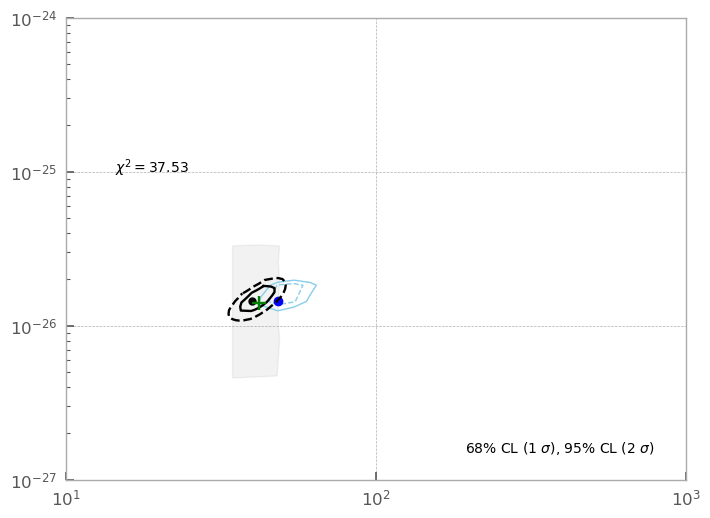

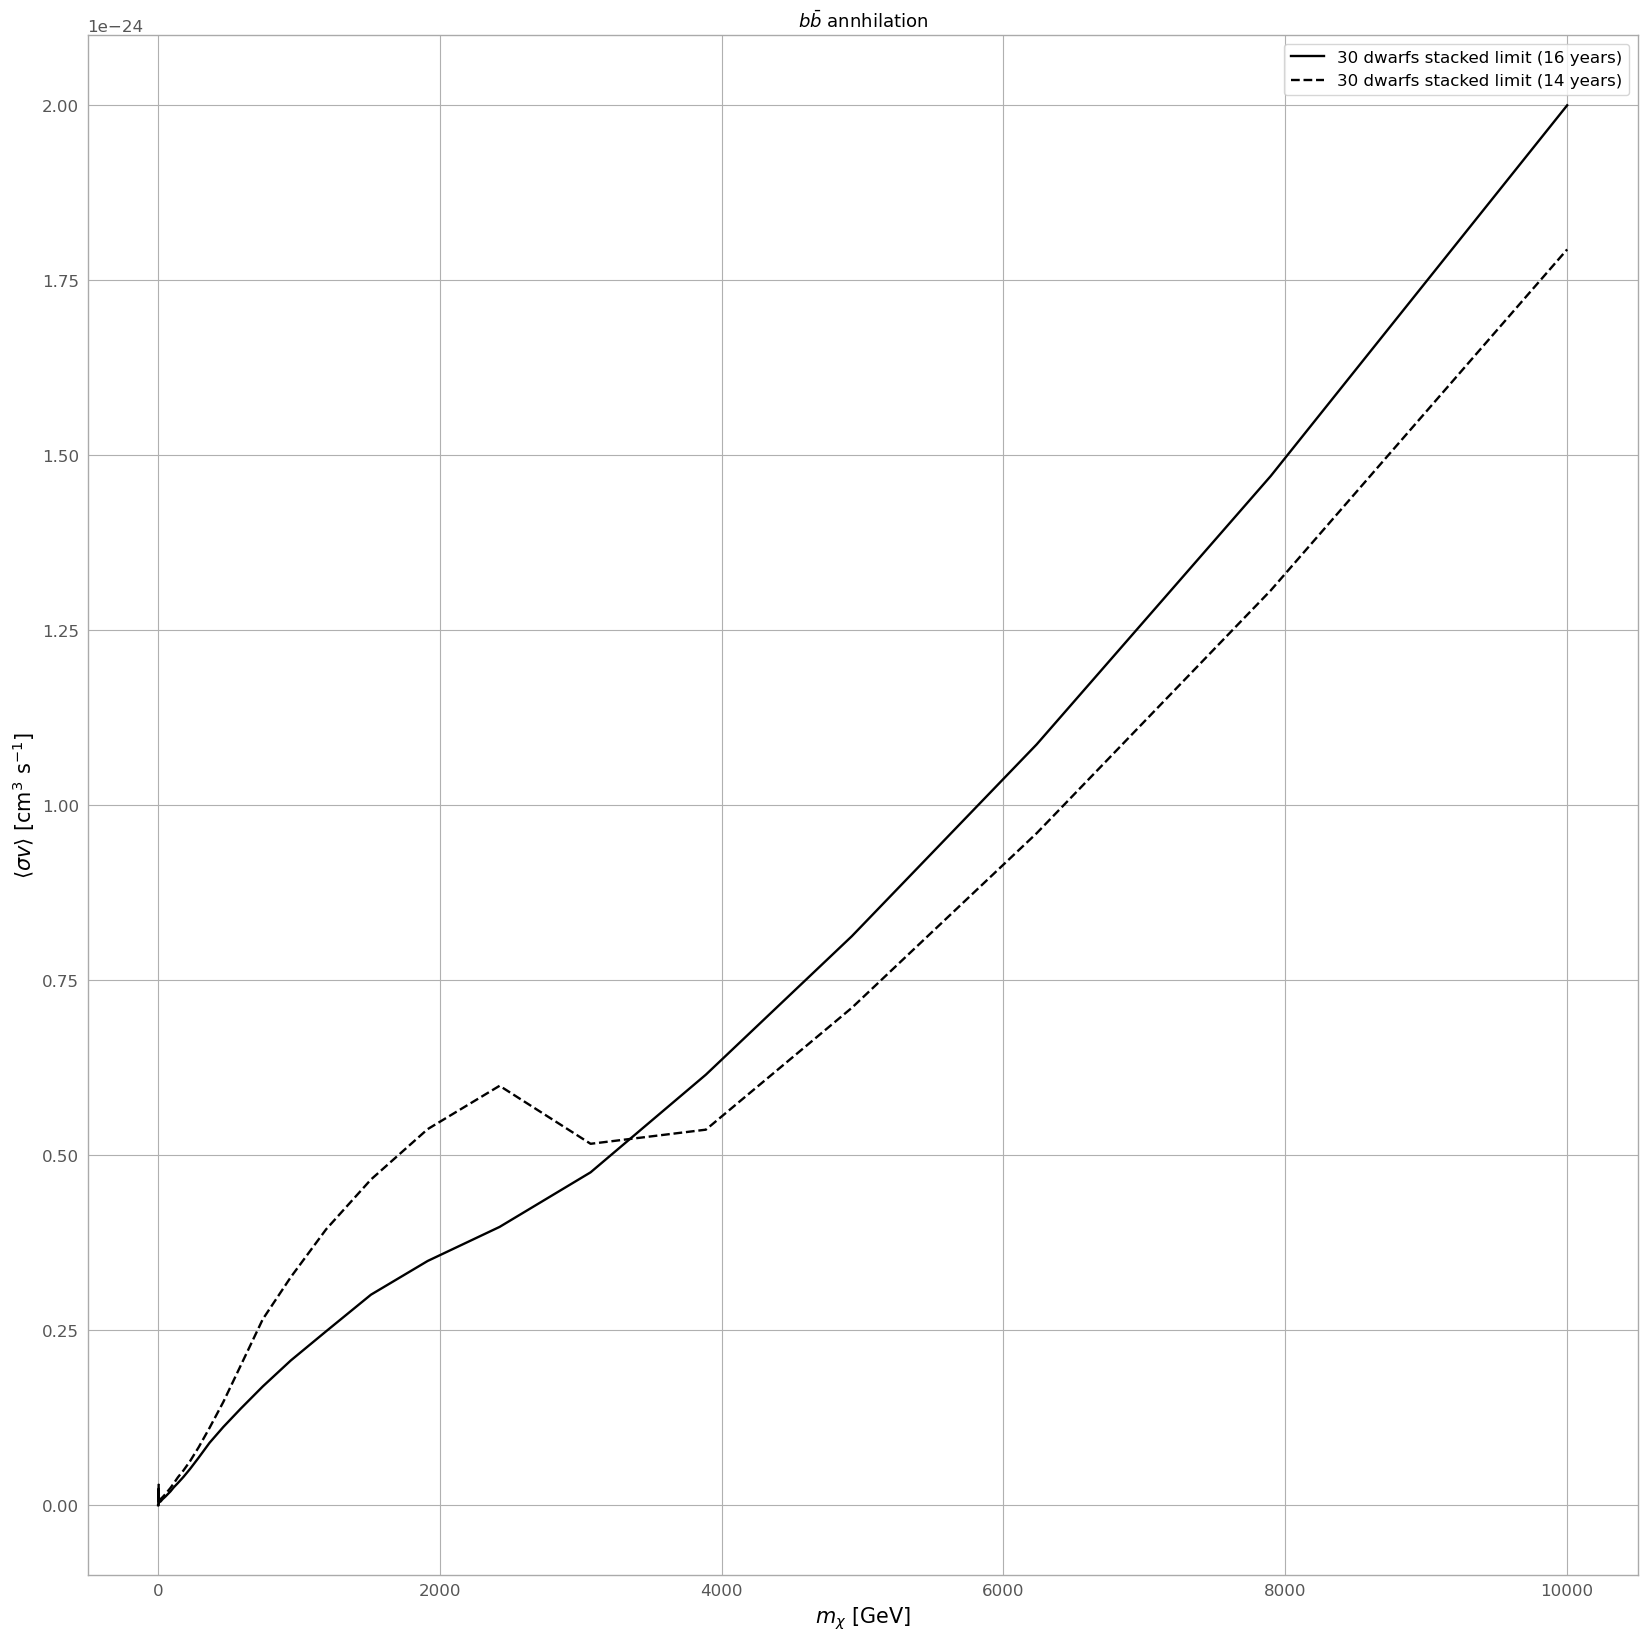

In [ ]:
for front in ['front']:
    for energy_bin_length in ['17']:
        for model in ['X']:
            # front='front'
            # energy_bin_length='17'
            
            def chi_square_models(dm_mass, sigma_v, model):
                
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                J_factor=3.5251837158376415e+21 #Check needed
                sr=0.4288213187542626 #For ROI 40x40 masked innter |b| < 2 degree
                
                g=np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
            
                bin_length = int(energy_bin_length)
                
                emeans=g[0:, 0][0:bin_length]
                GCE_data=g[0:, 1][0:bin_length]
            
                
                # systematic_upper = (g[0:, 3] - g[0:, 1])[0:bin_length]
                # systematic_lower = (g[0:, 1] - g[0:, 2])[0:bin_length]
            
                statistical_uncertainty = g[0:, 2][0:bin_length]
                
                #d_u = (g[0:, 4] - g[0:, 1])#[0:14]
                #d_l = (g[0:, 1] - g[0:, 3])#[0:14]
                
             
                #prompt_dat=np.loadtxt(f'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/Events/DM{dm_mass}GeV_Med{med_mass}GeV_decayed_1/DM{dm_mass}GeV_Med{med_mass}GeV.dat')
                #prompt_dat = Interpolator(med_mass, dm_mass).interpolated_table()
                #prompt_dat = Interpolator(dm_mass).interpolated_table()
                prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') #EW yes and channel 10 is for tau, 13 for bb ew yes
                #prompt_dat = Interpolator(dm_mass).interpolated_table()
                
                J_factor=3.5251837158376415e+21 #Check needed
                sr=0.4288213187542626
            
                #data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value='extrapolate', bounds_error=False, kind='linear')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
                data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
                #data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='cubic')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
            
                #data = emeans**2*data(emeans)*(sigma_v/(dm_mass**2))*J_factor/(2*sr)
            
                data = data(emeans)
                data = emeans**2*data*(sigma_v/(dm_mass**2))*J_factor/(sr)
                
                #GCE_data_err = np.where(data > GCE_data, systematic_upper, systematic_lower)
            
                #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
                #for i in range(0, len(emeans), 1):
                    #GCE_data_err[i] = np.max([d_u[i], d_l[i]])
                #data = data[0:bin_length]
                #GCE_data = GCE_data[0:bin_length]
                
                #cov=(np.diag(GCE_data_err[0:17])**2 + np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + np.load("/home/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix.npy"))
                cov=np.diag(statistical_uncertainty[0:bin_length])**2 + (np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy") )
                #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + np.diag(variances_direct))
                inv_cov=np.linalg.inv(cov)
            
            
                
                delta = data - GCE_data
                return delta.T@inv_cov@delta    #return np.sum(((GCE_data - data)/(GCE_data_err))**2)
            
            #model='X'
            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            warnings.filterwarnings("ignore")
            
            sigmav_vec=np.logspace(-27, -25, 20)
            
            mass_vec = np.logspace(np.log10(10), np.log10(100), 20)
            
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec=np.vectorize(chi_square)
            
            
            
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            
            min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm=DM_mass[min_index_2d]
            best_fit_sigmav=Sigmav[min_index_2d]
            min_chi2=chi_square(best_fit_dm, best_fit_sigmav)
            
            
            one_sigma_threshold=min_chi2 + 2.30
            two_sigma_threshold=min_chi2 + 6.18
            
            chi_square_results=chi_square_vec(DM_mass, Sigmav)
            
            
            
            plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
            #plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model combined')
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work, model {model} {front} data (16yr data)')

            
            plt.yscale('log')
            plt.xscale('log')
            plt.tick_params(axis='both', which='major',
                       direction='in', length=6, width=1.2)
        
            plt.tick_params(axis='both', which='minor',
                           direction='in', length=3, width=0.8)      
            ax = plt.gca()                # 현재 Axes 가져오기
    
            # ── minor tick 생성 ─────────────────────────────────
            ax.xaxis.set_minor_locator(AutoMinorLocator()) 
            plt.xlim(10, 1000)
            plt.ylim(1e-27, 1e-24)
            
            
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid
            
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
                     verticalalignment='bottom', horizontalalignment='right',
                     transform=plt.gca().transAxes)
            plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
                     verticalalignment='top', horizontalalignment='right',
                     transform=plt.gca().transAxes)
            
            #plt.text(0.2, 0.90, r'$b \bar{b}$', fontsize=15, color='black',
            #plt.text(0.2, 0.90, r'$b \bar{b}$', fontsize=15, color='black',
            
            # plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',
            
            #          verticalalignment='top', horizontalalignment='left',
            #          transform=plt.gca().transAxes)
            
            
            import matplotlib.pyplot as plt
            import pandas as pd
            
            solid_line_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2112fig18left_solid_line.txt', delim_whitespace=True)
            solid_line_x = solid_line_data['x']
            solid_line_y = solid_line_data['y']*(10**-26)
            
            dashed_line_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2112fig18left_dashed_line.txt', delim_whitespace=True)
            dashed_line_x = dashed_line_data['x']
            dashed_line_y = dashed_line_data['y']*(10**-26)
            
            point_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2112fig18left_best_fit_point.txt', delim_whitespace=True)
            point_x = point_data['x']
            point_y = point_data['y']*(10**-26)
            
            rectangle_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2101fig10right_DMdensity.txt', delim_whitespace=True)
            rectangle_x = rectangle_data['x']
            rectangle_y = rectangle_data['y']
            
            point2_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs.txt', delim_whitespace=True)
            point2_x = point2_data['x']
            point2_y = point2_data['y']
            
            errorbar_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs_errorbar.txt', delim_whitespace=True)
            error_x = errorbar_data['x']
            error_y = errorbar_data['y']
            error_yerr = errorbar_data['yerr']
            
            plt.plot(solid_line_x, solid_line_y, linestyle='-', color='black')
            plt.plot(dashed_line_x, dashed_line_y, linestyle='--', color='black')
            plt.scatter(point_x, point_y, color='black', zorder=5, marker='.', label='I. Cholis (2022)', s=100)
            
            plt.scatter(point2_x, point2_y, color='green', label='D. Mauro (2021)', zorder=5, marker='+', s=100)
            plt.fill(rectangle_x, rectangle_y, color='gray', alpha=0.1, label='Boundary Area')
            plt.figure(figsize=(20, 20))
            ulm=np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bb_16yr_30_dSphs.txt')
            plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (16 years)', color='black')
            ulm=np.loadtxt('/home/sanghwan/FermiLAT/Sanghwan/Fermipy_dSphs/DM_limit/bb_14yr_30_dSphs.txt')
            plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit (14 years)', color='black', linestyle='dashed')
            plt.legend()

            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            #plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}_tau_16yr.png', bbox_inches='tight', dpi=300)
            plt.title(r"$b \bar{b}$ annhilation", fontsize=13)

            plt.show()
            
            
                
                
                


In [ ]:
1e-8, 1e-5, 300

(1e-08, 1e-05, 300)

In [ ]:
1e-15, 1e-2, 100

(1e-15, 0.01, 100)

In [ ]:
best_fit_dm, best_fit_sigmav

(48.32930238571752, 1.438449888287666e-26)

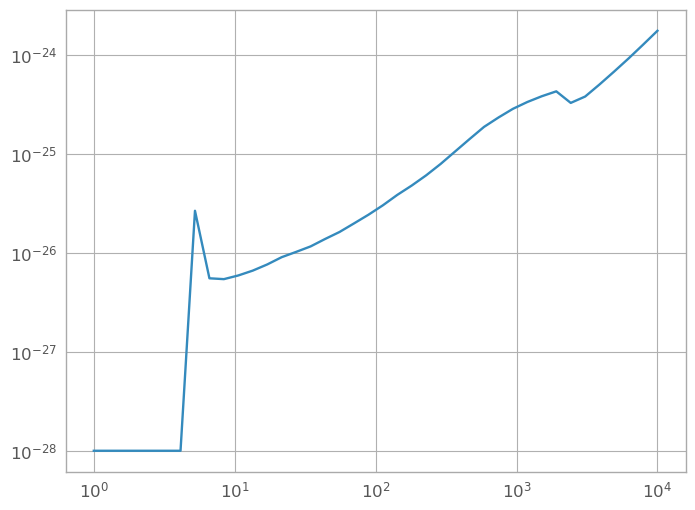

In [ ]:
plt.loglog(mauro[0:, 0], mauro[0:, 1], label='Di Mauro (14yr data)')


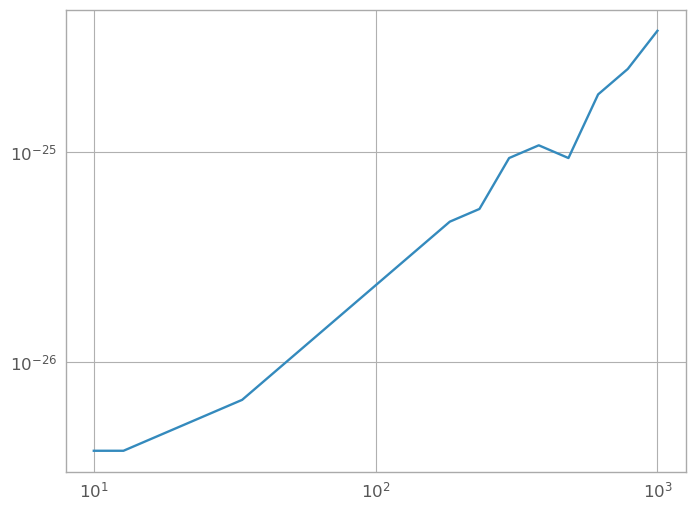

In [ ]:
plt.loglog(ulm[0], ulm[1])


In [ ]:
ulm[1]

array([3.76493581e-27, 3.76493581e-27, 4.32876128e-27, 4.97702356e-27,
       5.72236766e-27, 6.57933225e-27, 8.69749003e-27, 1.14975700e-26,
       1.51991108e-26, 2.00923300e-26, 2.65608778e-26, 3.51119173e-26,
       4.64158883e-26, 5.33669923e-26, 9.32603347e-26, 1.07226722e-25,
       9.32603347e-26, 1.87381742e-25, 2.47707636e-25, 3.76493581e-25])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


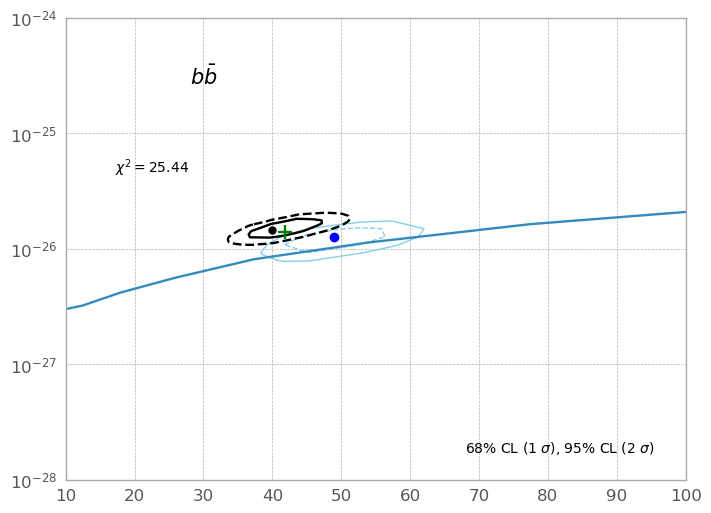

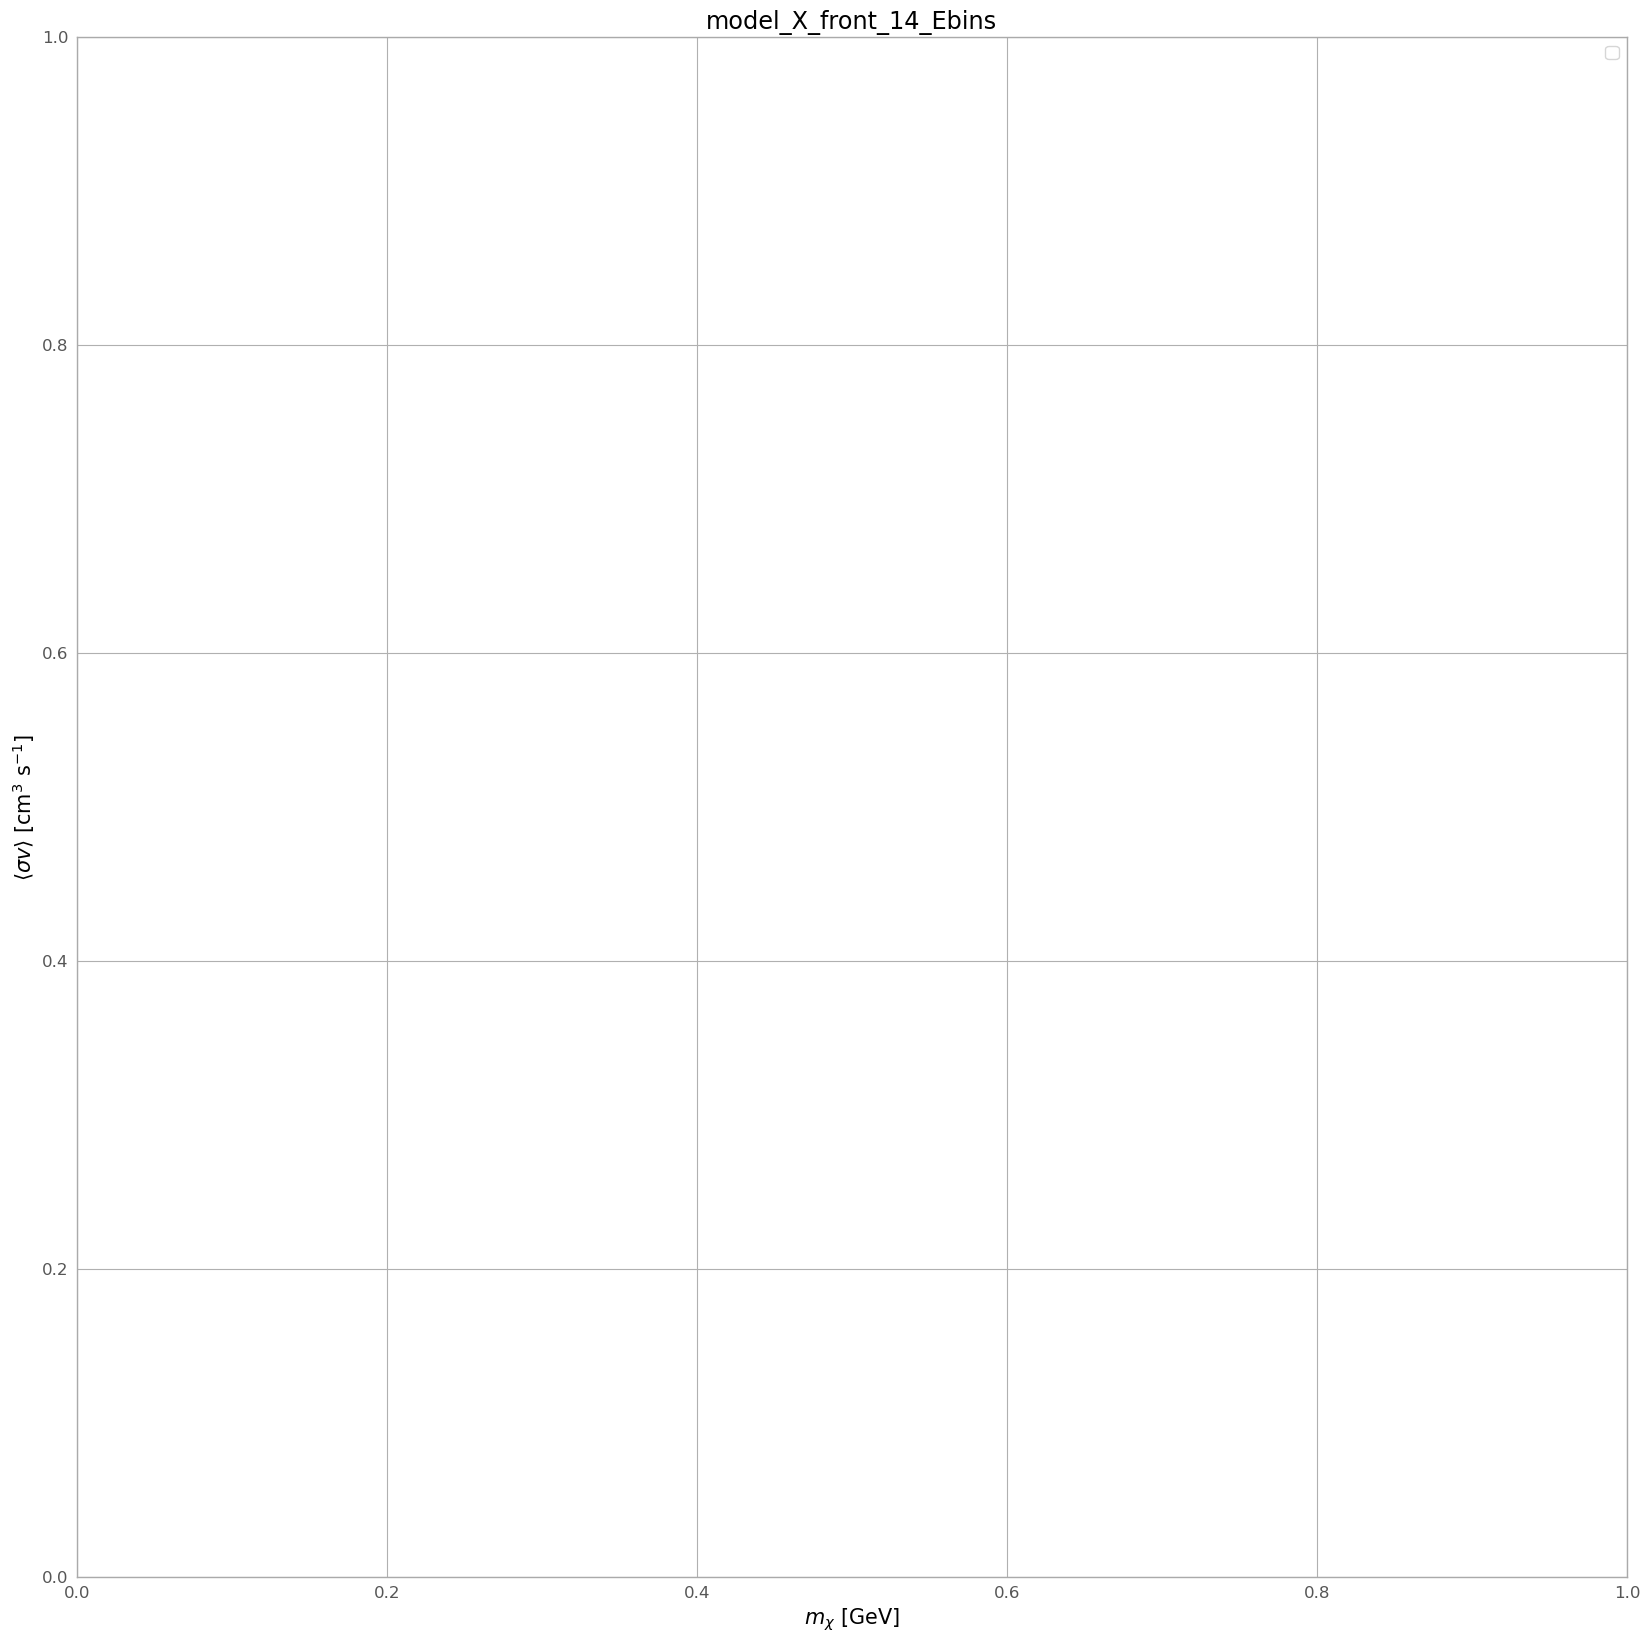

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


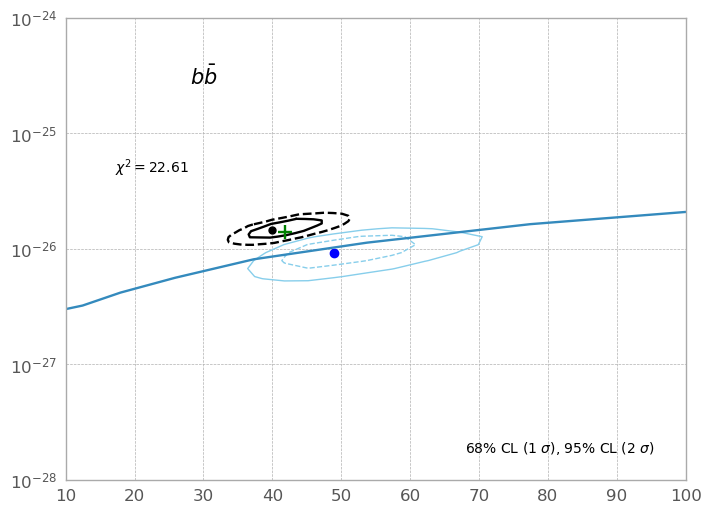

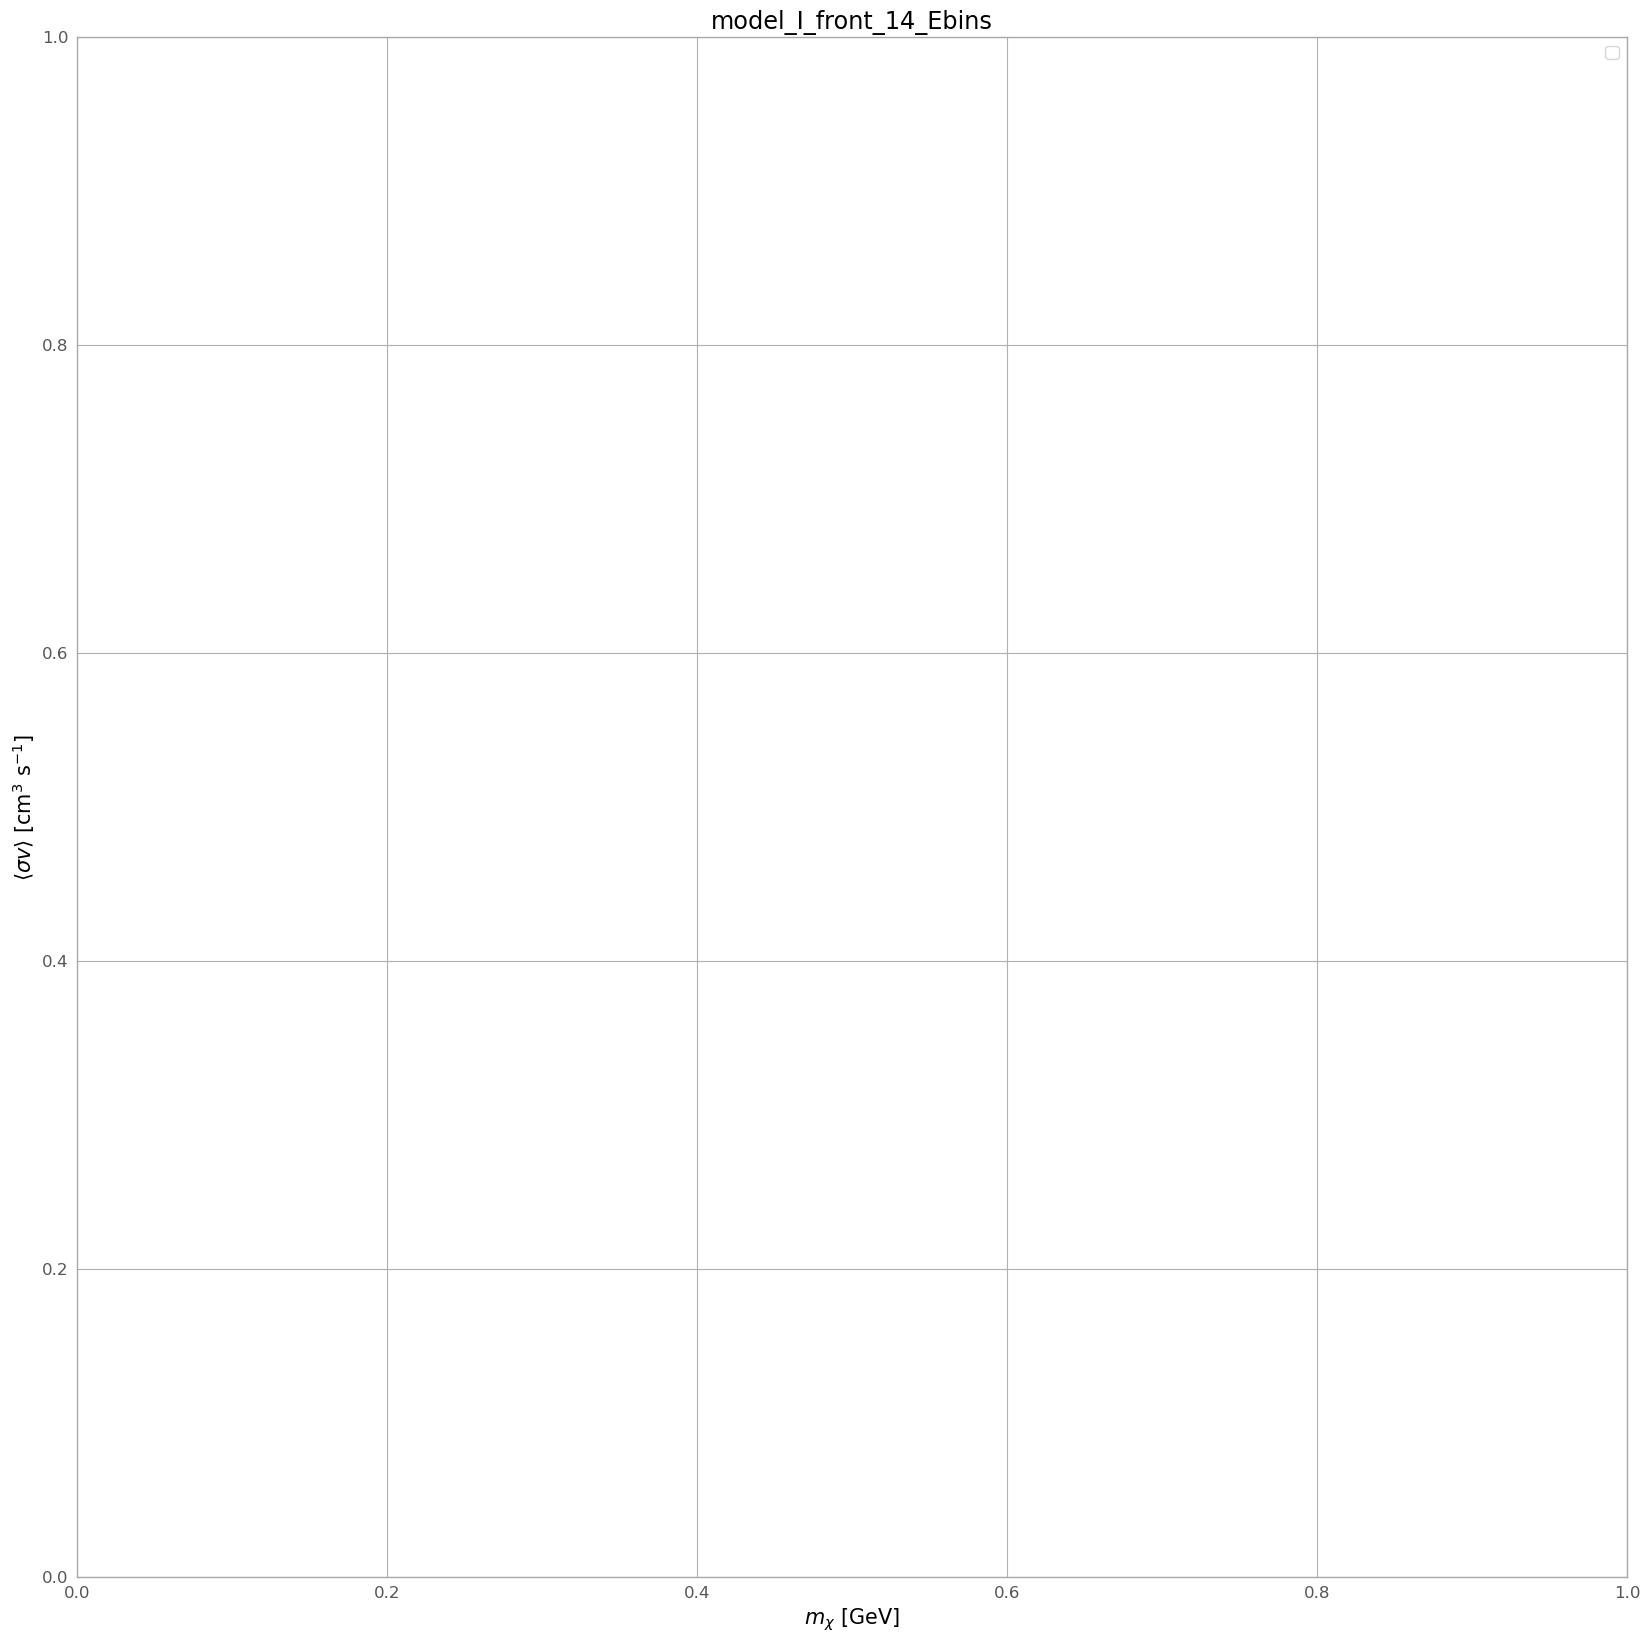

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


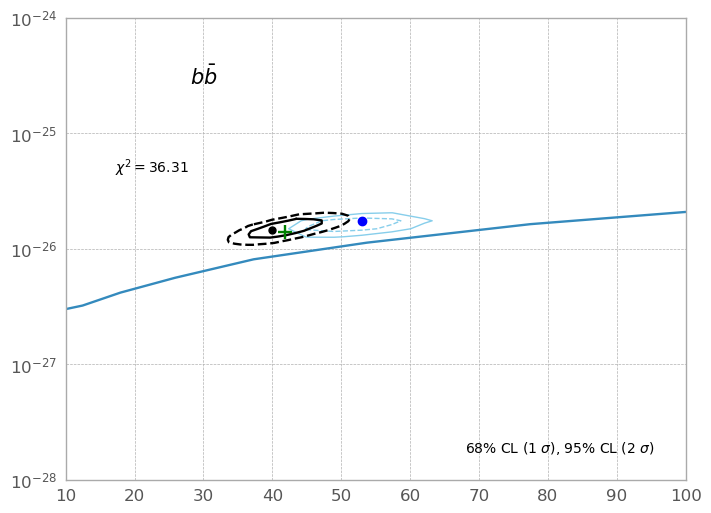

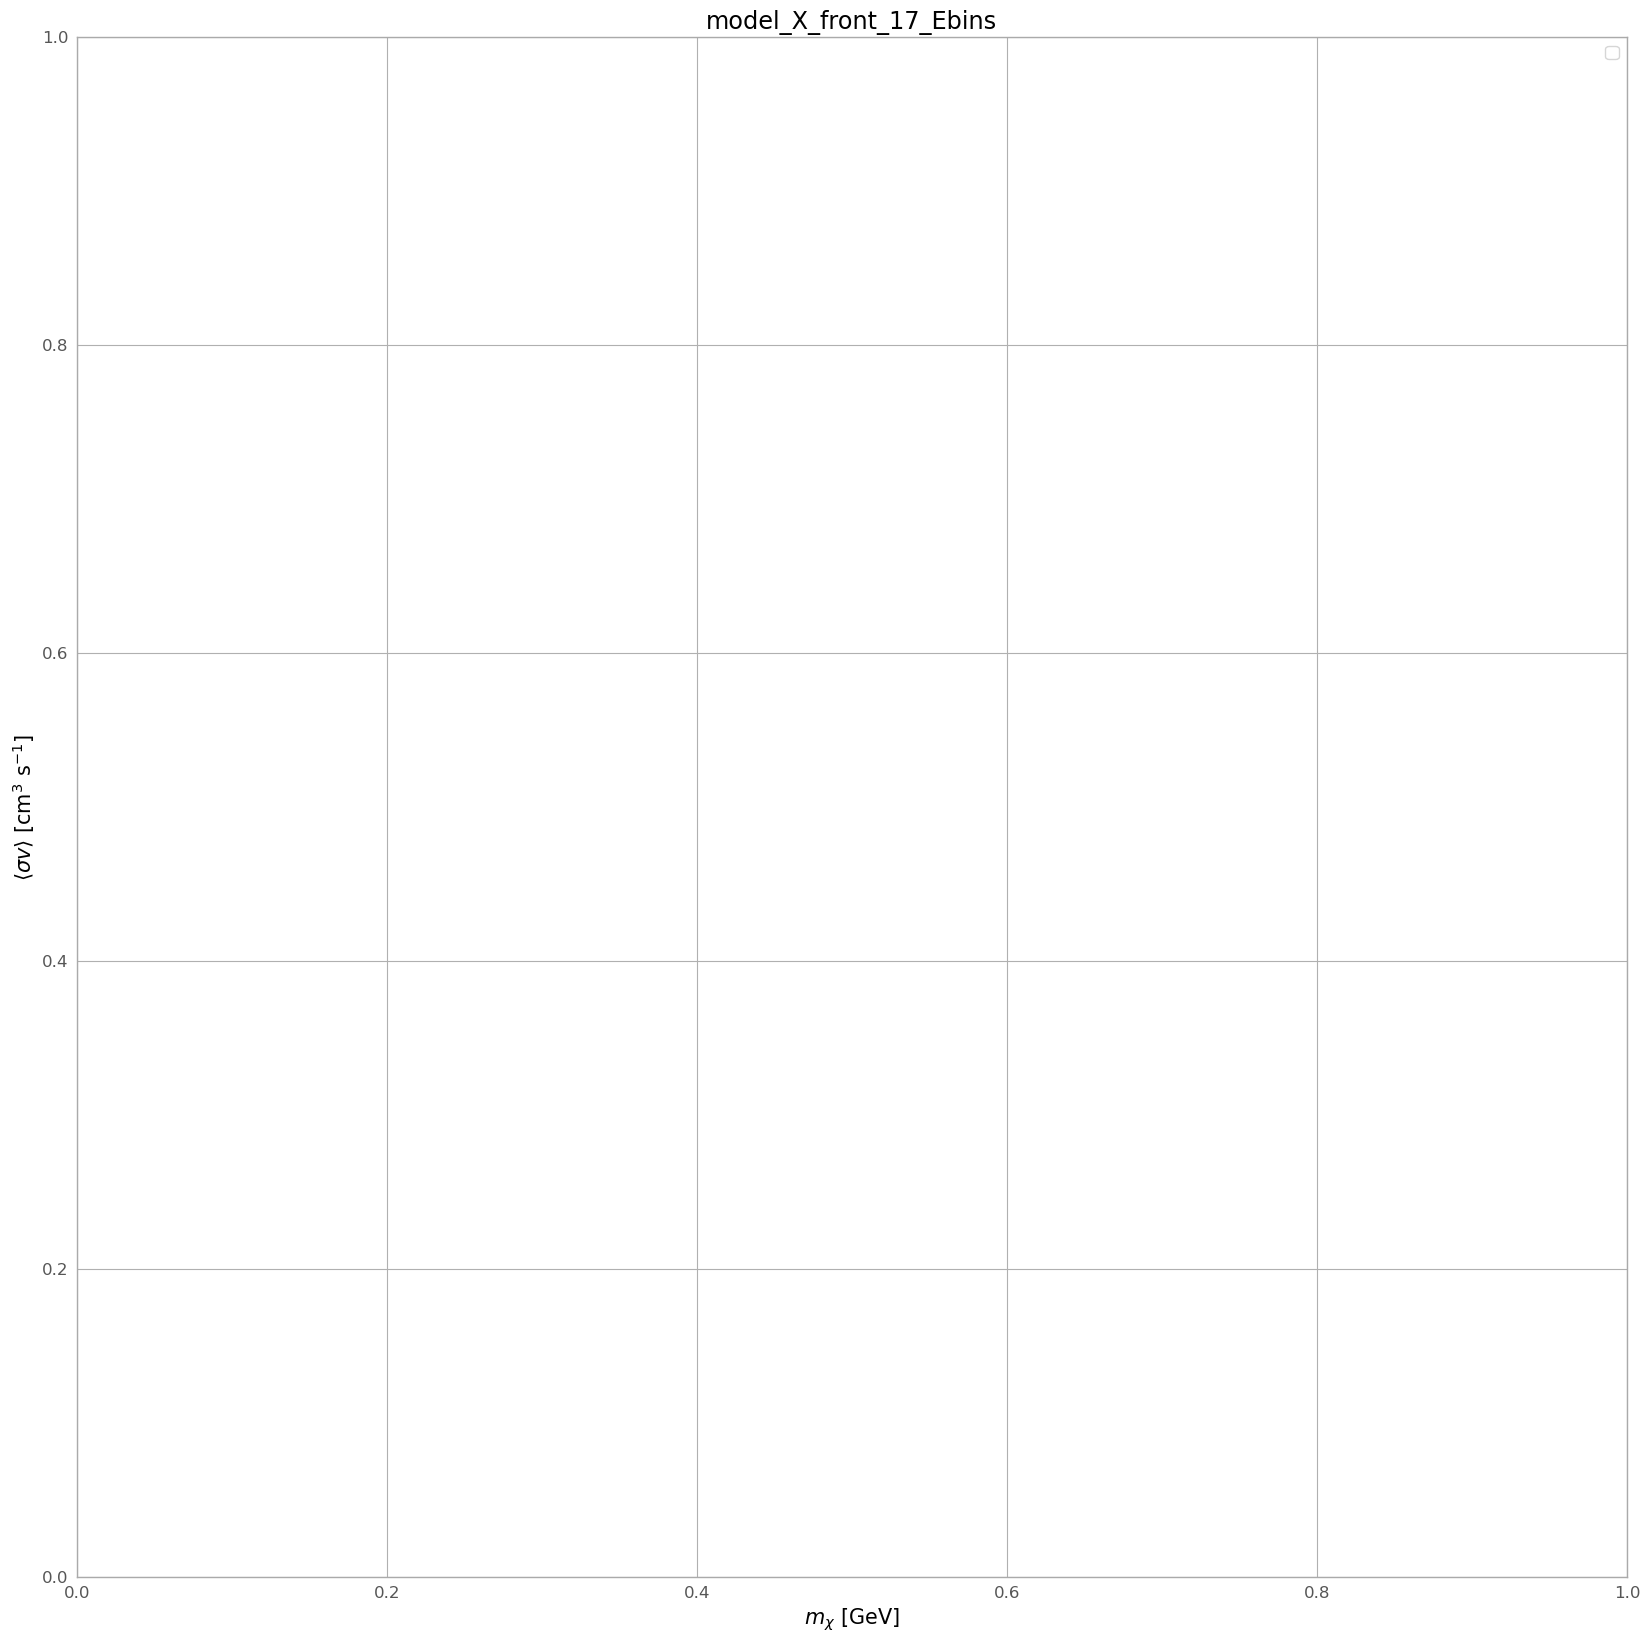

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


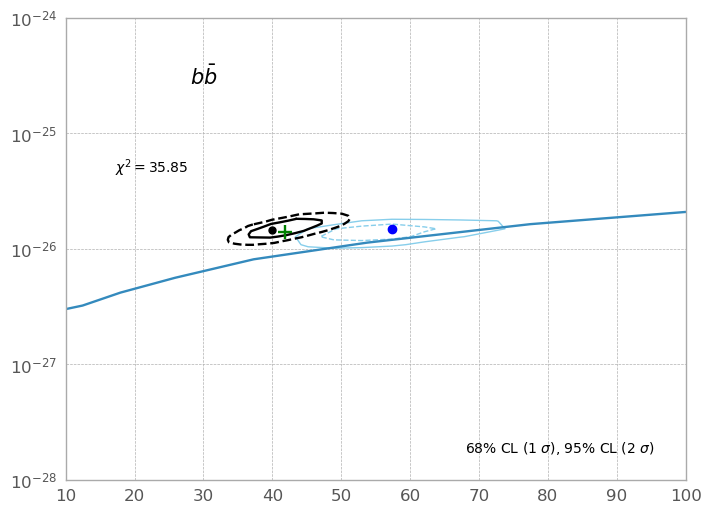

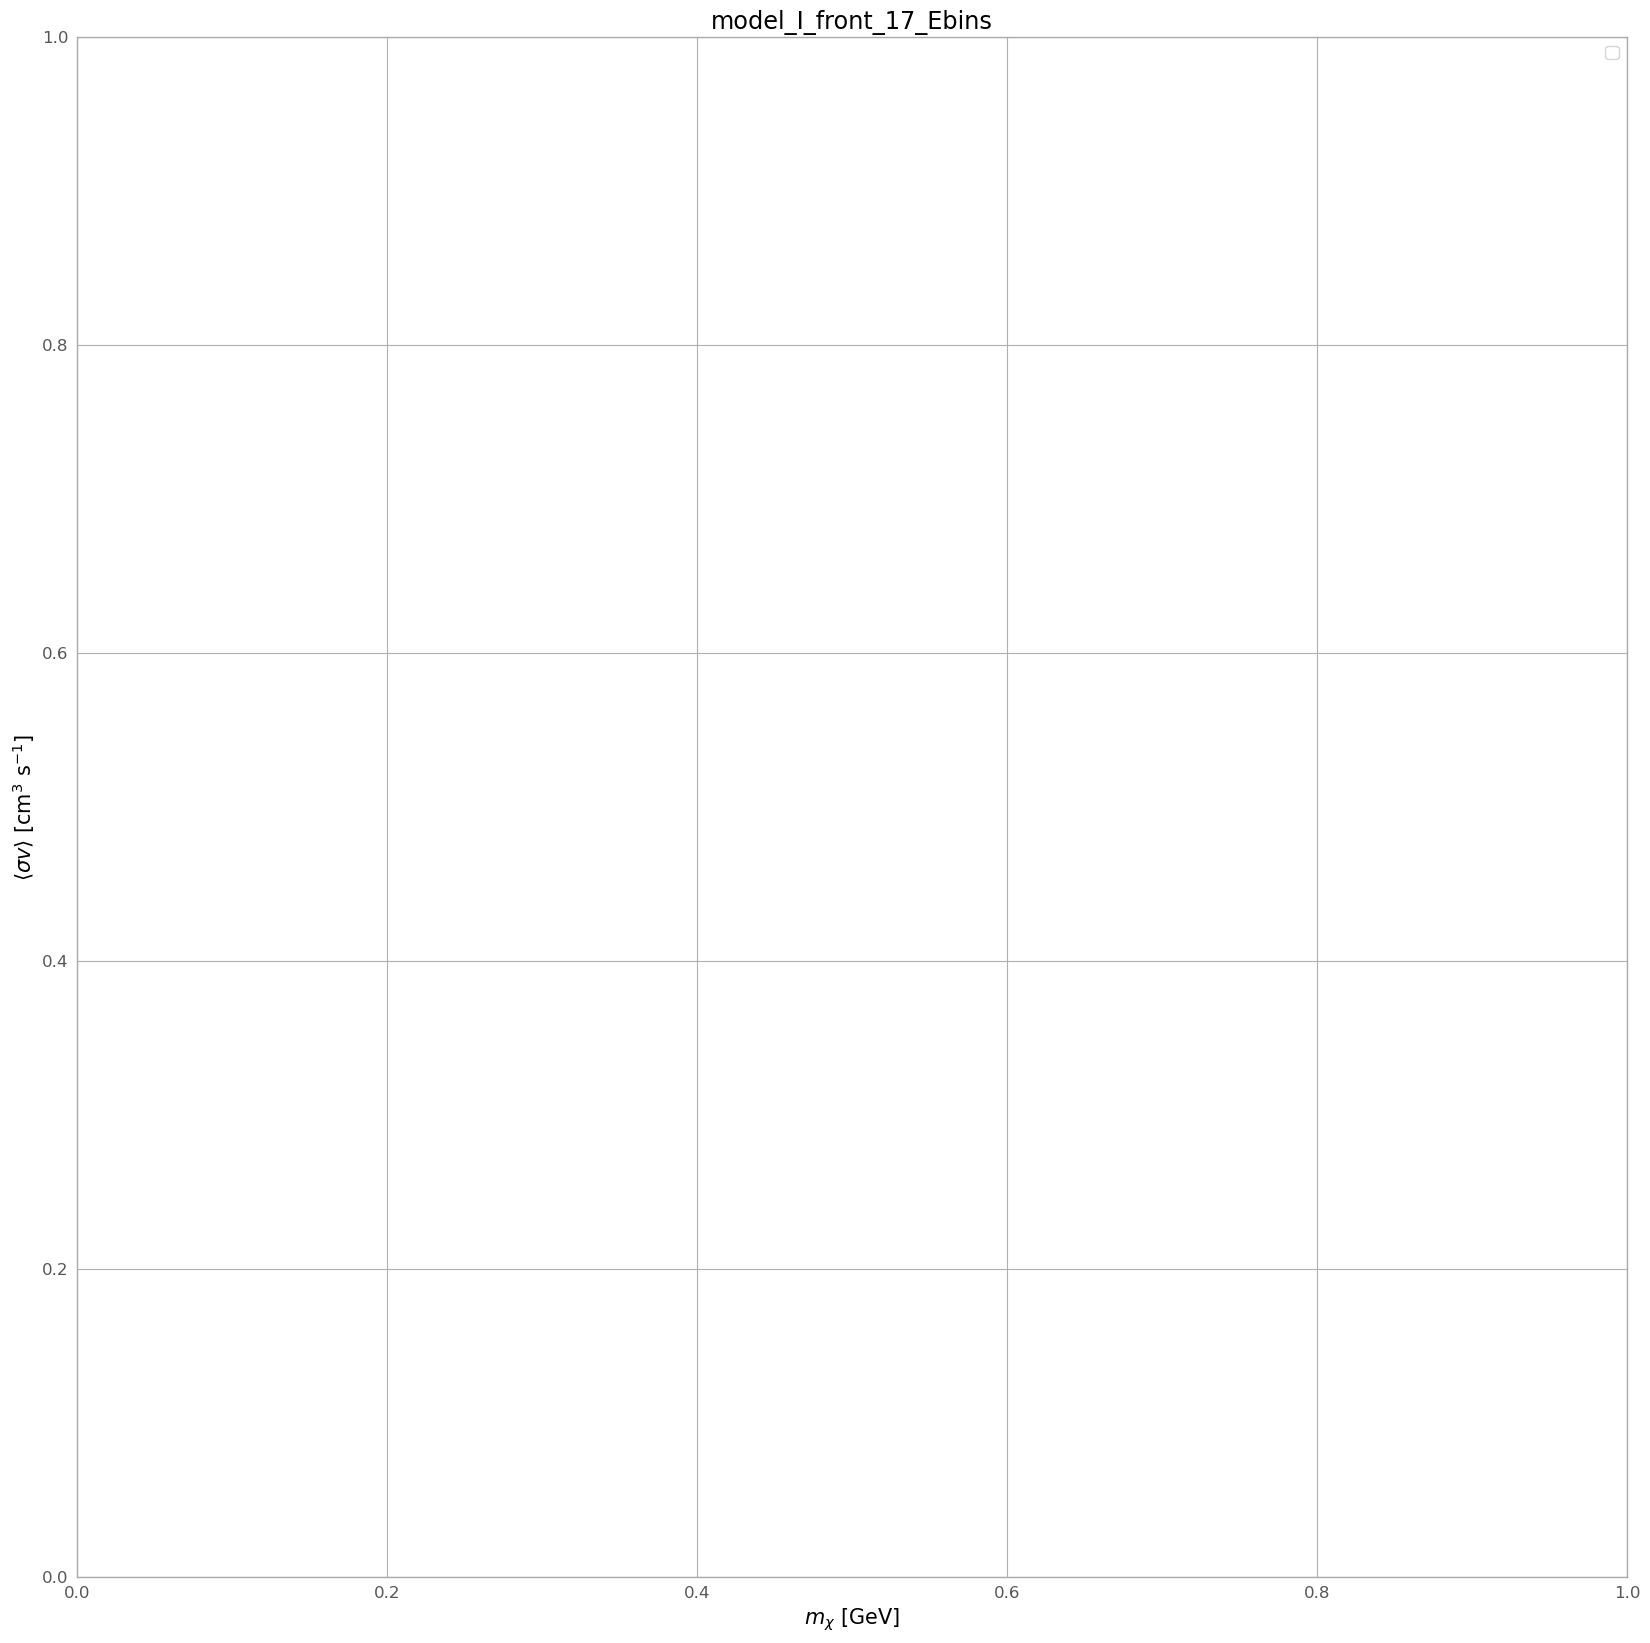

KeyboardInterrupt: 

In [ ]:
for front in ['front', 'front_back']:
    for energy_bin_length in ['14', '17']:
        for model in ['X', 'I']:
            # front='front'
            # energy_bin_length='17'
            
            def chi_square_models(dm_mass, sigma_v, model):
                
                warnings.simplefilter("ignore", category=RuntimeWarning)  
                J_factor=3.5251837158376415e+21 #Check needed
                sr=0.4288213187542626 #For ROI 40x40 masked innter |b| < 2 degree
                
                g=np.loadtxt(f'/home/sanghwan/FermiLAT/Sanghwan/GCE_model_{model}_{front}_16yr_cholis.dat')
            
                bin_length = int(energy_bin_length)
                
                emeans=g[0:, 0][0:bin_length]
                GCE_data=g[0:, 1][0:bin_length]
            
                
                # systematic_upper = (g[0:, 3] - g[0:, 1])[0:bin_length]
                # systematic_lower = (g[0:, 1] - g[0:, 2])[0:bin_length]
            
                statistical_uncertainty = g[0:, 2][0:bin_length]
                
                #d_u = (g[0:, 4] - g[0:, 1])#[0:14]
                #d_l = (g[0:, 1] - g[0:, 3])#[0:14]
                
             
                #prompt_dat=np.loadtxt(f'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/Events/DM{dm_mass}GeV_Med{med_mass}GeV_decayed_1/DM{dm_mass}GeV_Med{med_mass}GeV.dat')
                #prompt_dat = Interpolator(med_mass, dm_mass).interpolated_table()
                #prompt_dat = Interpolator(dm_mass).interpolated_table()
                prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') #EW yes and channel 10 is for tau, 13 for bb ew yes
                #prompt_dat = Interpolator(dm_mass).interpolated_table()
                
                J_factor=3.5251837158376415e+21 #Check needed
                sr=0.4288213187542626
            
                #data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value='extrapolate', bounds_error=False, kind='linear')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
                data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
                #data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='cubic')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
            
                #data = emeans**2*data(emeans)*(sigma_v/(dm_mass**2))*J_factor/(2*sr)
            
                data = data(emeans)
                data = emeans**2*data*(sigma_v/(dm_mass**2))*J_factor/(sr)
                
                #GCE_data_err = np.where(data > GCE_data, systematic_upper, systematic_lower)
            
                #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
                #for i in range(0, len(emeans), 1):
                    #GCE_data_err[i] = np.max([d_u[i], d_l[i]])
                #data = data[0:bin_length]
                #GCE_data = GCE_data[0:bin_length]
                
                #cov=(np.diag(GCE_data_err[0:17])**2 + np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + np.load("/home/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix.npy"))
                cov=np.diag(statistical_uncertainty[0:bin_length])**2 + (np.load(f"/home/sanghwan/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_{energy_bin_length}x{energy_bin_length}_{front}{'_model_I'}_16yr.npy") )
                #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + np.diag(variances_direct))
                inv_cov=np.linalg.inv(cov)
            
            
                
                delta = data - GCE_data
                return delta.T@inv_cov@delta    #return np.sum(((GCE_data - data)/(GCE_data_err))**2)
            
            #model='X'
            def chi_square(dm_mass, sigmav):
                return chi_square_models(dm_mass, sigmav, model)
            warnings.filterwarnings("ignore")
            
            sigmav_vec=np.logspace(-27, -25, 30)
            
            mass_vec = np.logspace(np.log10(10), np.log10(100), 30)
            
            
            DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
            chi_square_vec=np.vectorize(chi_square)
            
            
            
            chi_square_values = chi_square_vec(DM_mass, Sigmav)
            
            
            min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
            min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
            best_fit_dm=DM_mass[min_index_2d]
            best_fit_sigmav=Sigmav[min_index_2d]
            min_chi2=chi_square(best_fit_dm, best_fit_sigmav)
            
            
            one_sigma_threshold=min_chi2 + 2.30
            two_sigma_threshold=min_chi2 + 6.18
            
            chi_square_results=chi_square_vec(DM_mass, Sigmav)
            
            
            
            plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
            #plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model combined')
            plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024)')

            ulm_16 = np.loadtxt('./all_sky/Dwarf_galaxy_data/Upper_limit_data/bb_16yr.dat')
            ulm_14 = np.loadtxt('./all_sky/Dwarf_galaxy_data/Upper_limit_data/bb_14yr.dat')
            plt.plot(ulm_16[0], ulm_16[1], label='30 dSphs upper limit (16yr data)')
            plt.yscale('log')
            plt.xscale('linear')
            
            plt.xlim(10, 100)
            plt.ylim(1e-28, 1e-24)
            
            #plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')
            
            plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid
            
            plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
                     verticalalignment='bottom', horizontalalignment='right',
                     transform=plt.gca().transAxes)
            plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
                     verticalalignment='top', horizontalalignment='right',
                     transform=plt.gca().transAxes)
            
            #plt.text(0.2, 0.90, r'$b \bar{b}$', fontsize=15, color='black',
            plt.text(0.2, 0.90, r'$b \bar{b}$', fontsize=15, color='black',
            
            #plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',
            
                     verticalalignment='top', horizontalalignment='left',
                     transform=plt.gca().transAxes)
            
            
            import matplotlib.pyplot as plt
            import pandas as pd
            
            solid_line_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2112fig18left_solid_line.txt', delim_whitespace=True)
            solid_line_x = solid_line_data['x']
            solid_line_y = solid_line_data['y']*(10**-26)
            
            dashed_line_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2112fig18left_dashed_line.txt', delim_whitespace=True)
            dashed_line_x = dashed_line_data['x']
            dashed_line_y = dashed_line_data['y']*(10**-26)
            
            point_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2112fig18left_best_fit_point.txt', delim_whitespace=True)
            point_x = point_data['x']
            point_y = point_data['y']*(10**-26)
            
            rectangle_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2101fig10right_DMdensity.txt', delim_whitespace=True)
            rectangle_x = rectangle_data['x']
            rectangle_y = rectangle_data['y']
            
            point2_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs.txt', delim_whitespace=True)
            point2_x = point2_data['x']
            point2_y = point2_data['y']
            
            errorbar_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs_errorbar.txt', delim_whitespace=True)
            error_x = errorbar_data['x']
            error_y = errorbar_data['y']
            error_yerr = errorbar_data['yerr']
            
            plt.plot(solid_line_x, solid_line_y, linestyle='-', color='black')
            plt.plot(dashed_line_x, dashed_line_y, linestyle='--', color='black')
            plt.scatter(point_x, point_y, color='black', zorder=5, marker='.', label='I. Cholis (2022)', s=100)
            
            plt.scatter(point2_x, point2_y, color='green', label='D. Mauro (2021)', zorder=5, marker='+', s=100)
            # plt.fill(rectangle_x, rectangle_y, color='gray', alpha=0.1, label='Boundary Area')
            plt.figure(figsize=(20, 20))
            plt.title(f"model_{model}_{front}_{energy_bin_length}_Ebins")
            plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
            plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
            plt.legend()
            plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}_bb_16yr_comparison.png', bbox_inches='tight', dpi=300)
            plt.show()
            
            #plt.title("DM interpretation of GCE for model I", fontsize=13)
            
                
                
                


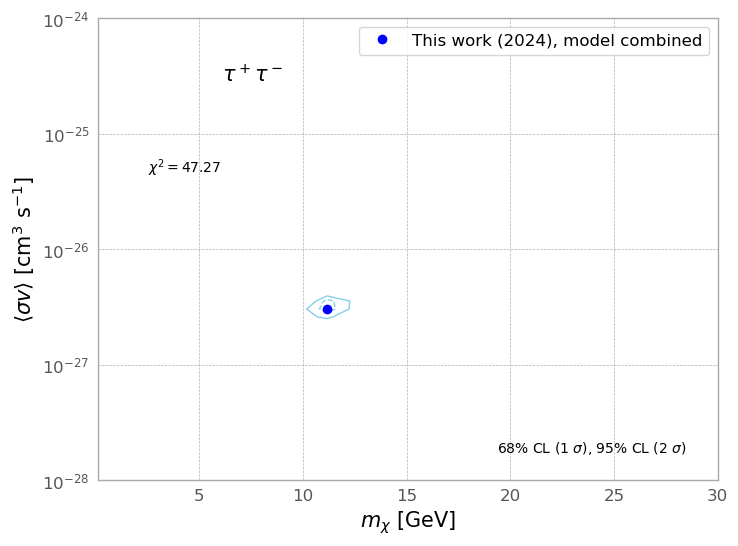

In [ ]:
model='X'
def chi_square(dm_mass, sigmav):
    return chi_square_models(dm_mass, sigmav, model)
warnings.filterwarnings("ignore")

sigmav_vec=np.logspace(-27, -25, 30)

mass_vec = np.logspace(np.log10(0.1), np.log10(50), 30)


DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
chi_square_vec=np.vectorize(chi_square)



chi_square_values = chi_square_vec(DM_mass, Sigmav)


min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
best_fit_dm=DM_mass[min_index_2d]
best_fit_sigmav=Sigmav[min_index_2d]
min_chi2=chi_square(best_fit_dm, best_fit_sigmav)


one_sigma_threshold=min_chi2 + 2.30
two_sigma_threshold=min_chi2 + 6.18

chi_square_results=chi_square_vec(DM_mass, Sigmav)



plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model combined')


plt.yscale('log')
plt.xscale('linear')

plt.xlim(0.1, 30)
plt.ylim(1e-28, 1e-24)

#plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

#plt.text(0.2, 0.90, r'$b \bar{b}$', fontsize=15, color='black',
plt.text(0.2, 0.90, r'$\tau^+ \tau^-$', fontsize=15, color='black',

#plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',

         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)


import matplotlib.pyplot as plt
import pandas as pd

# solid_line_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2112fig18left_solid_line.txt', delim_whitespace=True)
# solid_line_x = solid_line_data['x']
# solid_line_y = solid_line_data['y']*(10**-26)

# dashed_line_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2112fig18left_dashed_line.txt', delim_whitespace=True)
# dashed_line_x = dashed_line_data['x']
# dashed_line_y = dashed_line_data['y']*(10**-26)

# point_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2112fig18left_best_fit_point.txt', delim_whitespace=True)
# point_x = point_data['x']
# point_y = point_data['y']*(10**-26)

# rectangle_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references/2101fig10right_DMdensity.txt', delim_whitespace=True)
# rectangle_x = rectangle_data['x']
# rectangle_y = rectangle_data['y']

# point2_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs.txt', delim_whitespace=True)
# point2_x = point2_data['x']
# point2_y = point2_data['y']

# errorbar_data = pd.read_csv('/home/sanghwan/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs_errorbar.txt', delim_whitespace=True)
# error_x = errorbar_data['x']
# error_y = errorbar_data['y']
# error_yerr = errorbar_data['yerr']

# plt.plot(solid_line_x, solid_line_y, linestyle='-', color='black')
# plt.plot(dashed_line_x, dashed_line_y, linestyle='--', color='black')
# plt.scatter(point_x, point_y, color='black', zorder=5, marker='.', label='I. Cholis (2022)', s=100)

#plt.scatter(point2_x, point2_y, color='green', label='D. Mauro (2021)', zorder=5, marker='+', s=100)
#plt.fill(rectangle_x, rectangle_y, color='gray', alpha=0.1, label='Boundary Area')
#plt.figure(figsize=(20, 20))
plt.legend()

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}_tau_16yr.png', bbox_inches='tight', dpi=300)
plt.show()

#plt.title("DM interpretation of GCE for model I", fontsize=13)

    
    
    


In [ ]:
best_fit_dm, best_fit_sigmav

(11.155639876771923, 3.039195382313195e-27)

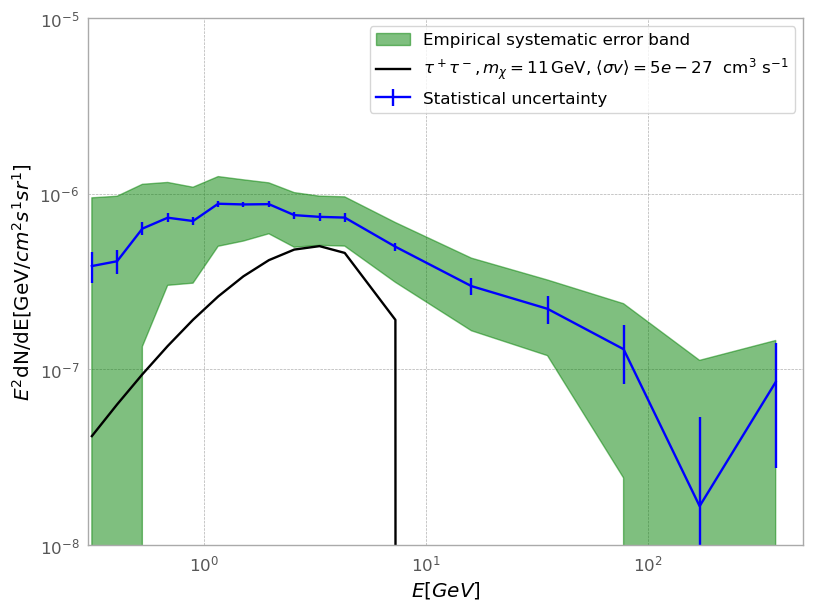

In [ ]:
#plt.errorbar(output[0:, 0], output[0:, 1], yerr=[sys_low, sys_upp], label='Max Min envelops', color='blue')
output = np.loadtxt('./GCE_model_X_front_16yr_cholis.dat')

cov = np.load('./GC_analysis/covariance/approx_covariance_17x17_16yr.npy')
plt.fill_between(output[0:, 0], output[0:, 1] - np.sqrt(np.diag(cov)), output[0:, 1] + np.sqrt(np.diag(cov)), color='green', alpha=0.5, label='Empirical systematic error band')

plt.errorbar(output[0:, 0], output[0:, 1], output[0:, 2], label='Statistical uncertainty', color='blue')

#plt.plot(Interpolator(78).interpolated_table()[0], Interpolator(78).interpolated_table()[0]**2*Interpolator(110).interpolated_table()[1]*(5e-26)/78**2 *3*10**21, label=r'4$b$ annihilation')

mass = 11
prompt_dat=exctractcirellitable(mass, 10, 'gammas', 'Yes') #EW yes and channel 10 is for tau, 13 for bb ew yes
#prompt_dat = Interpolator(mass).interpolated_table()
prompt_dat_interp = interp1d(prompt_dat[0], prompt_dat[1], bounds_error=False, fill_value=0)



plt.plot(output[0:, 0], output[0:, 0]**2*( prompt_dat_interp(output[0:, 0])/mass**2 )* 3*10**21 * 5e-27/0.4288213187542626, color='black',label=r'$ \tau^+ \tau^-, m_\chi = 11 \,$GeV, $\langle \sigma v \rangle = 5e-27$  cm$^3$ s$^{-1}$')

#plt.title("GCE fluxes with different GDE models", fontsize=14)
plt.xscale("log")  # Log-scale for Energy
plt.yscale("log")  # Log-scale for Flux
#plt.legend(fontsize=10)
plt.grid(True, which="major", linestyle="--", linewidth=0.5)
plt.ylim(1e-8, 1e-5)
plt.xlim(0.3, 500)
# Show the plot
plt.tight_layout()
plt.legend()

plt.ylabel(f'$E^2$dN/dE[GeV/$cm^2 s^1 sr^1$]')
plt.xlabel(f'$E[GeV$]')

plt.show()



In [ ]:
chi_square_models(45, 1e-26, 'X')

115.13975577964753

In [ ]:
front='front_back'
energy_bin_length='14' #'17'

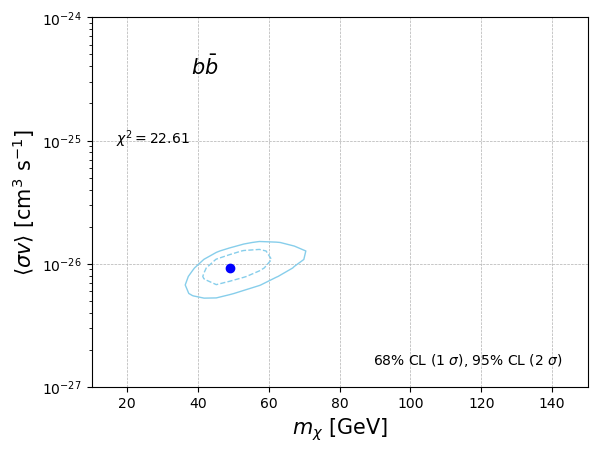

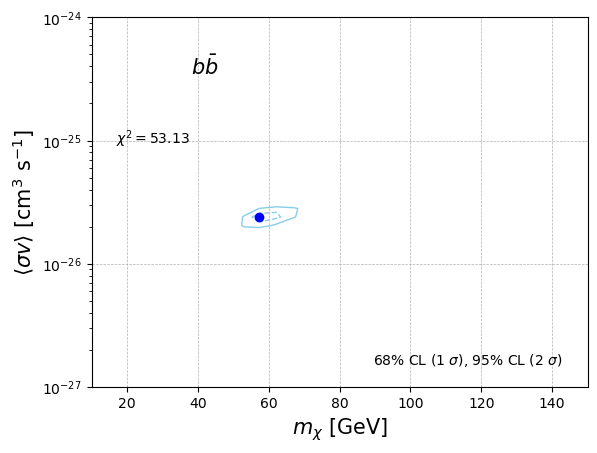

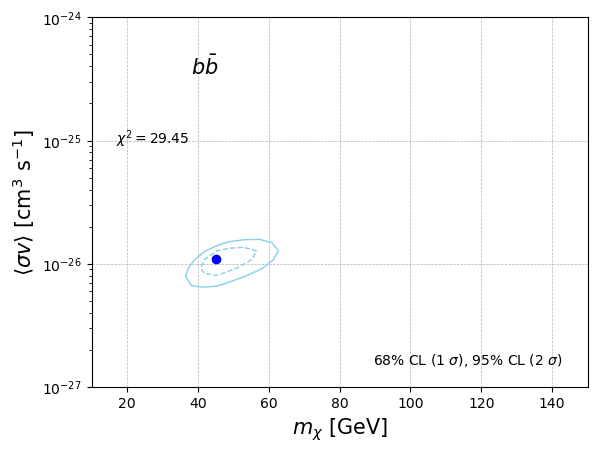

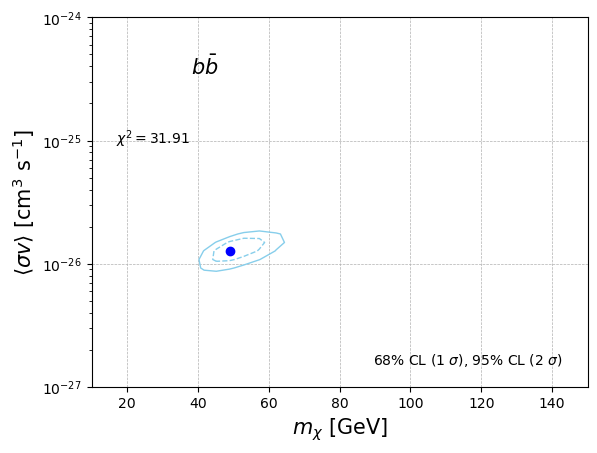

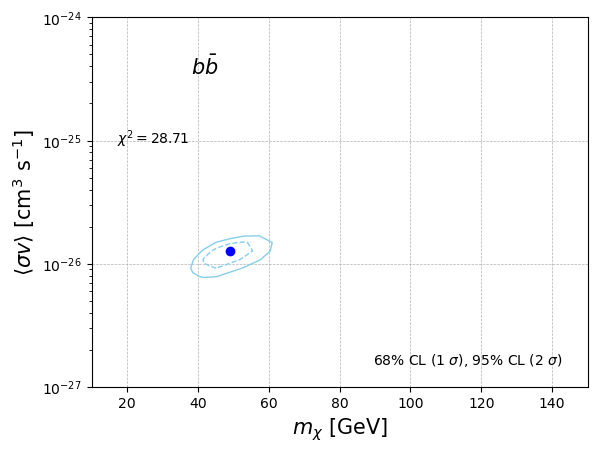

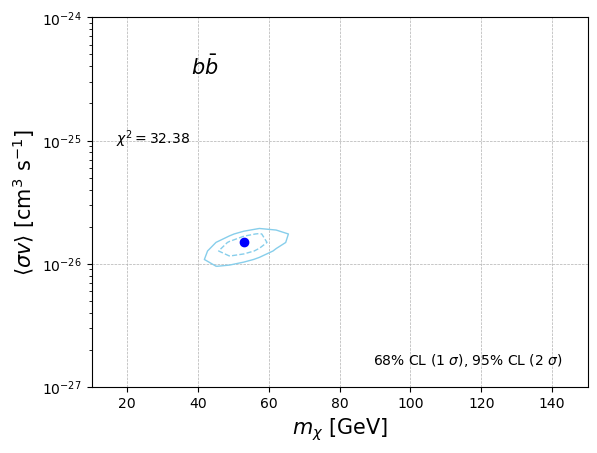

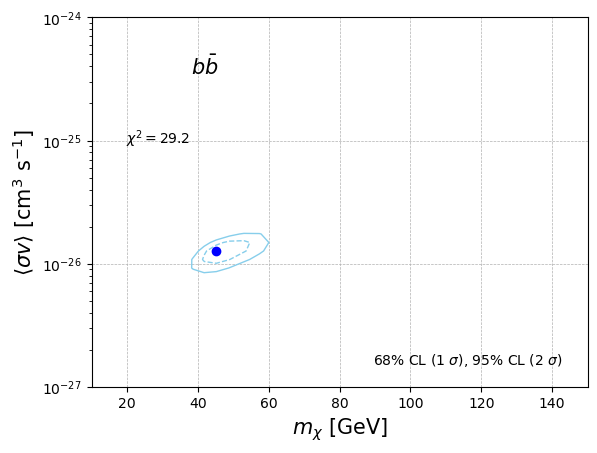

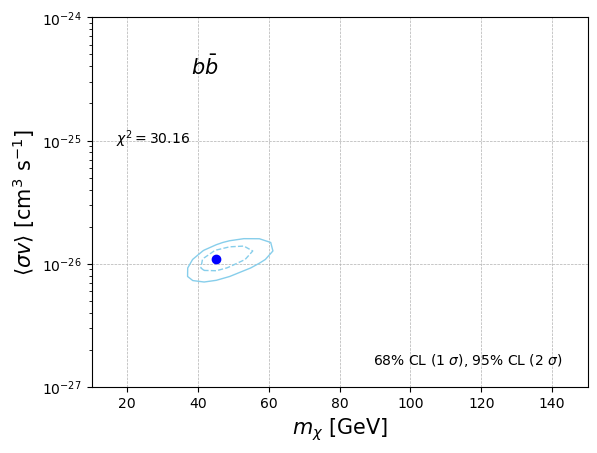

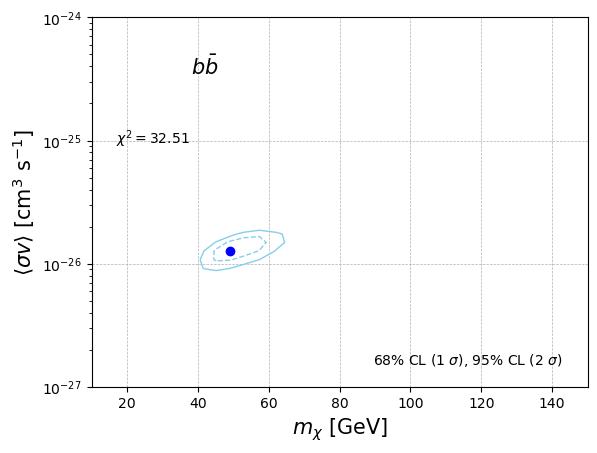

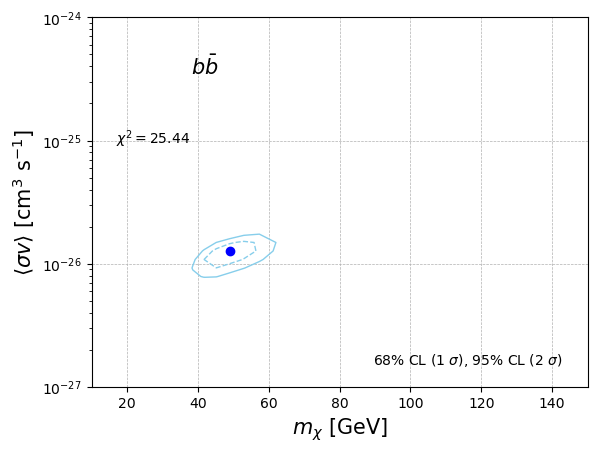

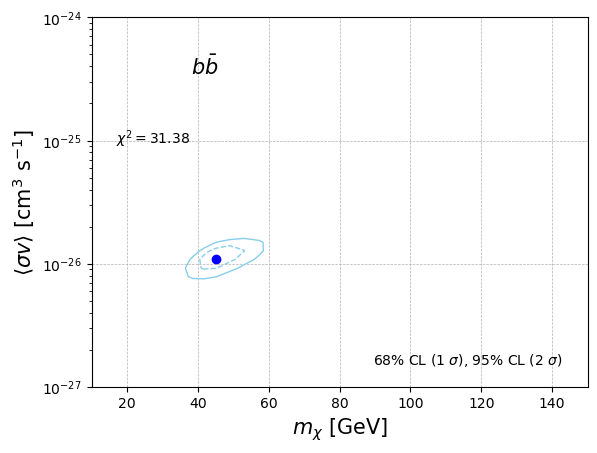

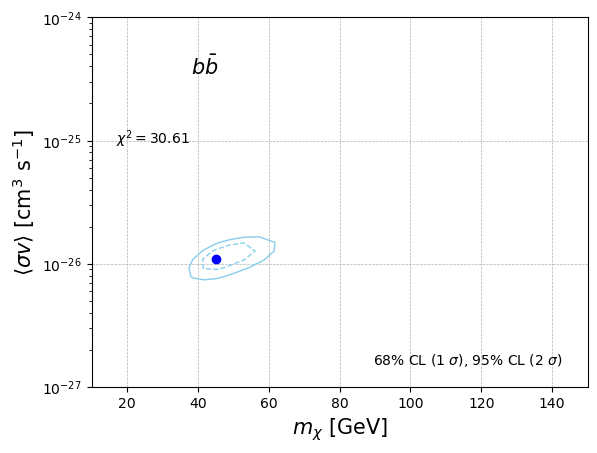

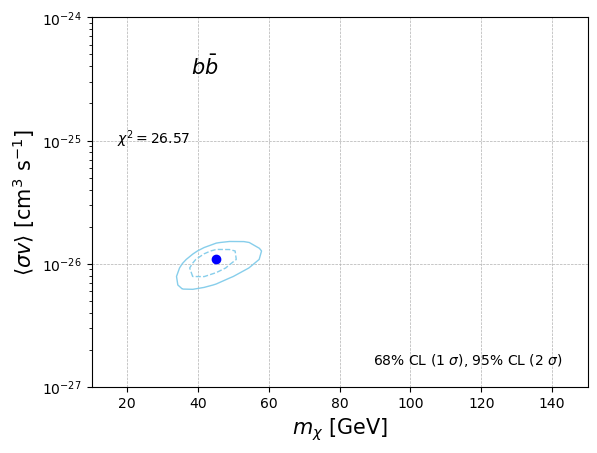

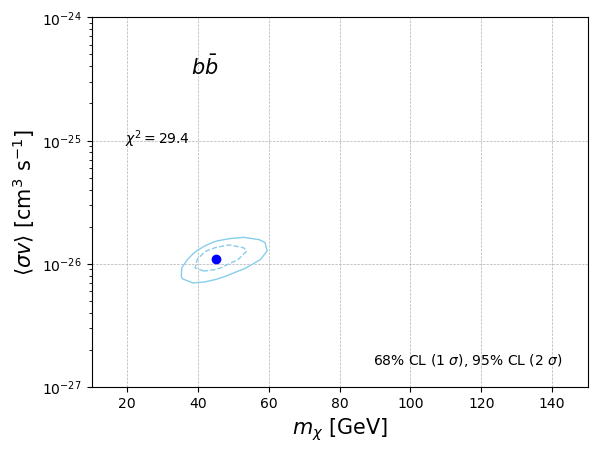

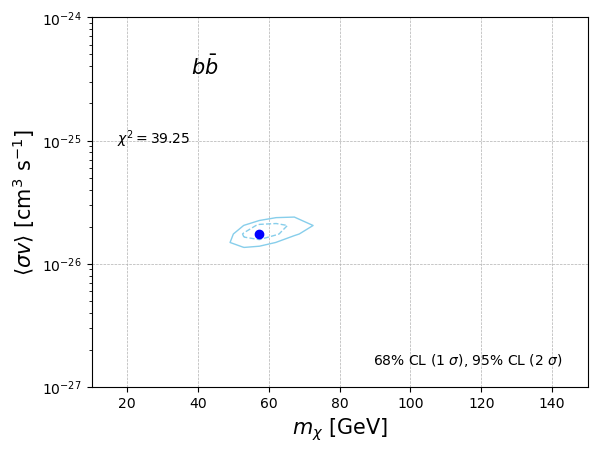

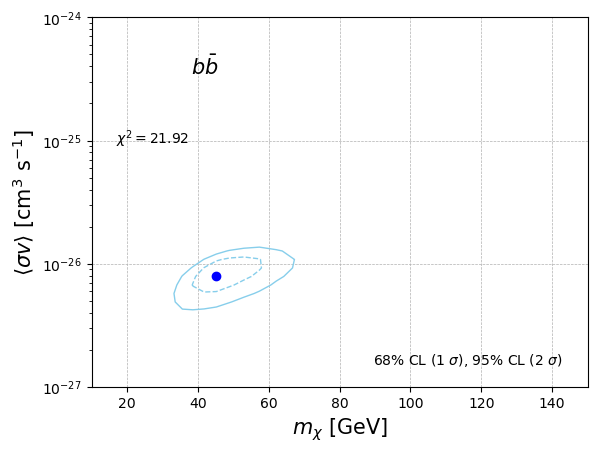

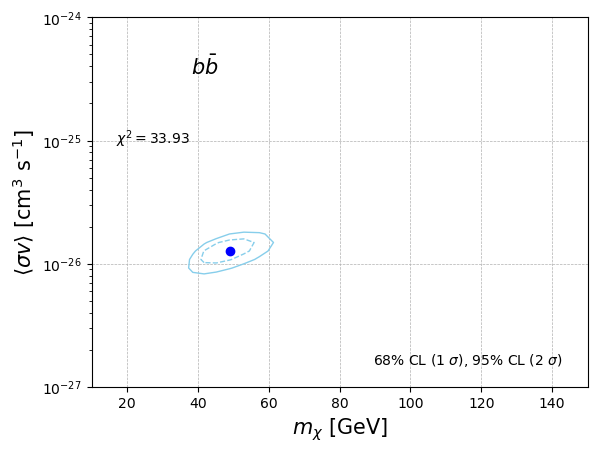

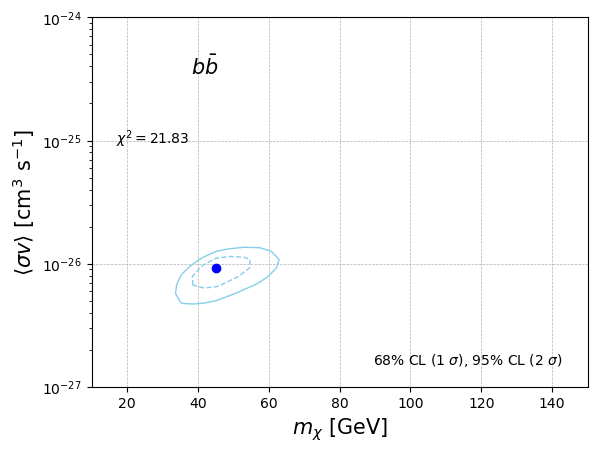

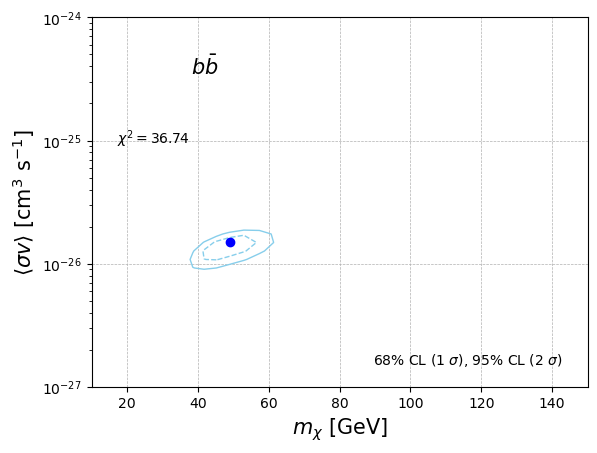

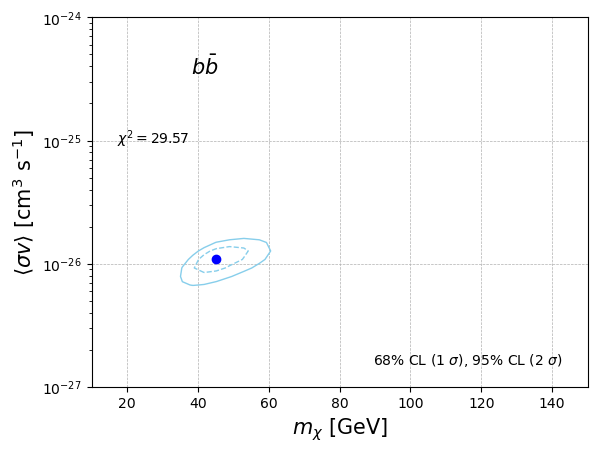

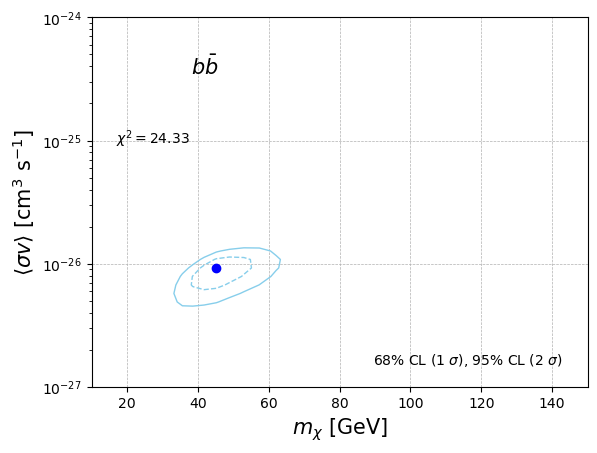

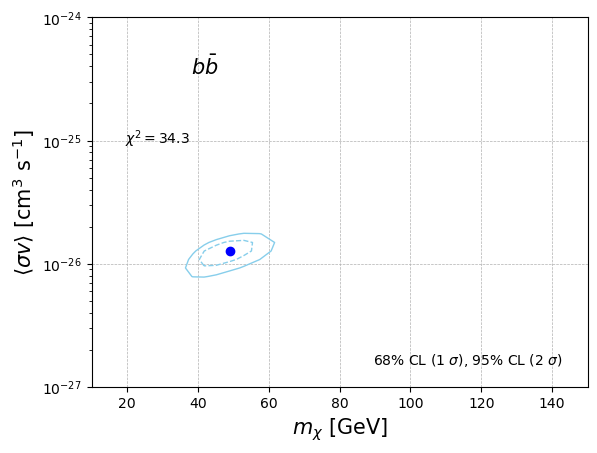

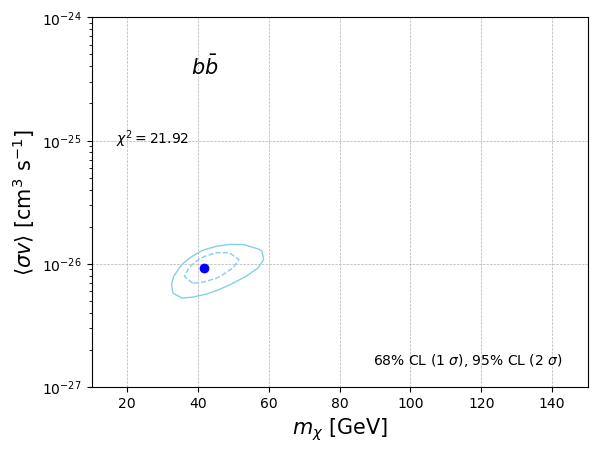

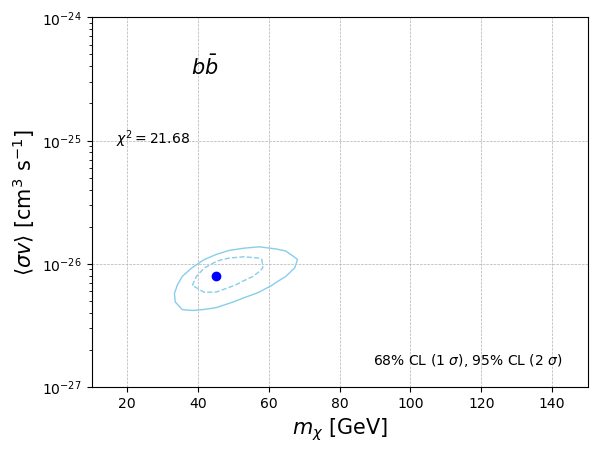

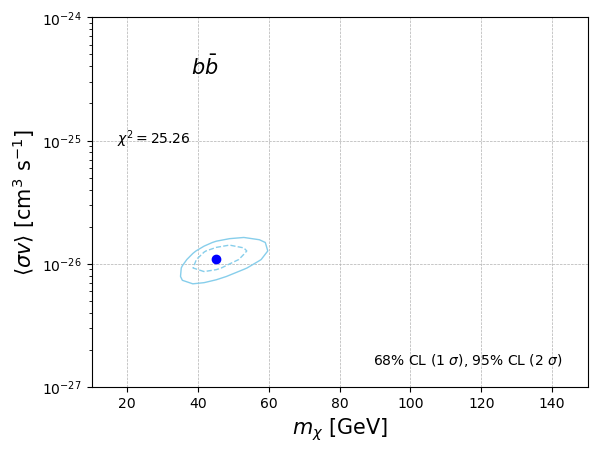

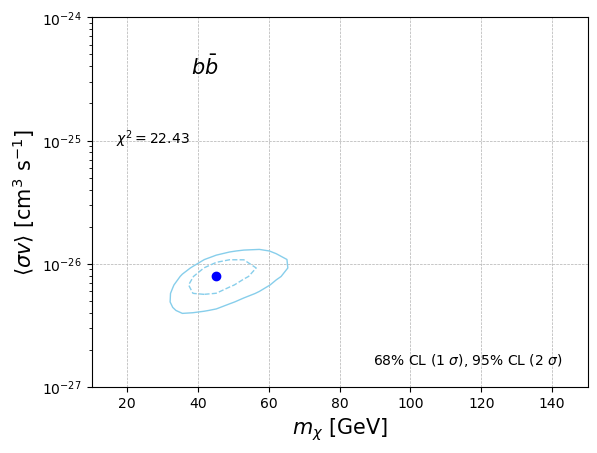

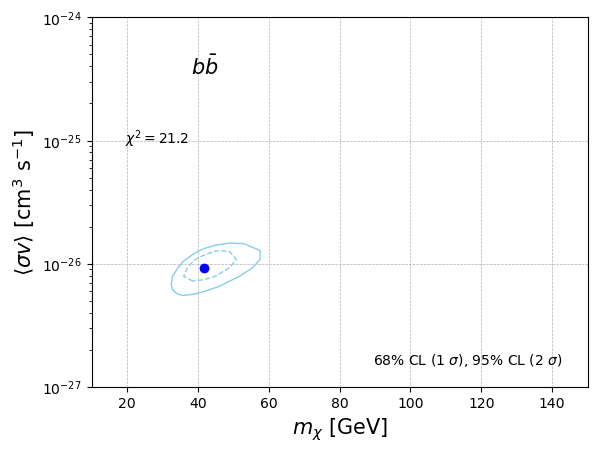

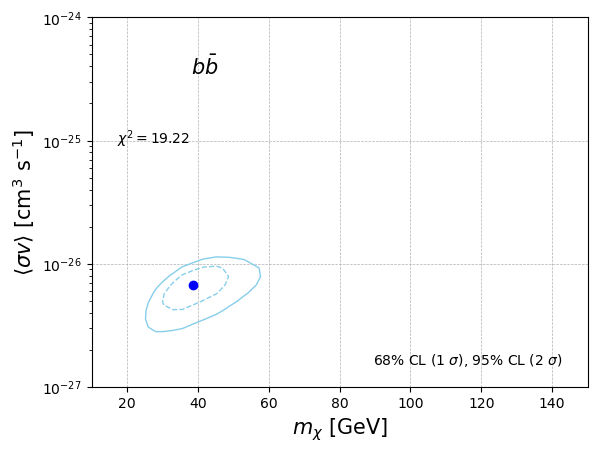

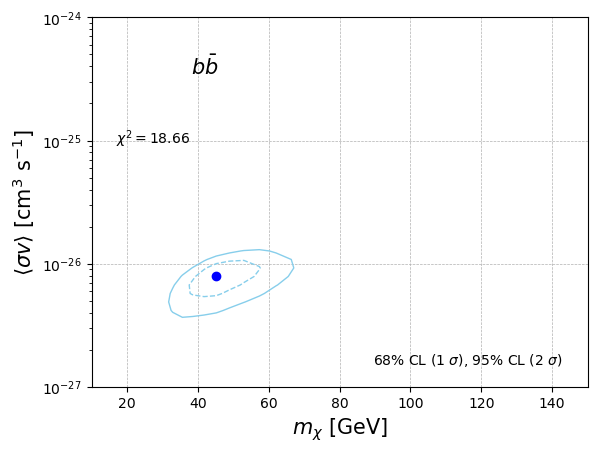

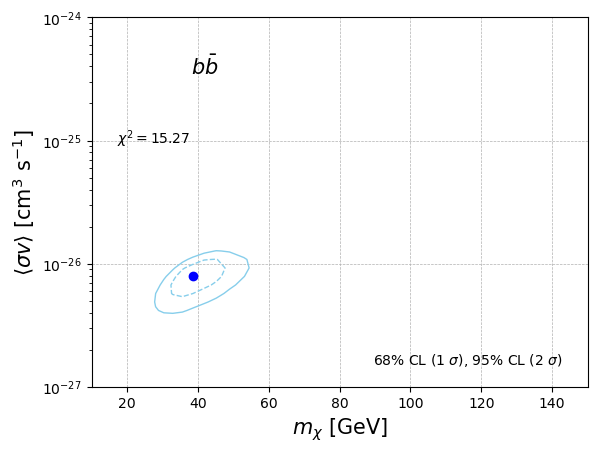

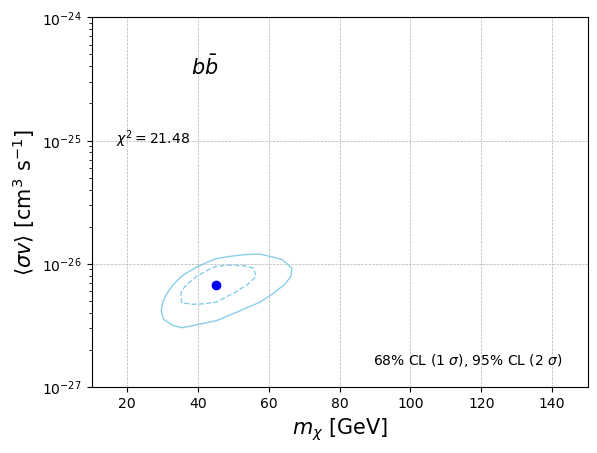

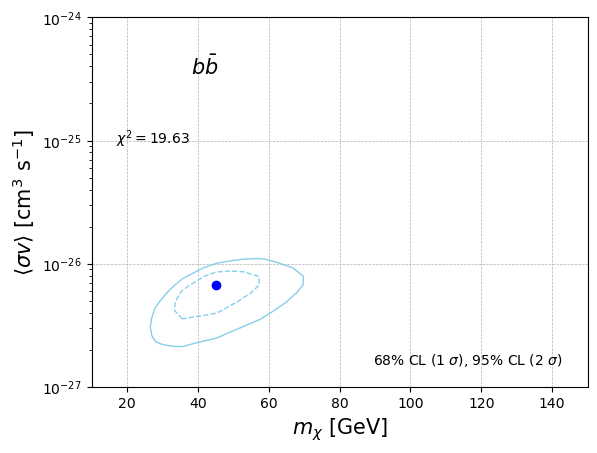

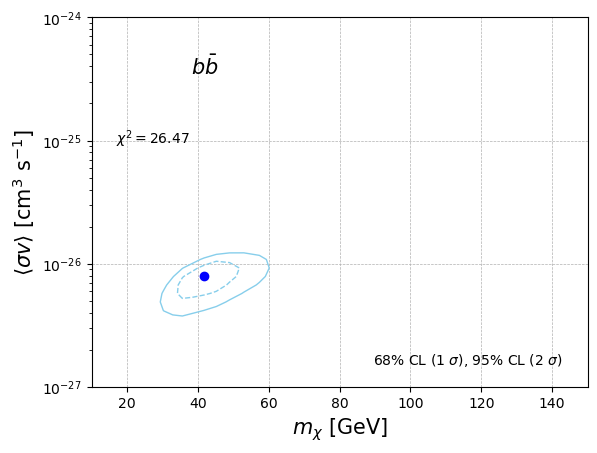

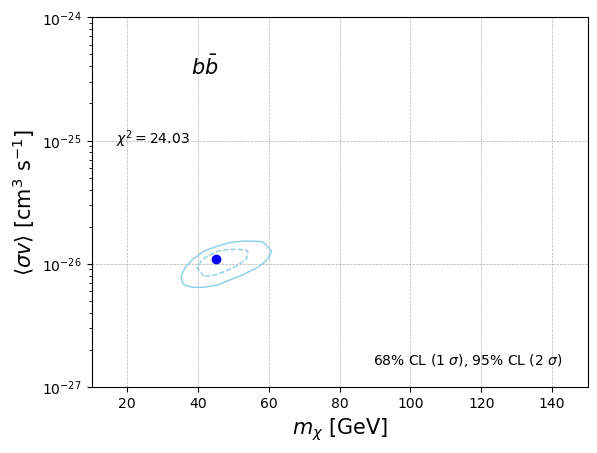

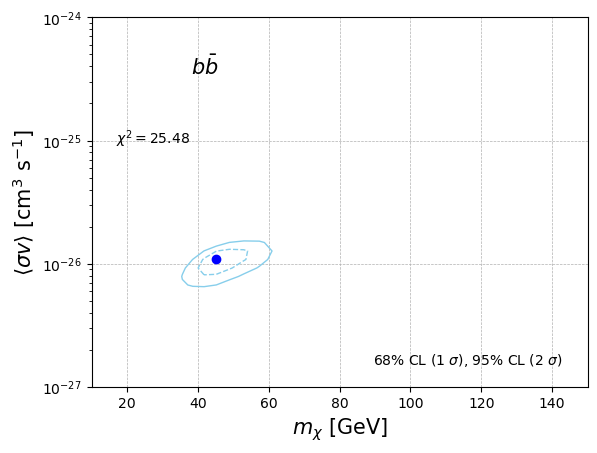

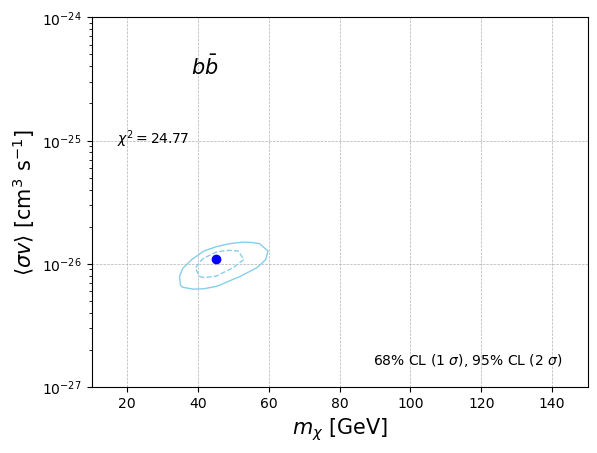

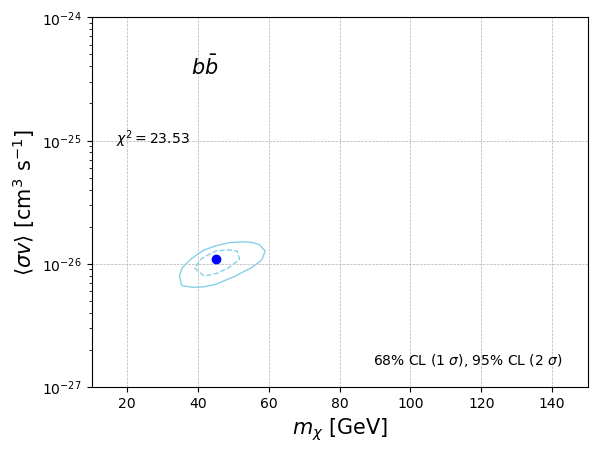

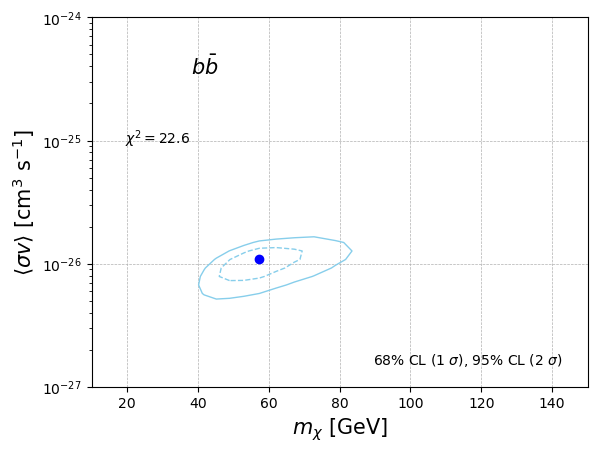

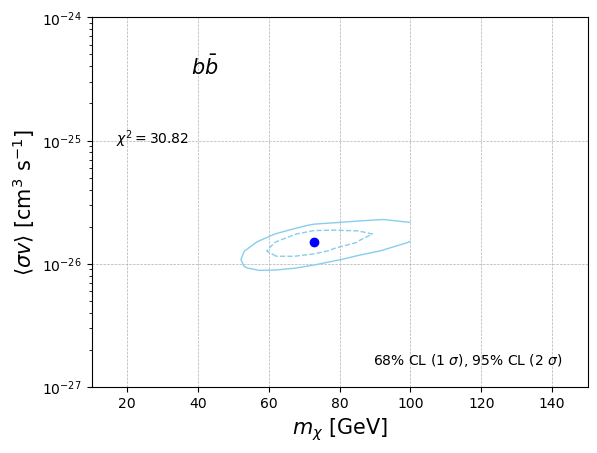

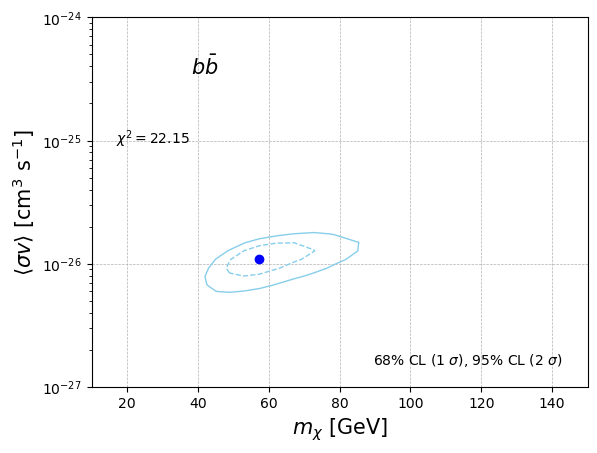

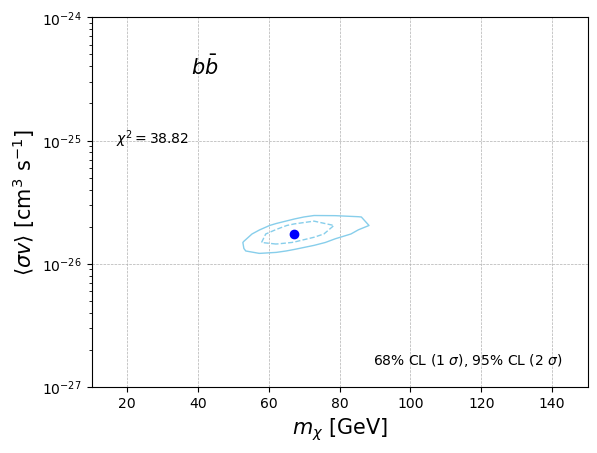

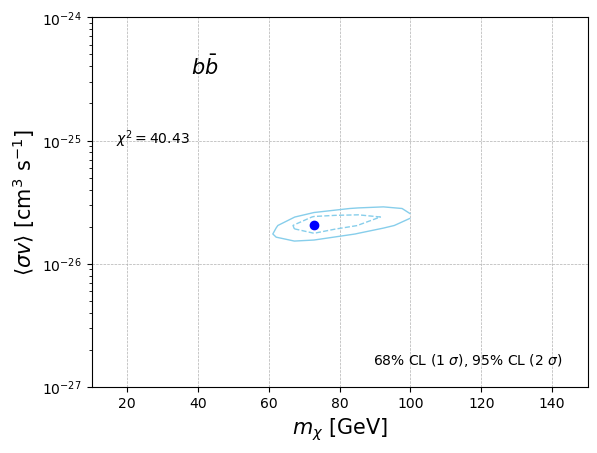

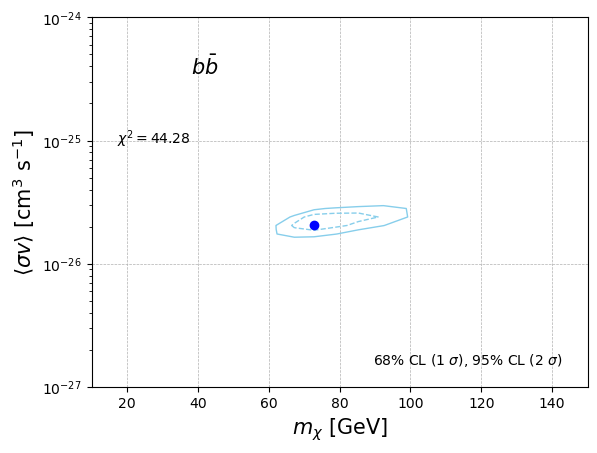

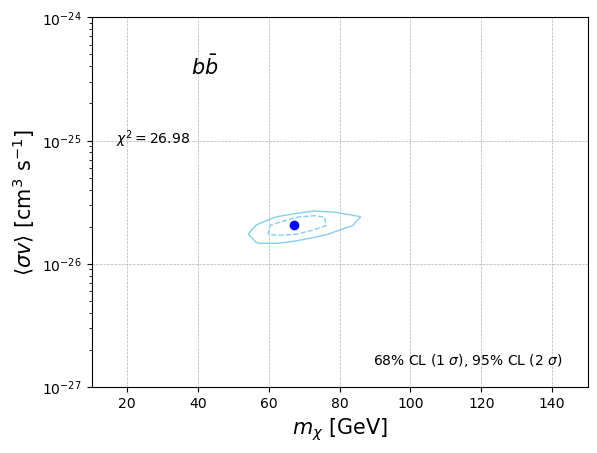

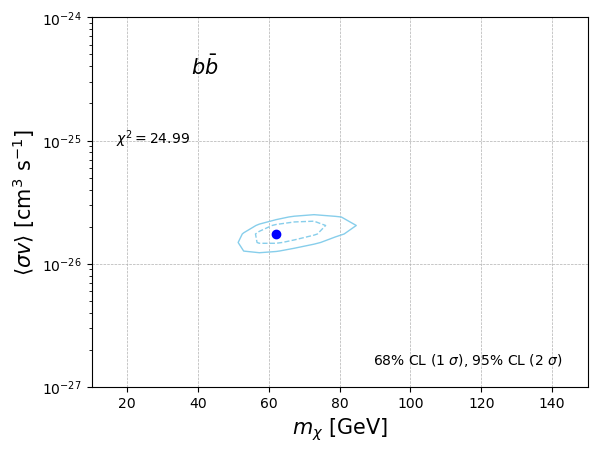

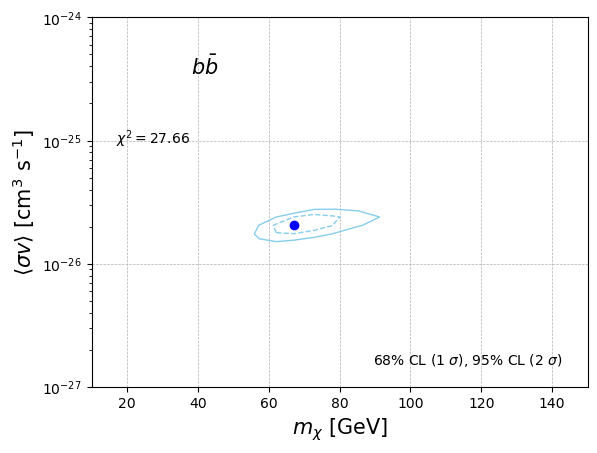

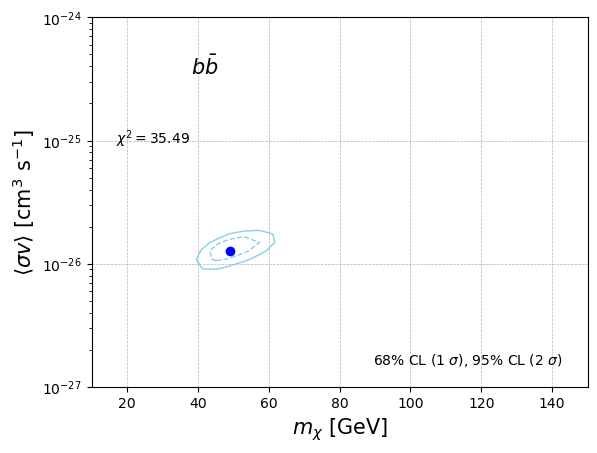

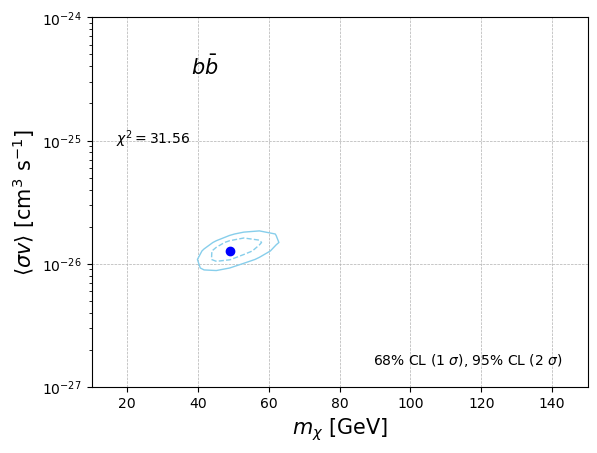

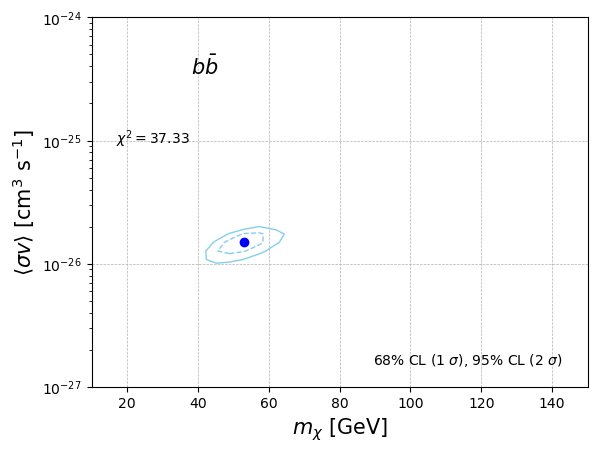

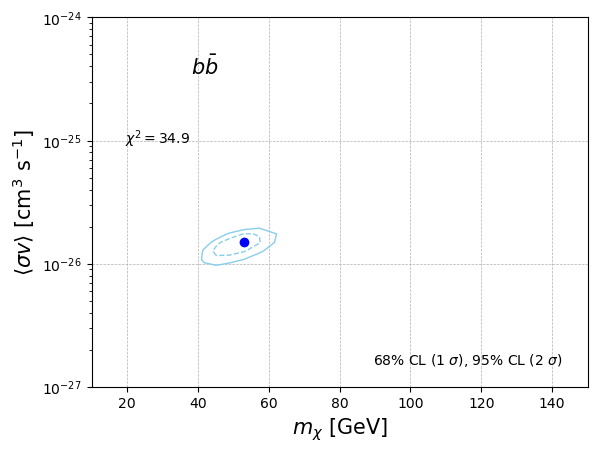

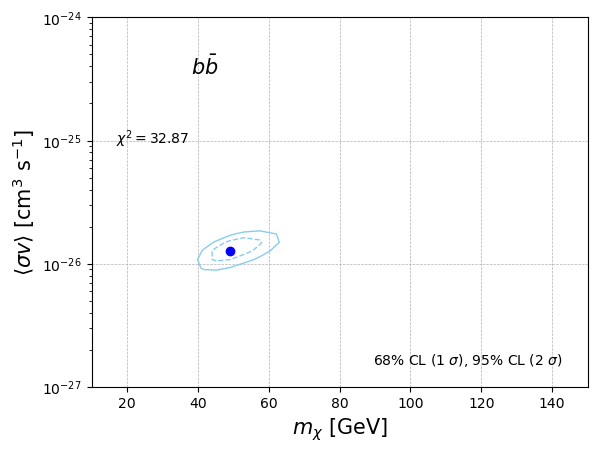

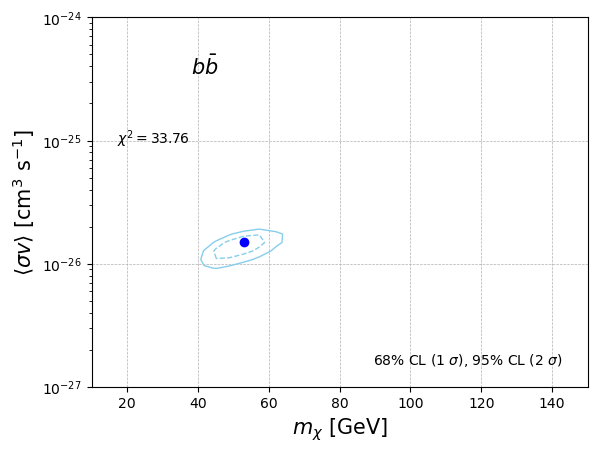

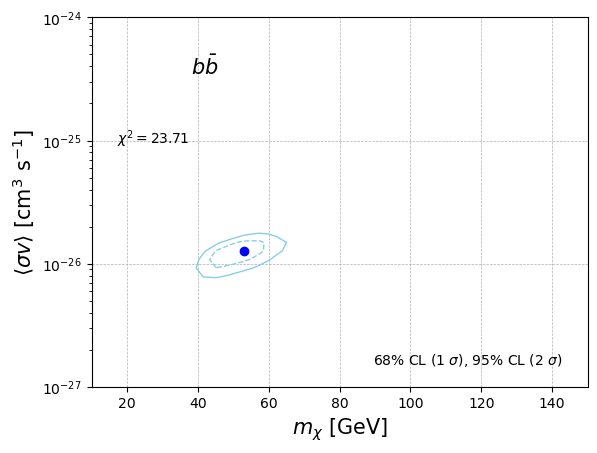

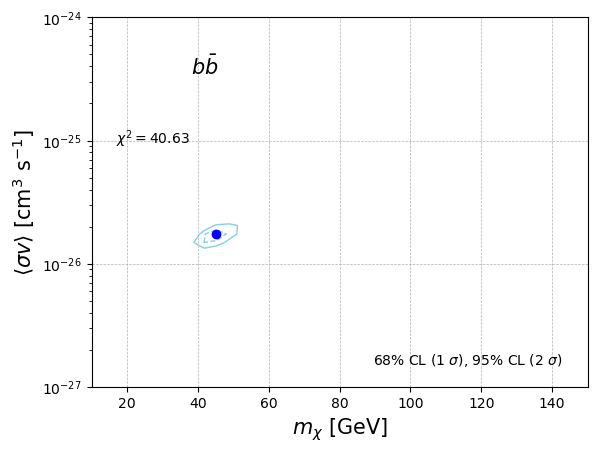

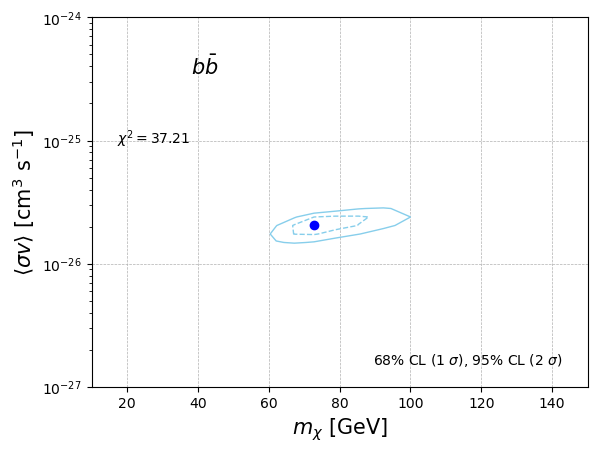

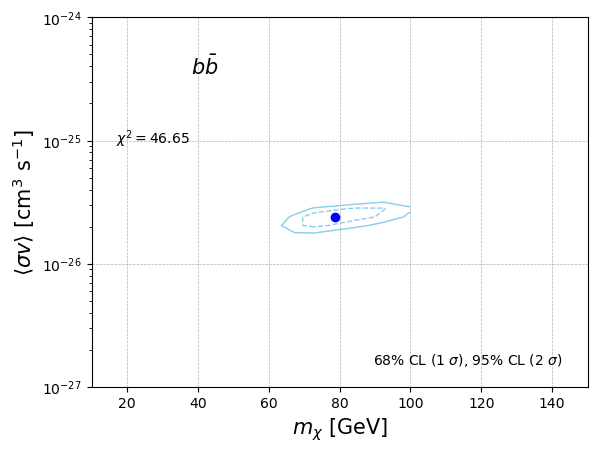

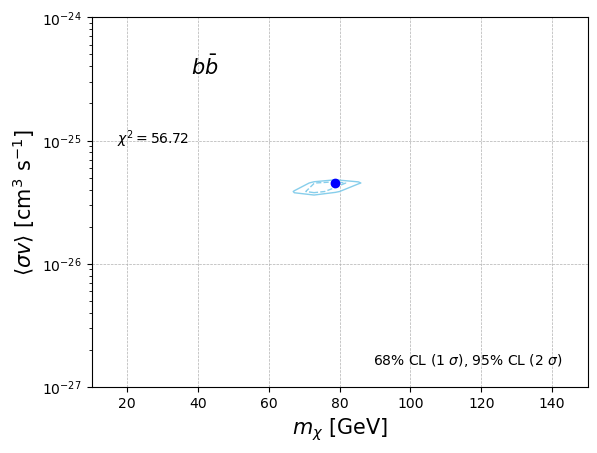

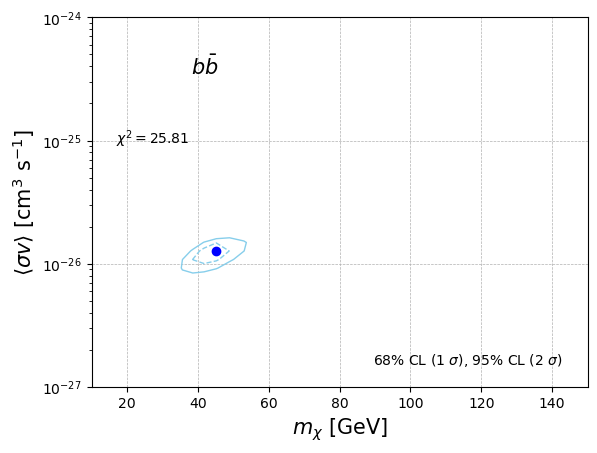

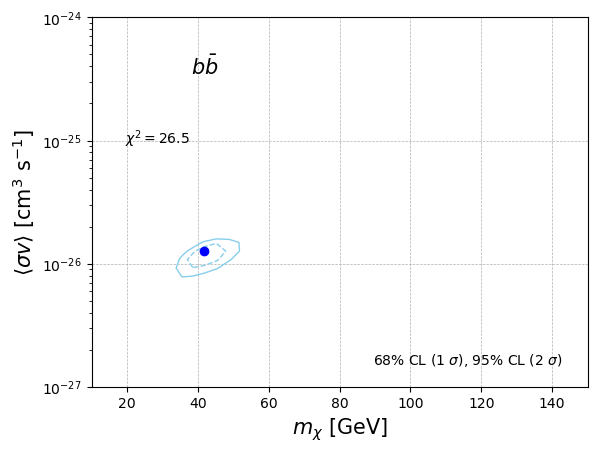

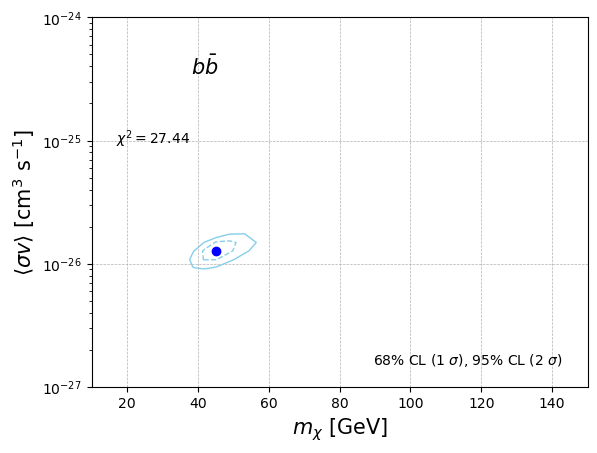

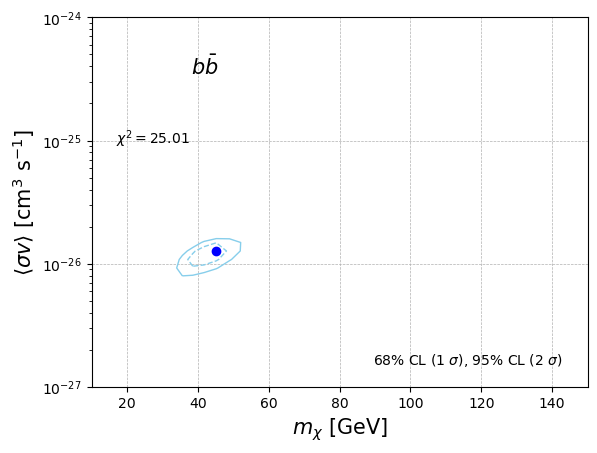

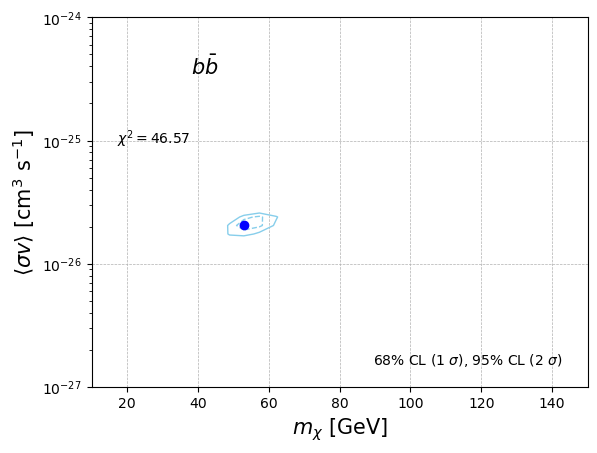

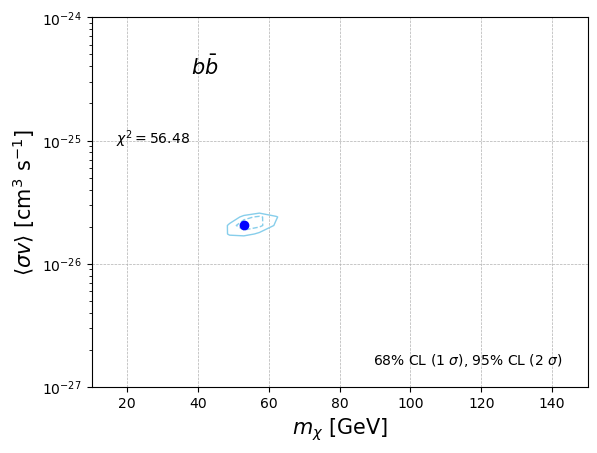

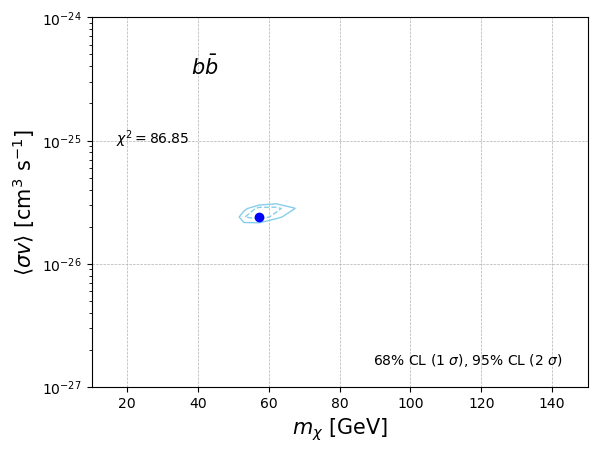

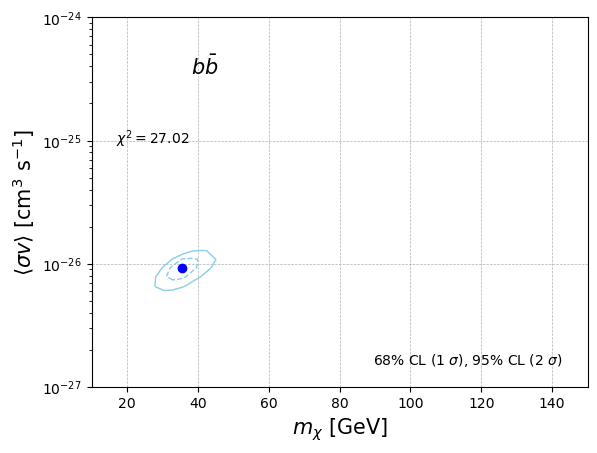

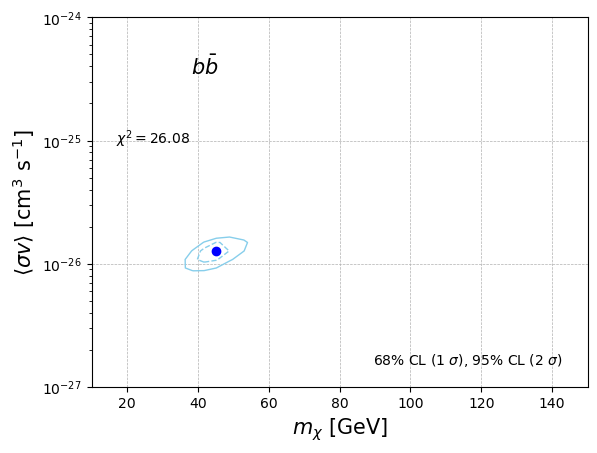

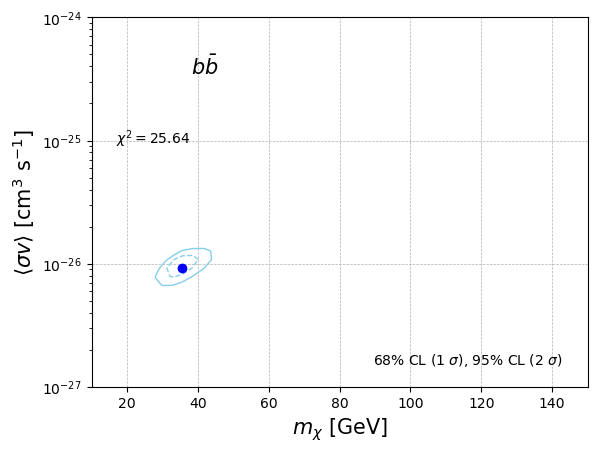

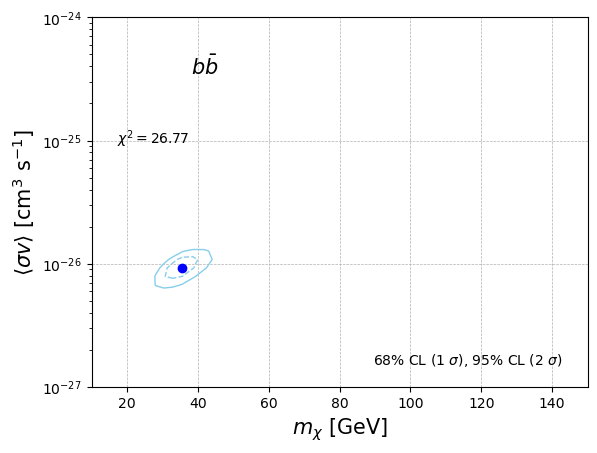

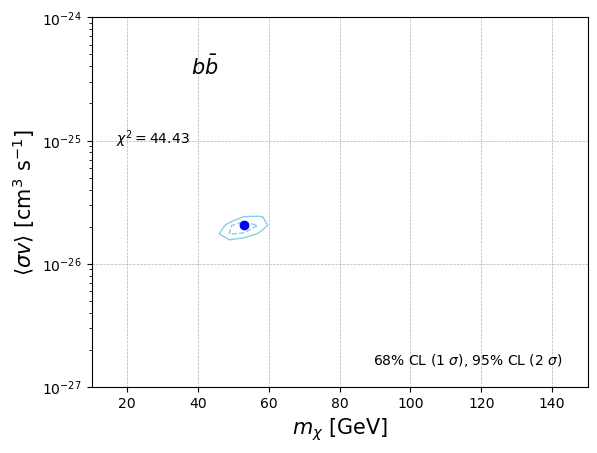

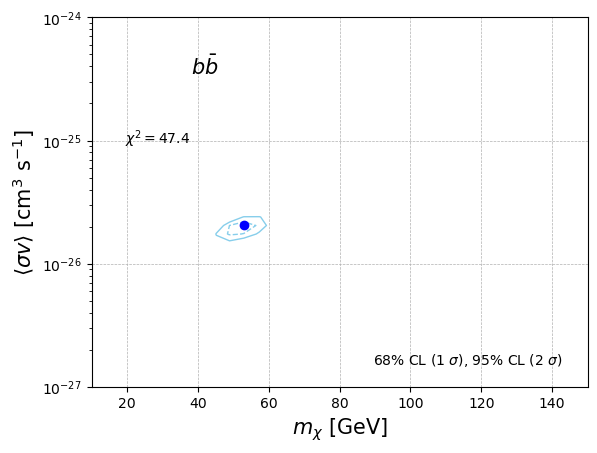

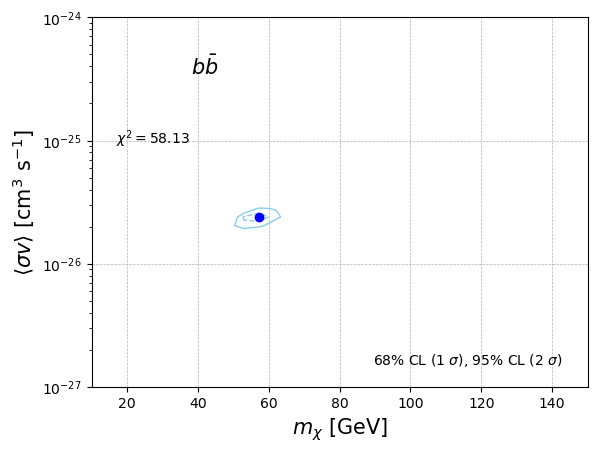

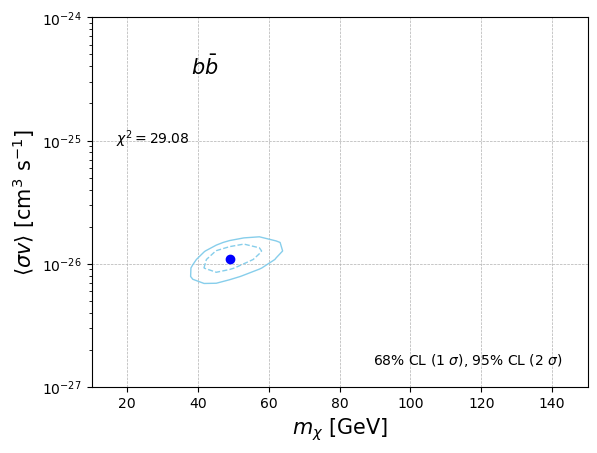

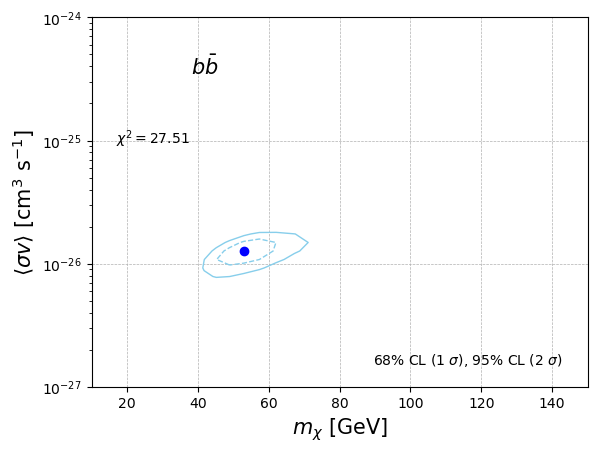

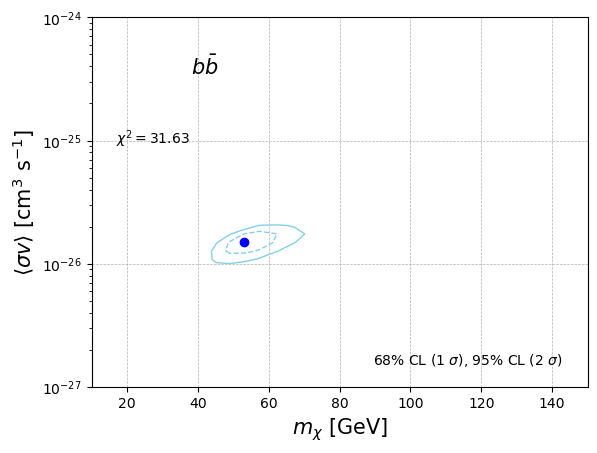

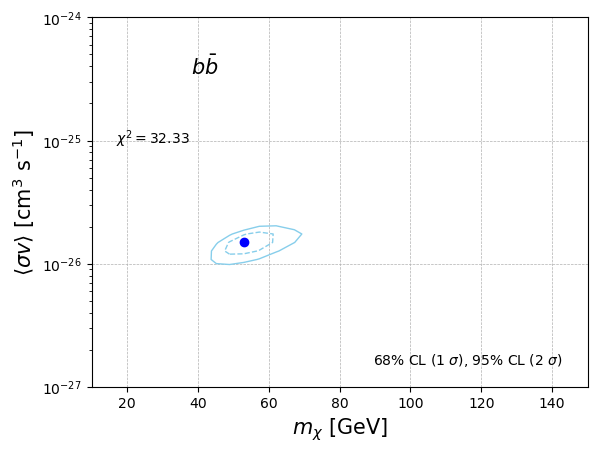

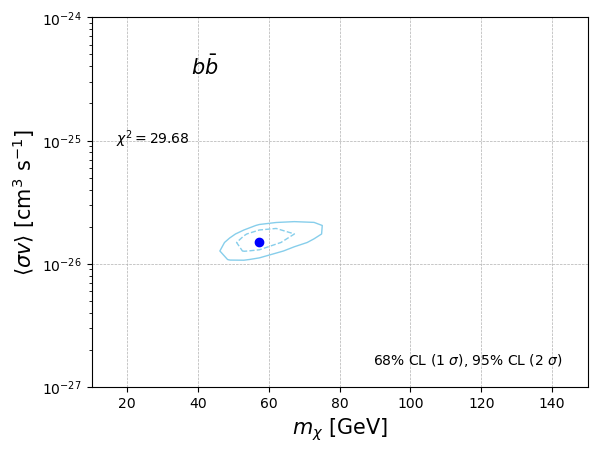

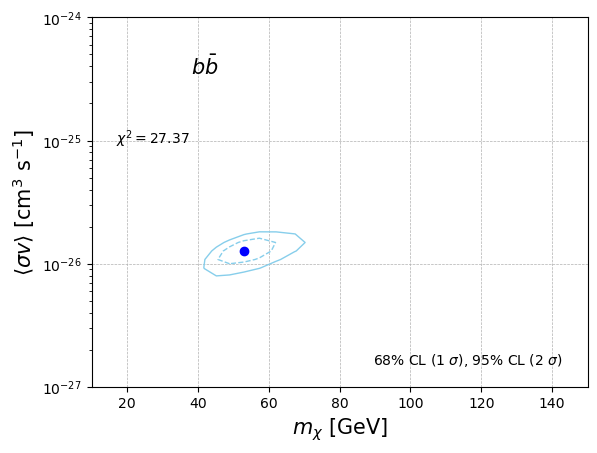

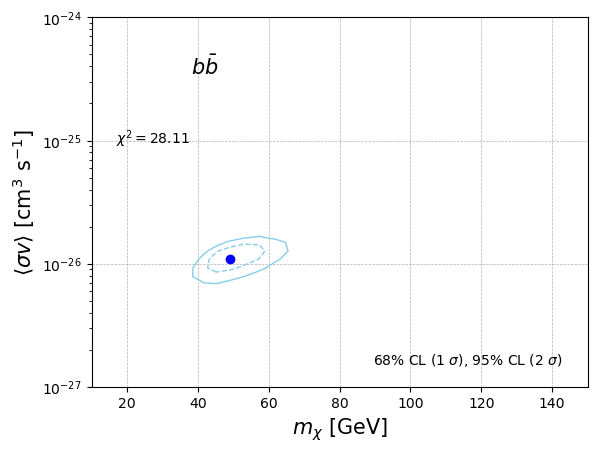

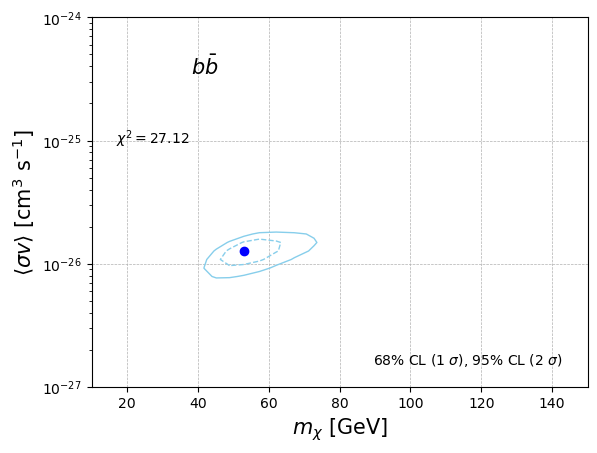

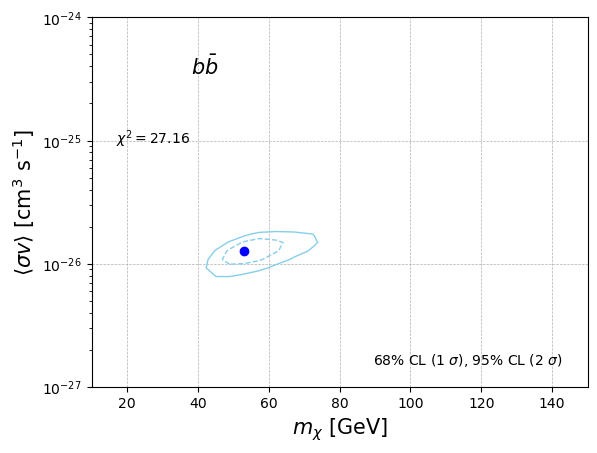

In [ ]:
for model in existing_list:
    
    def chi_square(dm_mass, sigmav):
        return chi_square_models(dm_mass, sigmav, model)
    
    sigmav_vec=np.logspace(-27, -25, 30)
    
    mass_vec = np.logspace(np.log10(10), np.log10(100), 30)
    
    
    DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
    chi_square_vec=np.vectorize(chi_square)
    
    
    
    chi_square_values = chi_square_vec(DM_mass, Sigmav)
    
    
    min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
    min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
    best_fit_dm=DM_mass[min_index_2d]
    best_fit_sigmav=Sigmav[min_index_2d]
    min_chi2=chi_square(best_fit_dm, best_fit_sigmav)
    
    
    one_sigma_threshold=min_chi2 + 2.30
    two_sigma_threshold=min_chi2 + 6.18
    
    chi_square_results=chi_square_vec(DM_mass, Sigmav)
    
    
    
    #ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
    #ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')
    
    
    plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model combined')
    
    
    plt.yscale('log')
    plt.xscale('linear')
    
    plt.xlim(10, 150)
    plt.ylim(1e-27, 1e-24)
    
    #plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')
    
    plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid
    
    plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
             verticalalignment='bottom', horizontalalignment='right',
             transform=plt.gca().transAxes)
    plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
             verticalalignment='top', horizontalalignment='right',
             transform=plt.gca().transAxes)
    
    plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
    #plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',
    
             verticalalignment='top', horizontalalignment='left',
             transform=plt.gca().transAxes)
    
    plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
    plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
    plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}_16yr.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    #plt.title("DM interpretation of GCE for model I", fontsize=13)
    


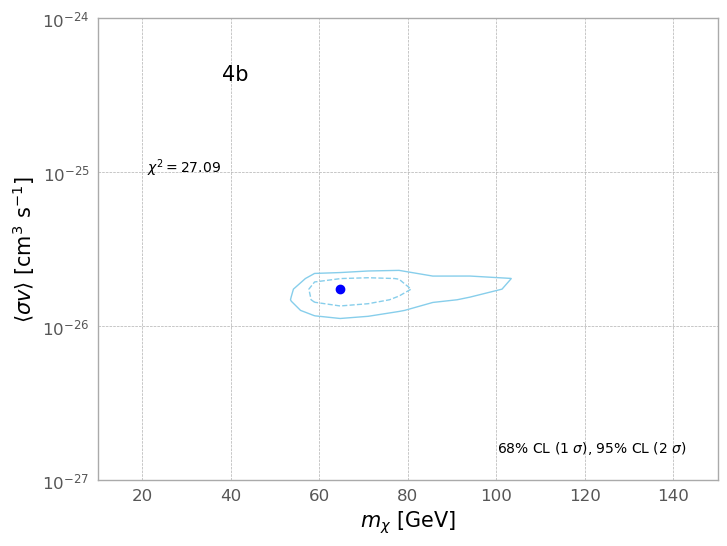

In [ ]:
model='I'
def chi_square(dm_mass, sigmav):
    return chi_square_models(dm_mass, sigmav, model)

sigmav_vec=np.logspace(-27, -25, 30)

mass_vec = np.logspace(np.log10(10), np.log10(150), 30)


DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
chi_square_vec=np.vectorize(chi_square)



chi_square_values = chi_square_vec(DM_mass, Sigmav)


min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
best_fit_dm=DM_mass[min_index_2d]
best_fit_sigmav=Sigmav[min_index_2d]
min_chi2=chi_square(best_fit_dm, best_fit_sigmav)


one_sigma_threshold=min_chi2 + 2.30
two_sigma_threshold=min_chi2 + 6.18

chi_square_results=chi_square_vec(DM_mass, Sigmav)



plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model combined')


plt.yscale('log')
plt.xscale('linear')

plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)

#plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'4b', fontsize=15, color='black',
#plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',

         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}_4b_16yr.png', bbox_inches='tight', dpi=300)
plt.show()

#plt.title("DM interpretation of GCE for model I", fontsize=13)



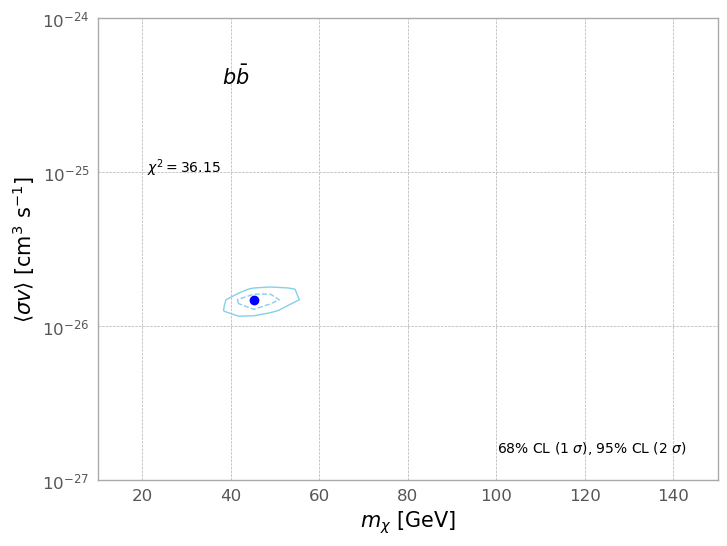

In [ ]:
model='X'
def chi_square(dm_mass, sigmav):
    return chi_square_models(dm_mass, sigmav, model)

import warnings
warnings.filterwarnings("ignore")

sigmav_vec=np.logspace(-27, -25, 30)

mass_vec = np.logspace(np.log10(10), np.log10(100), 30)


DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
chi_square_vec=np.vectorize(chi_square)



chi_square_values = chi_square_vec(DM_mass, Sigmav)


min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
best_fit_dm=DM_mass[min_index_2d]
best_fit_sigmav=Sigmav[min_index_2d]
min_chi2=chi_square(best_fit_dm, best_fit_sigmav)


one_sigma_threshold=min_chi2 + 2.30
two_sigma_threshold=min_chi2 + 6.18

chi_square_results=chi_square_vec(DM_mass, Sigmav)



plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model combined')


plt.yscale('log')
plt.xscale('linear')

plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)

#plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
#plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',

         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
#plt.savefig(f'./GC_analysis/GCE_plots/GDE_model_{model}_{front}_E_{energy_bin_length}_16yr.png', bbox_inches='tight', dpi=300)
plt.show()

#plt.title("DM interpretation of GCE for model I", fontsize=13)



In [ ]:
best_fit_dm, best_fit_sigmav

(48.93900918477494, 1.4873521072935116e-26)

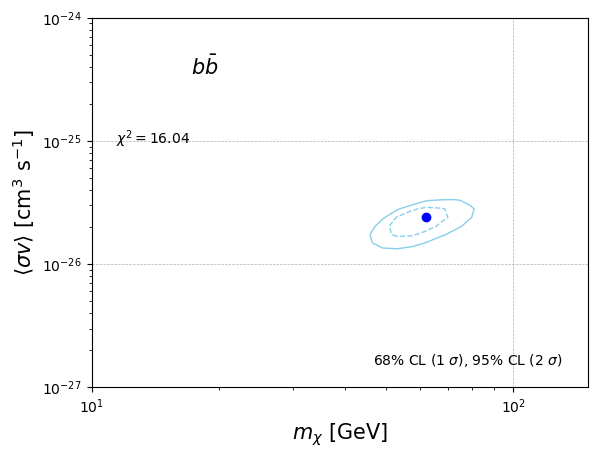

In [ ]:
sigmav_vec=np.logspace(-27, -25, 30)

mass_vec = np.logspace(np.log10(10), np.log10(100), 30)


DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
chi_square_vec=np.vectorize(chi_square)



chi_square_values = chi_square_vec(DM_mass, Sigmav)


min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
best_fit_dm=DM_mass[min_index_2d]
best_fit_sigmav=Sigmav[min_index_2d]
min_chi2=chi_square(best_fit_dm, best_fit_sigmav)


one_sigma_threshold=min_chi2 + 2.30
two_sigma_threshold=min_chi2 + 6.18

chi_square_results=chi_square_vec(DM_mass, Sigmav)



#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model combined')


plt.yscale('log')
plt.xscale('log')

plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)

#plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
#plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',

         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)

plt.show()

#plt.title("DM interpretation of GCE for model I", fontsize=13)



In [ ]:
best_fit_dm, best_fit_sigmav

(62.10169418915616, 2.395026619987491e-26)

In [ ]:
def chi_square_I(dm_mass, sigma_v):
    warnings.simplefilter("ignore", category=RuntimeWarning)
    #prompt_dat=exctractcirellitable(dm_mass, 23, 'gammas', 'Yes') #EW yes and channel 10 is for tau
    #prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') #EW yes and channel 13 is for b
    #prompt_dat=exctractcirellitable(dm_mass, 10, 'gammas', 'Yes') #EW no and channel 4 is for tau
    #prompt_dat=exctractcirellitable(dm_mass, 6, 'gammas', 'No') #EW no and channel 6 is for c
    #prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'No') #EW no and channel 13 is for h
    #prompt_dat=exctractcirellitable(dm_mass, 7, 'gammas', 'No') #EW no and channel 7 is for b
    #prompt_dat=prompt_dat=np.loadtxt(f'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/Events/DM{dm_mass}GeV_Med{med_mass}GeV_decayed_1/DM{dm_mass}GeV_Med{med_mass}GeV.dat')
    #prompt_dat=np.loadtxt(f'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/Events/DM{dm_mass}GeV_Med{med_mass}GeV_decayed_1/DM{dm_mass}GeV_Med{med_mass}GeV.dat')
    #prompt_dat = Interpolator(med_mass, dm_mass).interpolated_table()
    
    #prompt_dat = Interpolator(dm_mass).interpolated_table()

    
    
    

    #v=np.loadtxt('/home/FermiLAT/Sanghwan/GC_14yr/data/GCE_ModelI_flux_Inner40x40_masked_disk.dat')
    v=np.loadtxt(f'/home/FermiLAT/Sanghwan/GC_14yr/data/GCE_Model{"I"}_flux_Inner40x40_masked_disk.dat')
    #v=np.loadtxt(f'/home/FermiLAT/Sanghwan/GC_14yr/data/GCE_Model{"I"}_flux_Inner40x40_masked_disk.dat')
    #v=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_X_15yr_cholis.dat')
    emeans=v[0:, 0]
    GCE_data = v[0:, 1]
    #d=np.loadtxt('/home/FermiLAT/Sanghwan/GC_14yr/data/GCE_Statistical_errors.dat')[0:, 1]
    #d=(v[0:, 3] - v[0:, 2])#/2
    d_u = v[0:, 3] - v[0:, 1] 
    d_l = v[0:, 1] - v[0:, 2]
    
    
    #d=np.diag(d**2)
    
    
        
    #J_factor=5.068061692242978e+21 #Check needed
    
    #sr=0.9741042162268921
    
    J_factor=3.5251837158376415e+21 #Check needed
    sr=0.4288213187542626
    
    #data = interp1d(prompt_dat[0], prompt_dat[1]*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
    #data = interp1d(prompt_dat[0], prompt_dat[1]*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
    #data = interp1d(prompt_dat[0], prompt_dat[1], fill_value=0, bounds_error=False, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
    
    #data = interp1d(np.log(prompt_dat[0]), np.log(prompt_dat[1]), fill_value=0, bounds_error=False)#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
    #data = interp1d(prompt_dat[0], prompt_dat[1], fill_value=0, bounds_error=False)#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
    #data = interp1d(prompt_dat[0], prompt_dat[1], fill_value='extrapolate', kind='linear')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
    #data = prompt_dat
    #data = interp1d(prompt_dat[0:, 0], prompt_dat[0:, 1]*(sigma_v/(dm_mass**2))*J_factor/(2*sr), fill_value='extrapolate')
    #data = np.exp(data(np.log(emeans)))
    #data = data(emeans)
    #data[data<0] = 0
    #data = emeans**2*data*(sigma_v/(dm_mass**2))*J_factor/(sr)
    
    
    
    #prompt_dat = Interpolator(dm_mass).interpolated_table()
    prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') #EW yes and channel 10 is for tau, 13 for bb ew yes

    
    J_factor=3.5251837158376415e+21 #Check needed
    sr=0.4288213187542626

    #data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
    #data = (emeans**2*data(emeans)*(sigma_v/(dm_mass**2))*J_factor/(2*sr))[0:14]
    
    data = prompt_dat[0:14]
    data = emeans**2*data*(sigma_v/(dm_mass**2))*J_factor/(sr)
    #data = data[0:14]
    
    
    
    #err = np.where(data > GCE_data, d_u, d_l)
    err = np.where(data > GCE_data, d_u, d_l)
    #err = (d_u + d_l)/2
    for i in range(0, len(err), 1):
        err[i] = np.max([d_u[i], d_l[i]])

    
    d = np.diag(err**2)
    #d=np.diag(np.loadtxt('/home/FermiLAT/Sanghwan/GC_14yr/data/GCE_Statistical_errors.dat')[0:, 1])**2


    corr_cov = np.load("/home/FermiLAT/Sanghwan/GC_14yr/data/cov_mat_21Dec02.npy")#load the full systematic errors covariance matrix
    corr_covsvd = np.linalg.svd(corr_cov)

    cov_PCs = np.array([corr_covsvd[1][i]*np.outer(corr_covsvd[0].T[i], corr_covsvd[2][i]) for i in range(14)])

    def approxcovmatrix(p):
        out = np.zeros((14,14))
        if ((type(p)==int) & (p>0)):
            out += np.sum([cov_PCs[i] for i in range(p)], axis=0)
        return out
    
    cov_matrix=d + approxcovmatrix(4)
    
    inv_GCE_data_err_matrix=np.linalg.inv( cov_matrix )

    
    delta = data - GCE_data
    #return cov_matrix
    return delta.T@inv_GCE_data_err_matrix@delta
    #return np.sum(a*b*inv_GCE_data_err_matrix)
    #return (a.T@inv_GCE_data_err_matrix@b)

In [ ]:
target_model="XLIX"
def chi_square(dm_mass, sigma_v):
    
    warnings.simplefilter("ignore", category=RuntimeWarning)  
    J_factor=3.5251837158376415e+21 #Check needed
    sr=0.4288213187542626
    
    extended_bin=True
    if extended_bin:
        bin_edge=17
    else:
        bin_edge=14
    #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_15yr_cholis.dat')
    #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_model_I_12yr.dat')
    #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_X_16yr_cholis.dat')
    #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_XLIX_front_back_16yr_cholis.dat')
    #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_XLIX_15yr_cholis.dat')
    #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_model_I_12yr.dat')
    #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_X_16yr_cholis.dat')
    #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_12yr_positive.dat')
    #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_15yr_positive_test.dat')

    g=np.loadtxt(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_{target_model}_front_back_16yr_cholis.dat')


    emeans=g[0:, 0][0:bin_edge]
    GCE_data=g[0:, 1][0:bin_edge]
    stat_uncertainty = g[0:, 2][0:bin_edge]
    
    #systematic_upper = g[0:, 3] - g[0:, 1]
    #systematic_lower = g[0:, 1] - g[0:, 2]
    
    d_u = (g[0:, 4] - g[0:, 1])[0:bin_edge]
    d_l = (g[0:, 1] - g[0:, 3])[0:bin_edge]
    
 
    #prompt_dat=np.loadtxt(f'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/Events/DM{dm_mass}GeV_Med{med_mass}GeV_decayed_1/DM{dm_mass}GeV_Med{med_mass}GeV.dat')
    #prompt_dat = Interpolator(med_mass, dm_mass).interpolated_table()
    #prompt_dat = Interpolator(dm_mass).interpolated_table()
    prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') #EW yes and channel 10 is for tau, 13 for bb ew yes

    
    J_factor=3.5251837158376415e+21 #Check needed
    sr=0.4288213187542626

    #data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
    #data = emeans**2*data(emeans)*(sigma_v/(dm_mass**2))*J_factor/(2*sr)

    data = prompt_dat[0:bin_edge]
    data = emeans**2*data*(sigma_v/(dm_mass**2))*J_factor/(sr)
    
    #GCE_data_err = np.where(data > GCE_data, systematic_upper, systematic_lower)

    #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
    #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
    #GCE_data_err = (d_u + d_l)/2
    GCE_data_err = stat_uncertainty
    #for i in range(0, len(emeans), 1):
    #    GCE_data_err[i] = np.max([d_u[i], d_l[i]])
    data = data[0:bin_edge]
    GCE_data = GCE_data[0:bin_edge]

    #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2)
    if extended_bin:
        empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_front_back_16yr.npy')
        #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_16yr.npy')
        #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy')
        #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_12yr.npy')

    else:
        empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14_12yr.npy')
        #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14.npy')
    cov=(empirical_cov + np.diag(GCE_data_err)**2)

    
    #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + (np.load("/home/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix.npy")))
    #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + np.diag(variances_direct))
    inv_cov=np.linalg.inv(cov)


    
    
    delta = data - GCE_data
    return delta.T@inv_cov@delta    #return np.sum(((GCE_data - data)/(GCE_data_err))**2)

In [ ]:
chi_square(45, 1e-26)

166.3844714234913

In [ ]:
chi_square_I(45, 1e-26)

17.389139866752554

In [ ]:
chi_square(50, 1e-26)

24.29138372849277

In [ ]:
med_mass=15
def chi_square_w(dm_mass, sigma_v):
    
    J_factor=3.5251837158376415e+21 #Check needed
    sr=0.4288213187542626
    
    data = np.loadtxt('/home/sanghwan/C.Weniger/covariance.dat')
    ebins = data[:,0:2]  # Energy bins [GeV]
    emeans = ebins.prod(axis=1)**0.5  # Geometric mean energy [GeV]
    de = ebins[:,1] - ebins[:,0]  # Energy bin width [GeV]
    flux = data[:,2]  # (Average flux)*E^2 in energy bin [GeV/cm2/s/sr]
    flux_err = data[:,3]  # Flux error [GeV/cm2/s/sr]
    empirical_variance = data[:,4:28]  # Only empirical component [(GeV/cm2/s/sr)^2]
    full_variance = data[:,28:]  # Variance as it enters the spectral fit [(GeV/cm2/s/sr)^2]
    empirical_sigma = np.sqrt(np.diagonal(empirical_variance))  # Diagonal elements
    inv_GCE_data_err_matrix=np.linalg.inv(empirical_variance + np.diag(flux_err**2))


    
    #prompt_dat=prompt_dat=np.loadtxt(f'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/Events/DM{dm_mass}GeV_Med{med_mass}GeV_decayed_1/DM{dm_mass}GeV_Med{med_mass}GeV.dat')
    prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') #EW yes and channel 10 is for tau
    #prompt_dat = Interpolator(dm_mass).interpolated_table()

    
    
    J_factor=3.5251837158376415e+21 #Check needed
    sr=0.4288213187542626
    
    #data = interp1d(prompt_dat[0:, 0], prompt_dat[0:, 1]*(sigma_v/(dm_mass**2))*J_factor/(2*sr), fill_value='extrapolate')
    data = interp1d(prompt_dat[0], prompt_dat[1]*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')

    data = data(emeans)*emeans**2
    
    
    data[data<=0] = 0
    
    a, b = np.meshgrid(data - flux, data - flux)
        
    
    return np.sum(a*b*inv_GCE_data_err_matrix) 
    #return np.sum((flux - data)**2/flux_err**2)

In [ ]:
for target_model in ['X']:#['I', 'IV', 'V', 'VI', 'VII', 'IX', 'X', 'XLI', 'XLVII', 'XLVIII', 'XLIX', 'L', 'LII']:

    def chi_square(dm_mass, sigma_v):

        warnings.simplefilter("ignore", category=RuntimeWarning)  
        J_factor=3.5251837158376415e+21 #Check needed
        sr=0.4288213187542626

        extended_bin=False
        if extended_bin:
            bin_edge=17
        else:
            bin_edge=14
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_15yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_model_I_12yr.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_X_16yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_XLIX_front_back_16yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_XLIX_15yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_model_I_12yr.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_X_16yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_12yr_positive.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_15yr_positive_test.dat')

        g=np.loadtxt(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_{target_model}_front_back_16yr_cholis.dat')


        emeans=g[0:, 0][0:bin_edge]
        GCE_data=g[0:, 1][0:bin_edge]
        stat_uncertainty = g[0:, 2][0:bin_edge]

        #systematic_upper = g[0:, 3] - g[0:, 1]
        #systematic_lower = g[0:, 1] - g[0:, 2]

        d_u = (g[0:, 4] - g[0:, 1])[0:bin_edge]
        d_l = (g[0:, 1] - g[0:, 3])[0:bin_edge]


        #prompt_dat=np.loadtxt(f'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/Events/DM{dm_mass}GeV_Med{med_mass}GeV_decayed_1/DM{dm_mass}GeV_Med{med_mass}GeV.dat')
        #prompt_dat = Interpolator(med_mass, dm_mass).interpolated_table()
        prompt_dat = Interpolator(dm_mass).interpolated_table()
        #prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') #EW yes and channel 10 is for tau, 13 for bb ew yes


        J_factor=3.5251837158376415e+21 #Check needed
        sr=0.4288213187542626

        data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
        data = emeans**2*data(emeans)*(sigma_v/(dm_mass**2))*J_factor/(2*sr)

        #data = prompt_dat[0:bin_edge]
        #data = emeans**2*data*(sigma_v/(dm_mass**2))*J_factor/(sr)

        #GCE_data_err = np.where(data > GCE_data, systematic_upper, systematic_lower)

        #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
        #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
        #GCE_data_err = (d_u + d_l)/2
        GCE_data_err = stat_uncertainty
        #for i in range(0, len(emeans), 1):
        #    GCE_data_err[i] = np.max([d_u[i], d_l[i]])
        data = data[0:bin_edge]
        GCE_data = GCE_data[0:bin_edge]

        #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2)
        if extended_bin:
            empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_front_back_model_X_16yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_16yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_12yr.npy')

        else:
            empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14_12yr.npy')
            empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14_front_back_model_X_16yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14.npy')
        cov=(empirical_cov + np.diag(GCE_data_err)**2)


        #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + (np.load("/home/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix.npy")))
        #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + np.diag(variances_direct))
        inv_cov=np.linalg.inv(cov)




        delta = data - GCE_data
        return delta.T@inv_cov@delta    #return np.sum(((GCE_data - data)/(GCE_data_err))**2)





    #sigmav_vec=np.logspace(-28, -26, 120)
    sigmav_vec=np.logspace(-27, -25, 30)
    #sigmav_vec = np.logspace(-26, -23, 120)
    #sigmav_vec=np.logspace(-28, -26, 30)

    #mass_vec=np.loadtxt('/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/SFDM_h2h2_dm_mass.txt')
    #mass_vec=mass_vec[mass_vec>=med_mass]
    mass_vec = np.logspace(np.log10(10), np.log10(80), 30)
    #mass_vec = np.logspace(np.log10(30), np.log10(120), 120)
    #mass_vec = np.logspace(np.log10(1), np.log10(50), 30)
    #mass_vec = np.logspace(np.log10(125), np.log10(150), 120)

    #mass_vec = np.linspace(20, 50, 30)

    #mass_vec=np.logspace(np.log10(1), np.log10(30), 30)
    #mass_vec=np.logspace(np.log10(1), np.log10(30), 120)
    #mass_vec=np.logspace(np.log10(1), np.log10(10), 120)
    #mass_vec=np.logspace(np.log10(2), np.log10(5), 30)
    #mass_vec=np.logspace(np.log10(120), np.log10(180), 60)

    DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
    chi_square_vec=np.vectorize(chi_square)

    #chi_square_vec_w=np.vectorize(chi_square_w)

    #chi_square_vec_I=np.vectorize(chi_square_I)

    chi_square_values = chi_square_vec(DM_mass, Sigmav)

    #chi_square_values_w = chi_square_vec_w(DM_mass, Sigmav)

    #chi_square_values_I = chi_square_vec_I(DM_mass, Sigmav)

    min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
    min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
    best_fit_dm=DM_mass[min_index_2d]
    best_fit_sigmav=Sigmav[min_index_2d]
    min_chi2=chi_square(best_fit_dm, best_fit_sigmav)


    """
    min_index_w=np.argmin(chi_square_vec_w(DM_mass, Sigmav))
    min_index_2d_w = np.unravel_index(min_index_w, chi_square_values_w.shape)
    best_fit_dm_w=DM_mass[min_index_2d_w]
    best_fit_sigmav_w=Sigmav[min_index_2d_w]
    min_chi2_w=chi_square_w(best_fit_dm_w, best_fit_sigmav_w)
    """

    #min_index_I=np.argmin(chi_square_vec_I(DM_mass, Sigmav))
    #min_index_2d_I = np.unravel_index(min_index_I, chi_square_values_I.shape)
    #best_fit_dm_I=DM_mass[min_index_2d_I]
    #best_fit_sigmav_I=Sigmav[min_index_2d_I]
    #min_chi2_I=chi_square_I(best_fit_dm_I, best_fit_sigmav_I)



    one_sigma_threshold=min_chi2 + 2.30
    two_sigma_threshold=min_chi2 + 6.18

    chi_square_results=chi_square_vec(DM_mass, Sigmav)


    """
    one_sigma_threshold_w=min_chi2_w + 2.30
    two_sigma_threshold_w=min_chi2_w + 6.18

    chi_square_w_results=chi_square_vec_w(DM_mass, Sigmav)
    """

    #one_sigma_threshold_I=min_chi2_I + 2.30
    #two_sigma_threshold_I=min_chi2_I + 6.18

    #chi_square_I_results=chi_square_vec_I(DM_mass, Sigmav)


    ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')



    #plt.pcolormesh(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), vmax=min_chi2+100, vmin=min_chi2,cmap='inferno', alpha=0.5)
    #plt.pcolormesh(mass_vec, sigmav_vec, chi_square_results, vmax=min_chi2+100, vmin=min_chi2,cmap='inferno', alpha=0.5)
    #plt.colorbar()
    plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model {target_model}')
    #plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([one_sigma_threshold_w ,two_sigma_threshold_w]), colors='limegreen', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    #plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'go', label='F.Calore et al (2015)')

    #plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I ,two_sigma_threshold_I]), colors='limegreen', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    #plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'go', label='I.Cholis et al (2022)')


    plt.yscale('log')
    plt.xscale('log')
    #ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
    #plt.plot(ulm[0:, 0], ulm[0:, 1])
    #plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
    #plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
    #plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
    #plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
    #plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
    #plt.xlim(0, 200)
    #plt.ylim(1e-30, 1e-24)
    #plt.xlim(10, 150)
    #plt.ylim(1e-27, 1e-24)
    #plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')


    #plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


    plt.xlim(10, 150)
    plt.ylim(1e-27, 1e-24)
    plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

    plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

    plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
             verticalalignment='bottom', horizontalalignment='right',
             transform=plt.gca().transAxes)
    plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
             verticalalignment='top', horizontalalignment='right',
             transform=plt.gca().transAxes)

    plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
             verticalalignment='top', horizontalalignment='left',
             transform=plt.gca().transAxes)

    plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
    plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
    
    
    #plt.title("DM interpretation of GCE for model I", fontsize=13)



    import matplotlib.pyplot as plt
    import pandas as pd

    solid_line_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_solid_line.txt', delim_whitespace=True)
    solid_line_x = solid_line_data['x']
    solid_line_y = solid_line_data['y']*(10**-26)

    dashed_line_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_dashed_line.txt', delim_whitespace=True)
    dashed_line_x = dashed_line_data['x']
    dashed_line_y = dashed_line_data['y']*(10**-26)

    point_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_best_fit_point.txt', delim_whitespace=True)
    point_x = point_data['x']
    point_y = point_data['y']*(10**-26)

    rectangle_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2101fig10right_DMdensity.txt', delim_whitespace=True)
    rectangle_x = rectangle_data['x']
    rectangle_y = rectangle_data['y']

    point2_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs.txt', delim_whitespace=True)
    point2_x = point2_data['x']
    point2_y = point2_data['y']

    errorbar_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs_errorbar.txt', delim_whitespace=True)
    error_x = errorbar_data['x']
    error_y = errorbar_data['y']
    error_yerr = errorbar_data['yerr']

    plt.plot(solid_line_x, solid_line_y, linestyle='-', color='black', label='Solid Line')
    plt.plot(dashed_line_x, dashed_line_y, linestyle='--', color='black', label='Dashed Line')
    plt.scatter(point_x, point_y, color='black', zorder=5, marker='.', label='I. Cholis (2022)', s=100)
    plt.scatter(point2_x, point2_y, color='green', label='D. Mauro (2021)', zorder=5, marker='+', s=100)
    plt.fill(rectangle_x, rectangle_y, color='gray', alpha=0.1, label='Boundary Area')
    #plt.figure(figsize=(20, 20))
    plt.legend()

    plt.savefig(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_{target_model}_front_back_16yr_bb_fit_results_14x14.png')
    plt.clf()

KeyboardInterrupt: 

In [ ]:
for target_model in ['X']:#['I', 'IV', 'V', 'VI', 'VII', 'IX', 'X', 'XLI', 'XLVII', 'XLVIII', 'XLIX', 'L', 'LII']:

    def chi_square(dm_mass, sigma_v):

        warnings.simplefilter("ignore", category=RuntimeWarning)  
        J_factor=3.5251837158376415e+21 #Check needed
        sr=0.4288213187542626

        extended_bin=True
        if extended_bin:
            bin_edge=17
        else:
            bin_edge=14
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_15yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_model_I_12yr.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_X_16yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_XLIX_front_back_16yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_XLIX_15yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_model_I_12yr.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_X_16yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_12yr_positive.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_15yr_positive_test.dat')

        g=np.loadtxt(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_{target_model}_front_back_16yr_cholis.dat')
        stat_uncertainty = g[0:, 2][0:bin_edge]

        g=np.loadtxt(f'/home/FermiLAT/Sanghwan/GCE_data/GDE_combined_results_front_back_16yr.dat')

        emeans=g[0:, 0][0:bin_edge]
        GCE_data=g[0:, 1][0:bin_edge]

        #systematic_upper = g[0:, 3] - g[0:, 1]
        #systematic_lower = g[0:, 1] - g[0:, 2]

        #d_u = (g[0:, 4] - g[0:, 1])[0:bin_edge]
        #d_l = (g[0:, 1] - g[0:, 3])[0:bin_edge]


        #prompt_dat=np.loadtxt(f'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/Events/DM{dm_mass}GeV_Med{med_mass}GeV_decayed_1/DM{dm_mass}GeV_Med{med_mass}GeV.dat')
        #prompt_dat = Interpolator(med_mass, dm_mass).interpolated_table()
        prompt_dat = Interpolator(dm_mass).interpolated_table()
        #prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') #EW yes and channel 10 is for tau, 13 for bb ew yes


        J_factor=3.5251837158376415e+21 #Check needed
        sr=0.4288213187542626

        data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
        data = emeans**2*data(emeans)*(sigma_v/(dm_mass**2))*J_factor/(2*sr)

        #data = prompt_dat[0:bin_edge]
        #data = emeans**2*data*(sigma_v/(dm_mass**2))*J_factor/(sr)

        #GCE_data_err = np.where(data > GCE_data, systematic_upper, systematic_lower)

        #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
        #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
        #GCE_data_err = (d_u + d_l)/2
        GCE_data_err = stat_uncertainty
        #for i in range(0, len(emeans), 1):
        #    GCE_data_err[i] = np.max([d_u[i], d_l[i]])
        data = data[0:bin_edge]
        GCE_data = GCE_data[0:bin_edge]
        GCE_data_err = GCE_data_err[0:bin_edge]

        #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2)
        if extended_bin:
            empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_front_back_model_X_16yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_16yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_12yr.npy')
            cov=(empirical_cov + np.diag(GCE_data_err)**2 + np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_front_back_16yr.npy'))

        else:
            empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14_12yr.npy')
            empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14_front_back_model_X_16yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14.npy')
            cov=(empirical_cov + np.diag(GCE_data_err)**2 + np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_front_back_16yr_14x14.npy'))
        #cov=(empirical_cov + np.diag(GCE_data_err)**2)



        #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + (np.load("/home/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix.npy")))
        #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + np.diag(variances_direct))
        inv_cov=np.linalg.inv(cov)




        delta = data - GCE_data
        return delta.T@inv_cov@delta    #return np.sum(((GCE_data - data)/(GCE_data_err))**2)





    #sigmav_vec=np.logspace(-28, -26, 120)
    sigmav_vec=np.logspace(-27, -25, 30)
    #sigmav_vec = np.logspace(-26, -23, 120)
    #sigmav_vec=np.logspace(-28, -26, 30)

    #mass_vec=np.loadtxt('/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/SFDM_h2h2_dm_mass.txt')
    #mass_vec=mass_vec[mass_vec>=med_mass]
    mass_vec = np.logspace(np.log10(10), np.log10(150), 30)
    #mass_vec = np.logspace(np.log10(30), np.log10(120), 120)
    #mass_vec = np.logspace(np.log10(1), np.log10(50), 30)
    #mass_vec = np.logspace(np.log10(125), np.log10(150), 120)

    #mass_vec = np.linspace(20, 50, 30)

    #mass_vec=np.logspace(np.log10(1), np.log10(30), 30)
    #mass_vec=np.logspace(np.log10(1), np.log10(30), 120)
    #mass_vec=np.logspace(np.log10(1), np.log10(10), 120)
    #mass_vec=np.logspace(np.log10(2), np.log10(5), 30)
    #mass_vec=np.logspace(np.log10(120), np.log10(180), 60)

    DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
    chi_square_vec=np.vectorize(chi_square)

    #chi_square_vec_w=np.vectorize(chi_square_w)

    #chi_square_vec_I=np.vectorize(chi_square_I)

    chi_square_values = chi_square_vec(DM_mass, Sigmav)

    #chi_square_values_w = chi_square_vec_w(DM_mass, Sigmav)

    #chi_square_values_I = chi_square_vec_I(DM_mass, Sigmav)

    min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
    min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
    best_fit_dm=DM_mass[min_index_2d]
    best_fit_sigmav=Sigmav[min_index_2d]
    min_chi2=chi_square(best_fit_dm, best_fit_sigmav)


    """
    min_index_w=np.argmin(chi_square_vec_w(DM_mass, Sigmav))
    min_index_2d_w = np.unravel_index(min_index_w, chi_square_values_w.shape)
    best_fit_dm_w=DM_mass[min_index_2d_w]
    best_fit_sigmav_w=Sigmav[min_index_2d_w]
    min_chi2_w=chi_square_w(best_fit_dm_w, best_fit_sigmav_w)
    """

    #min_index_I=np.argmin(chi_square_vec_I(DM_mass, Sigmav))
    #min_index_2d_I = np.unravel_index(min_index_I, chi_square_values_I.shape)
    #best_fit_dm_I=DM_mass[min_index_2d_I]
    #best_fit_sigmav_I=Sigmav[min_index_2d_I]
    #min_chi2_I=chi_square_I(best_fit_dm_I, best_fit_sigmav_I)



    one_sigma_threshold=min_chi2 + 2.30
    two_sigma_threshold=min_chi2 + 6.18

    chi_square_results=chi_square_vec(DM_mass, Sigmav)


    """
    one_sigma_threshold_w=min_chi2_w + 2.30
    two_sigma_threshold_w=min_chi2_w + 6.18

    chi_square_w_results=chi_square_vec_w(DM_mass, Sigmav)
    """

    #one_sigma_threshold_I=min_chi2_I + 2.30
    #two_sigma_threshold_I=min_chi2_I + 6.18

    #chi_square_I_results=chi_square_vec_I(DM_mass, Sigmav)


    ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
    ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')



    #plt.pcolormesh(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), vmax=min_chi2+100, vmin=min_chi2,cmap='inferno', alpha=0.5)
    #plt.pcolormesh(mass_vec, sigmav_vec, chi_square_results, vmax=min_chi2+100, vmin=min_chi2,cmap='inferno', alpha=0.5)
    #plt.colorbar()
    plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    #plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model {target_model}')
    plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model combined')

    #plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([one_sigma_threshold_w ,two_sigma_threshold_w]), colors='limegreen', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    #plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'go', label='F.Calore et al (2015)')

    #plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I ,two_sigma_threshold_I]), colors='limegreen', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    #plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'go', label='I.Cholis et al (2022)')


    plt.yscale('log')
    plt.xscale('log')
    #ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
    #plt.plot(ulm[0:, 0], ulm[0:, 1])
    #plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
    #plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
    #plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
    #plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
    #plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
    #plt.xlim(0, 200)
    #plt.ylim(1e-30, 1e-24)
    #plt.xlim(10, 150)
    #plt.ylim(1e-27, 1e-24)
    #plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')


    #plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


    plt.xlim(10, 150)
    plt.ylim(1e-27, 1e-24)
    plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

    plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

    plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
             verticalalignment='bottom', horizontalalignment='right',
             transform=plt.gca().transAxes)
    plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
             verticalalignment='top', horizontalalignment='right',
             transform=plt.gca().transAxes)

    #plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
    plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',

             verticalalignment='top', horizontalalignment='left',
             transform=plt.gca().transAxes)

    plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
    plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
    
    
    #plt.title("DM interpretation of GCE for model I", fontsize=13)



#     import matplotlib.pyplot as plt
#     import pandas as pd

#     solid_line_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_solid_line.txt', delim_whitespace=True)
#     solid_line_x = solid_line_data['x']
#     solid_line_y = solid_line_data['y']*(10**-26)

#     dashed_line_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_dashed_line.txt', delim_whitespace=True)
#     dashed_line_x = dashed_line_data['x']
#     dashed_line_y = dashed_line_data['y']*(10**-26)

#     point_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_best_fit_point.txt', delim_whitespace=True)
#     point_x = point_data['x']
#     point_y = point_data['y']*(10**-26)

#     rectangle_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2101fig10right_DMdensity.txt', delim_whitespace=True)
#     rectangle_x = rectangle_data['x']
#     rectangle_y = rectangle_data['y']

#     point2_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs.txt', delim_whitespace=True)
#     point2_x = point2_data['x']
#     point2_y = point2_data['y']

#     errorbar_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs_errorbar.txt', delim_whitespace=True)
#     error_x = errorbar_data['x']
#     error_y = errorbar_data['y']
#     error_yerr = errorbar_data['yerr']

#     plt.plot(solid_line_x, solid_line_y, linestyle='-', color='black', label='Solid Line')
#     plt.plot(dashed_line_x, dashed_line_y, linestyle='--', color='black', label='Dashed Line')
#     plt.scatter(point_x, point_y, color='black', zorder=5, marker='.', label='I. Cholis (2022)', s=100)
#     plt.scatter(point2_x, point2_y, color='green', label='D. Mauro (2021)', zorder=5, marker='+', s=100)
#     plt.fill(rectangle_x, rectangle_y, color='gray', alpha=0.1, label='Boundary Area')
#     #plt.figure(figsize=(20, 20))
#     plt.legend()

    #plt.savefig(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_{target_model}_front_back_16yr_bb_fit_results_14x14.png')
    #plt.savefig(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_GDE_combined_front_back_16yr_4b_fit_results_17x17.png')
    plt.savefig(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_GDE_combined_front_back_16yr_4b_fit_results_17x17.png')

    plt.clf()

<Figure size 640x480 with 0 Axes>

In [ ]:
for target_model in ['I', 'IV', 'V', 'VI', 'VII', 'IX', 'X', 'XLI', 'XLVII', 'XLVIII', 'XLIX', 'L', 'LII']:

    def chi_square(dm_mass, sigma_v):

        warnings.simplefilter("ignore", category=RuntimeWarning)  
        J_factor=3.5251837158376415e+21 #Check needed
        sr=0.4288213187542626

        extended_bin=True
        if extended_bin:
            bin_edge=17
        else:
            bin_edge=14
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_15yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_model_I_12yr.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_X_16yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_XLIX_front_back_16yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_XLIX_15yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_model_I_12yr.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_X_16yr_cholis.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_12yr_positive.dat')
        #g=np.loadtxt('/home/FermiLAT/Sanghwan/GCE_data/GCE_model_I_15yr_positive_test.dat')

        g=np.loadtxt(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_{target_model}_front_back_16yr_cholis.dat')
        stat_uncertainty = g[0:, 2][0:bin_edge]

        #g=np.loadtxt(f'/home/FermiLAT/Sanghwan/GCE_data/GDE_combined_results_front_back_16yr.dat')

        emeans=g[0:, 0][0:bin_edge]
        GCE_data=g[0:, 1][0:bin_edge]

        #systematic_upper = g[0:, 3] - g[0:, 1]
        #systematic_lower = g[0:, 1] - g[0:, 2]

        #d_u = (g[0:, 4] - g[0:, 1])[0:bin_edge]
        #d_l = (g[0:, 1] - g[0:, 3])[0:bin_edge]


        #prompt_dat=np.loadtxt(f'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/Events/DM{dm_mass}GeV_Med{med_mass}GeV_decayed_1/DM{dm_mass}GeV_Med{med_mass}GeV.dat')
        #prompt_dat = Interpolator(med_mass, dm_mass).interpolated_table()
        prompt_dat = Interpolator(dm_mass).interpolated_table()
        #prompt_dat=exctractcirellitable(dm_mass, 13, 'gammas', 'Yes') #EW yes and channel 10 is for tau, 13 for bb ew yes


        J_factor=3.5251837158376415e+21 #Check needed
        sr=0.4288213187542626

        data = interp1d((prompt_dat[0]), (prompt_dat[1]), fill_value=0, bounds_error=False, kind='linear')#, kind='nearest')#*(sigma_v/(dm_mass**2))*J_factor/(sr), fill_value='extrapolate')
        data = emeans**2*data(emeans)*(sigma_v/(dm_mass**2))*J_factor/(2*sr)

        #data = prompt_dat[0:bin_edge]
        #data = emeans**2*data*(sigma_v/(dm_mass**2))*J_factor/(sr)

        #GCE_data_err = np.where(data > GCE_data, systematic_upper, systematic_lower)

        #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
        #GCE_data_err = np.where(data > GCE_data, d_u, d_l)
        #GCE_data_err = (d_u + d_l)/2
        GCE_data_err = stat_uncertainty
        #for i in range(0, len(emeans), 1):
        #    GCE_data_err[i] = np.max([d_u[i], d_l[i]])
        data = data[0:bin_edge]
        GCE_data = GCE_data[0:bin_edge]

        #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2)
        if extended_bin:
            empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_front_back_model_X_16yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_16yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_12yr.npy')

        else:
            empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14_12yr.npy')
            empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14_front_back_model_X_16yr.npy')
            #empirical_cov=np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_14x14.npy')
        cov=(empirical_cov + np.diag(GCE_data_err)**2)
        #cov=(empirical_cov + np.diag(GCE_data_err)**2 + np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix_front_back_16yr.npy'))



        #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + (np.load("/home/FermiLAT/Sanghwan/GC_analysis/covariance/GDE_covariance_matrix.npy")))
        #cov=(np.load('/home/FermiLAT/Sanghwan/GC_analysis/covariance/approx_covariance_17x17_15yr.npy') + np.diag(stat_uncertainty[0:17])**2 + np.diag(variances_direct))
        inv_cov=np.linalg.inv(cov)




        delta = data - GCE_data
        return delta.T@inv_cov@delta    #return np.sum(((GCE_data - data)/(GCE_data_err))**2)





    #sigmav_vec=np.logspace(-28, -26, 120)
    sigmav_vec=np.logspace(-27, -25, 30)
    #sigmav_vec = np.logspace(-26, -23, 120)
    #sigmav_vec=np.logspace(-28, -26, 30)

    #mass_vec=np.loadtxt('/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/SFDM_h2h2/SFDM_h2h2_dm_mass.txt')
    #mass_vec=mass_vec[mass_vec>=med_mass]
    mass_vec = np.logspace(np.log10(10), np.log10(150), 30)
    #mass_vec = np.logspace(np.log10(30), np.log10(120), 120)
    #mass_vec = np.logspace(np.log10(1), np.log10(50), 30)
    #mass_vec = np.logspace(np.log10(125), np.log10(150), 120)

    #mass_vec = np.linspace(20, 50, 30)

    #mass_vec=np.logspace(np.log10(1), np.log10(30), 30)
    #mass_vec=np.logspace(np.log10(1), np.log10(30), 120)
    #mass_vec=np.logspace(np.log10(1), np.log10(10), 120)
    #mass_vec=np.logspace(np.log10(2), np.log10(5), 30)
    #mass_vec=np.logspace(np.log10(120), np.log10(180), 60)

    DM_mass, Sigmav = np.meshgrid(mass_vec, sigmav_vec)
    chi_square_vec=np.vectorize(chi_square)

    #chi_square_vec_w=np.vectorize(chi_square_w)

    #chi_square_vec_I=np.vectorize(chi_square_I)

    chi_square_values = chi_square_vec(DM_mass, Sigmav)

    #chi_square_values_w = chi_square_vec_w(DM_mass, Sigmav)

    #chi_square_values_I = chi_square_vec_I(DM_mass, Sigmav)

    min_index=np.argmin(chi_square_vec(DM_mass, Sigmav))
    min_index_2d = np.unravel_index(min_index, chi_square_values.shape)
    best_fit_dm=DM_mass[min_index_2d]
    best_fit_sigmav=Sigmav[min_index_2d]
    min_chi2=chi_square(best_fit_dm, best_fit_sigmav)


    """
    min_index_w=np.argmin(chi_square_vec_w(DM_mass, Sigmav))
    min_index_2d_w = np.unravel_index(min_index_w, chi_square_values_w.shape)
    best_fit_dm_w=DM_mass[min_index_2d_w]
    best_fit_sigmav_w=Sigmav[min_index_2d_w]
    min_chi2_w=chi_square_w(best_fit_dm_w, best_fit_sigmav_w)
    """

    #min_index_I=np.argmin(chi_square_vec_I(DM_mass, Sigmav))
    #min_index_2d_I = np.unravel_index(min_index_I, chi_square_values_I.shape)
    #best_fit_dm_I=DM_mass[min_index_2d_I]
    #best_fit_sigmav_I=Sigmav[min_index_2d_I]
    #min_chi2_I=chi_square_I(best_fit_dm_I, best_fit_sigmav_I)



    one_sigma_threshold=min_chi2 + 2.30
    two_sigma_threshold=min_chi2 + 6.18

    chi_square_results=chi_square_vec(DM_mass, Sigmav)


    """
    one_sigma_threshold_w=min_chi2_w + 2.30
    two_sigma_threshold_w=min_chi2_w + 6.18

    chi_square_w_results=chi_square_vec_w(DM_mass, Sigmav)
    """

    #one_sigma_threshold_I=min_chi2_I + 2.30
    #two_sigma_threshold_I=min_chi2_I + 6.18

    #chi_square_I_results=chi_square_vec_I(DM_mass, Sigmav)


    ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
    ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')



    #plt.pcolormesh(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), vmax=min_chi2+100, vmin=min_chi2,cmap='inferno', alpha=0.5)
    #plt.pcolormesh(mass_vec, sigmav_vec, chi_square_results, vmax=min_chi2+100, vmin=min_chi2,cmap='inferno', alpha=0.5)
    #plt.colorbar()
    plt.contour(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), levels=np.array([one_sigma_threshold ,two_sigma_threshold]), colors='skyblue', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    #plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model {target_model}')
    plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label=f'This work (2024), model {target_model}')

    #plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([one_sigma_threshold_w ,two_sigma_threshold_w]), colors='limegreen', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    #plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'go', label='F.Calore et al (2015)')

    #plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I ,two_sigma_threshold_I]), colors='limegreen', linestyles=['--','-'], linewidths=3*[1],alpha=1)
    #plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'go', label='I.Cholis et al (2022)')


    plt.yscale('log')
    plt.xscale('log')
    #ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
    #plt.plot(ulm[0:, 0], ulm[0:, 1])
    #plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
    #plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
    #plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
    #plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
    #plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
    #plt.xlim(0, 200)
    #plt.ylim(1e-30, 1e-24)
    #plt.xlim(10, 150)
    #plt.ylim(1e-27, 1e-24)
    #plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')


    #plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


    plt.xlim(10, 150)
    plt.ylim(1e-27, 1e-24)
    plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

    plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

    plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
             verticalalignment='bottom', horizontalalignment='right',
             transform=plt.gca().transAxes)
    plt.text(0.2, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
             verticalalignment='top', horizontalalignment='right',
             transform=plt.gca().transAxes)

    plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',
             verticalalignment='top', horizontalalignment='left',
             transform=plt.gca().transAxes)

    plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
    plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)
    
    
    #plt.title("DM interpretation of GCE for model I", fontsize=13)



#     import matplotlib.pyplot as plt
#     import pandas as pd

#     solid_line_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_solid_line.txt', delim_whitespace=True)
#     solid_line_x = solid_line_data['x']
#     solid_line_y = solid_line_data['y']*(10**-26)

#     dashed_line_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_dashed_line.txt', delim_whitespace=True)
#     dashed_line_x = dashed_line_data['x']
#     dashed_line_y = dashed_line_data['y']*(10**-26)

#     point_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_best_fit_point.txt', delim_whitespace=True)
#     point_x = point_data['x']
#     point_y = point_data['y']*(10**-26)

#     rectangle_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2101fig10right_DMdensity.txt', delim_whitespace=True)
#     rectangle_x = rectangle_data['x']
#     rectangle_y = rectangle_data['y']

#     point2_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs.txt', delim_whitespace=True)
#     point2_x = point2_data['x']
#     point2_y = point2_data['y']

#     errorbar_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs_errorbar.txt', delim_whitespace=True)
#     error_x = errorbar_data['x']
#     error_y = errorbar_data['y']
#     error_yerr = errorbar_data['yerr']

#     plt.plot(solid_line_x, solid_line_y, linestyle='-', color='black', label='Solid Line')
#     plt.plot(dashed_line_x, dashed_line_y, linestyle='--', color='black', label='Dashed Line')
#     plt.scatter(point_x, point_y, color='black', zorder=5, marker='.', label='I. Cholis (2022)', s=100)
#     plt.scatter(point2_x, point2_y, color='green', label='D. Mauro (2021)', zorder=5, marker='+', s=100)
#     plt.fill(rectangle_x, rectangle_y, color='gray', alpha=0.1, label='Boundary Area')
#     #plt.figure(figsize=(20, 20))
    plt.legend()

    plt.savefig(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_{target_model}_front_back_16yr_4b_fit_results_17x17.png')
    #plt.savefig(f'/home/FermiLAT/Sanghwan/GCE_data/GCE_model_GDE_combined_front_back_16yr_4b_fit_results_17x17.png')

    plt.clf()

<Figure size 640x480 with 0 Axes>

In [ ]:
best_fit_dm, best_fit_dm_I

(70.00000000000001, 70.00000000000001)

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

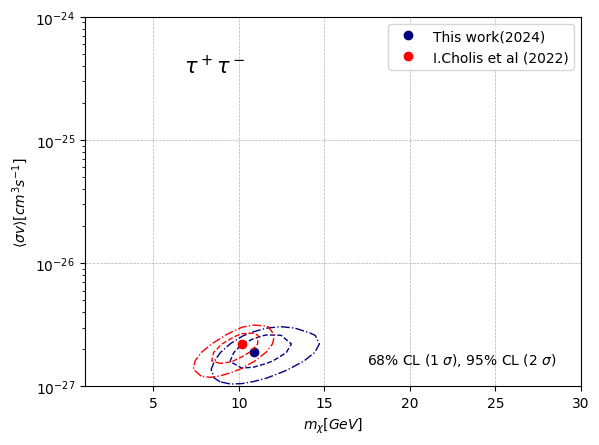

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/tau.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work(2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(1, 30)
plt.ylim(1e-27, 1e-24)
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$\tau^+ \tau^-$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


Text(0, 0.5, '$\\langle \\sigma v \\rangle$ [cm$^3$ s$^{-1}$]')

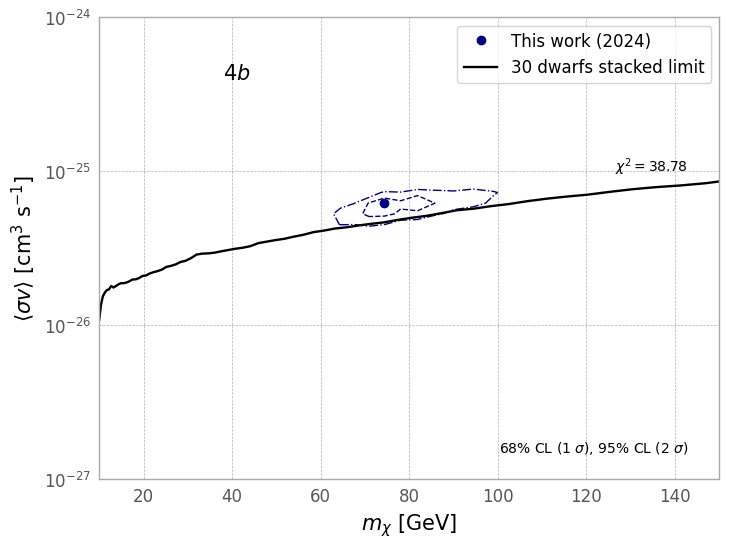

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

#plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)

#plt.title("DM interpretation of GCE for model I", fontsize=13)



Text(0, 0.5, '$\\langle \\sigma v \\rangle$ [cm$^3$ s$^{-1}$]')

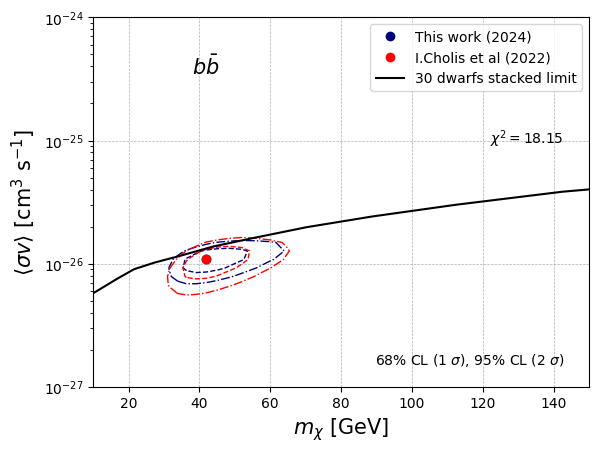

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)

#plt.title("DM interpretation of GCE for model I", fontsize=13)



Text(0, 0.5, '$\\langle \\sigma v \\rangle$ [cm$^3$ s$^{-1}$]')

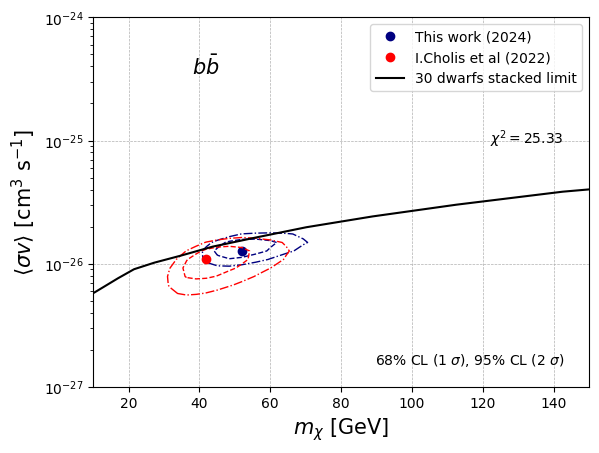

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)

#plt.title("DM interpretation of GCE for model I", fontsize=13)



In [ ]:
best_fit_dm, best_fit_sigmav

(42.597833401270954, 1.487352107293512e-26)

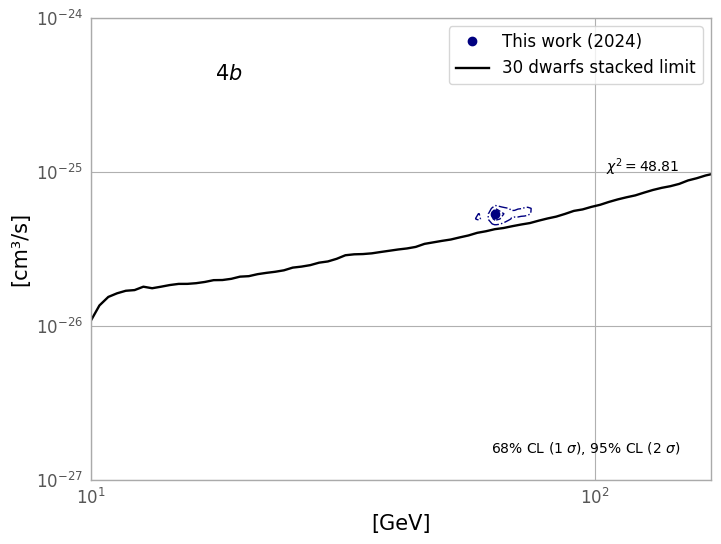

<Figure size 2000x2000 with 0 Axes>

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

#plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('log')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 170)
plt.ylim(1e-27, 1e-24)

#plt.xlim(30, 50)
#plt.ylim(1e-26, 5e-26)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
#plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)

#plt.title("DM interpretation of GCE for model I", fontsize=13)



# import matplotlib.pyplot as plt
# import pandas as pd

# solid_line_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_solid_line.txt', delim_whitespace=True)
# solid_line_x = solid_line_data['x']
# solid_line_y = solid_line_data['y']*(10**-26)

# dashed_line_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_dashed_line.txt', delim_whitespace=True)
# dashed_line_x = dashed_line_data['x']
# dashed_line_y = dashed_line_data['y']*(10**-26)

# point_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2112fig18left_best_fit_point.txt', delim_whitespace=True)
# point_x = point_data['x']
# point_y = point_data['y']*(10**-26)

# rectangle_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references/2101fig10right_DMdensity.txt', delim_whitespace=True)
# rectangle_x = rectangle_data['x']
# rectangle_y = rectangle_data['y']

# point2_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs.txt', delim_whitespace=True)
# point2_x = point2_data['x']
# point2_y = point2_data['y']

# errorbar_data = pd.read_csv('/home/FermiLAT/Sanghwan/GCE_references//2101fig10right_IEMs_errorbar.txt', delim_whitespace=True)
# error_x = errorbar_data['x']
# error_y = errorbar_data['y']
# error_yerr = errorbar_data['yerr']

# plt.plot(solid_line_x, solid_line_y, linestyle='-', color='black')#, label='Solid Line')
# plt.plot(dashed_line_x, dashed_line_y, linestyle='--', color='black')#, label='Dashed Line')
# plt.scatter(point_x, point_y, color='black', zorder=5, marker='.', label='I. Cholis (2022)', s=100)
# plt.scatter(point2_x, point2_y, color='green', label='D. Mauro (2021)', zorder=5, marker='+', s=100)
#plt.fill(rectangle_x, rectangle_y, color='gray', alpha=0.1, label='Boundary Area')

plt.xlabel('[GeV]')
plt.ylabel('[cm³/s]')
#plt.title('Combined Graph in Log-Log Scale')
plt.legend()
#plt.grid(False, which="both", ls="--", lw=0.5)
plt.figure(figsize=(20, 20))
plt.show()

In [ ]:
best_fit_dm

63.398376650646874

Text(0, 0.5, '$\\langle \\sigma v \\rangle$ [cm$^3$ s$^{-1}$]')

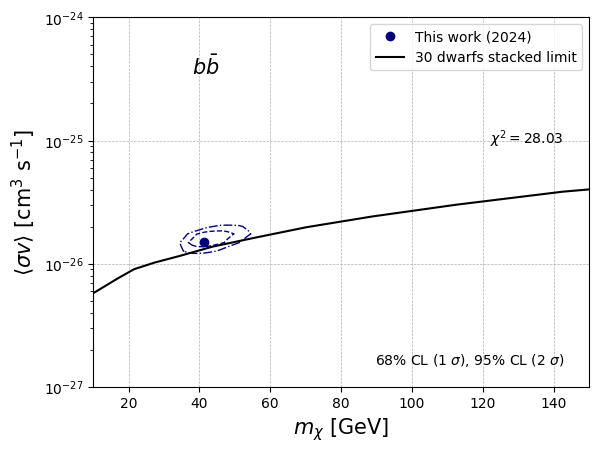

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

#plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)

#plt.title("DM interpretation of GCE for model I", fontsize=13)



(0.31332890159702786, 374.9416797515359)

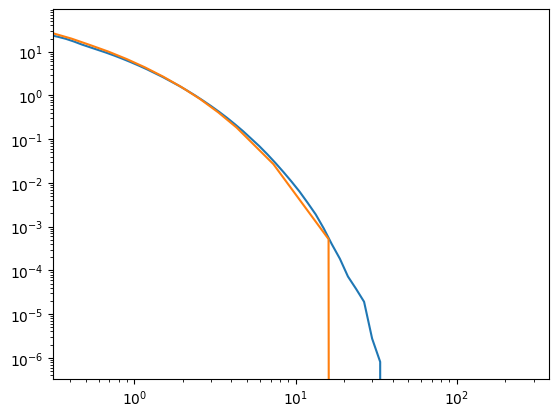

In [ ]:
plt.loglog(Interpolator(30).interpolated_table()[0], Interpolator(30).interpolated_table()[1])
plt.loglog(emeans, exctractcirellitable(30, 13, 'gammas', 'Yes') )
plt.xlim(emeans[0], emeans[-1])

In [ ]:
Interpolator(30).interpolated_table()[1]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

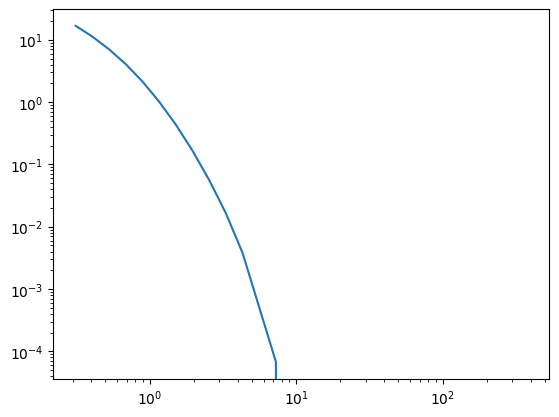

In [ ]:
plt.loglog(emeans, exctractcirellitable(9, 13, 'gammas', 'Yes') )

In [ ]:
'/home/sanghwan/Madgraph_2/MG5_aMC_v2_9_18/bin/test_bb/Events/DM105.54GeV/DM105.54GeV_gamma.da

Text(0, 0.5, '$\\langle \\sigma v \\rangle$ [cm$^3$ s$^{-1}$]')

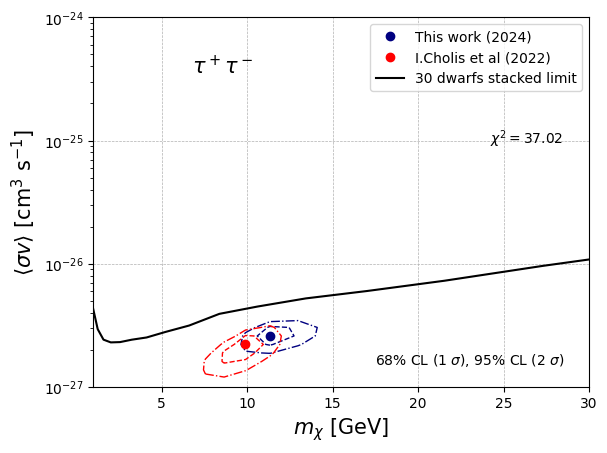

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/tau.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(1, 30)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$\tau^+ \tau^-$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)

#plt.title("DM interpretation of GCE for model I", fontsize=13)



Text(0, 0.5, '$\\langle \\sigma v \\rangle$ [cm$^3$ s$^{-1}$]')

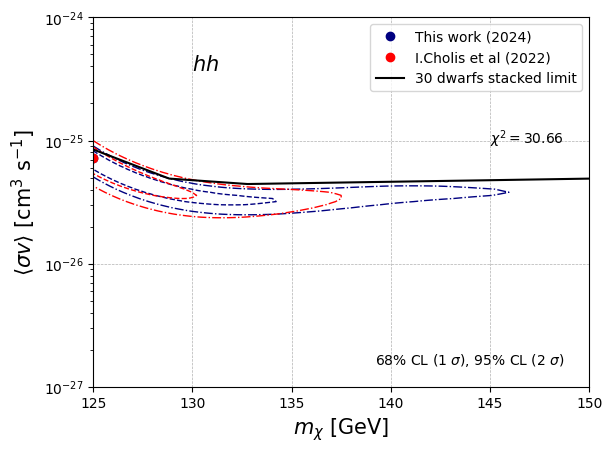

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/hh.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(125, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$hh$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]', fontsize=15)
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]', fontsize=15)

#plt.title("DM interpretation of GCE for model I", fontsize=13)



In [ ]:
min_chi2, min_chi2_I

(32.7322781982104, 34.49793366907972)

Text(0, 0.5, '$\\langle \\sigma v \\rangle$ [cm$^3$ s$^{-1}$]')

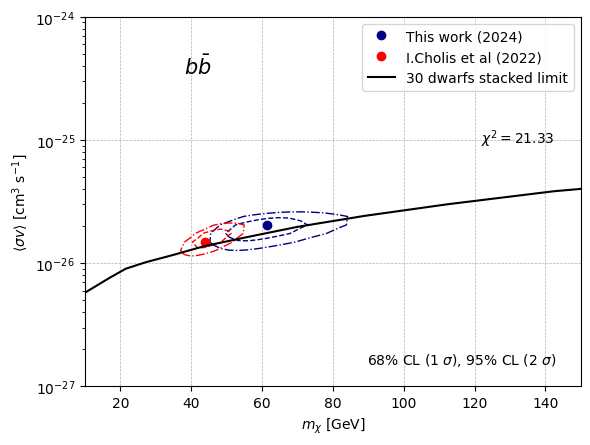

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]')
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]')


Text(0, 0.5, '$\\langle \\sigma v \\rangle$ [cm$^3$ s$^{-1}$]')

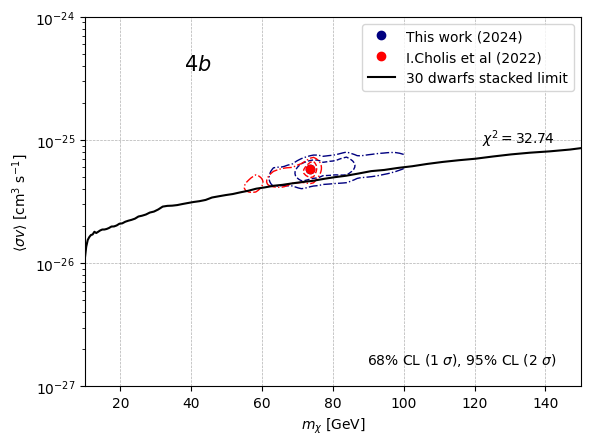

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$\chi^2 = {}$ '.format(np.round(min_chi2, 2)), fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'4$b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi$ [GeV]')
plt.ylabel(r'$\langle \sigma v \rangle$ [cm$^3$ s$^{-1}$]')


Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

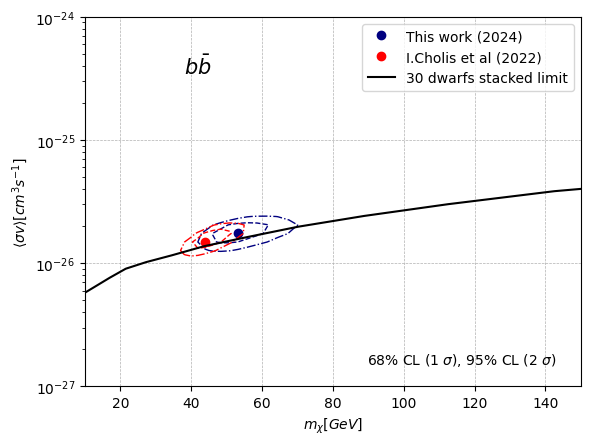

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
min_chi2/15

2.3029279427689433

In [ ]:
min_chi2_I/12

4.363779463814119

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

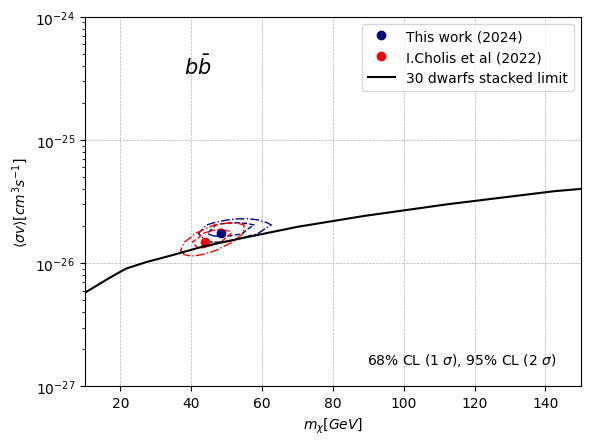

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
model XLIX

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

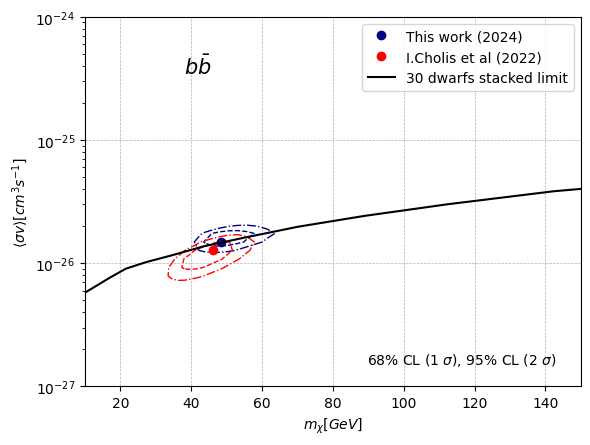

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
model X

In [ ]:
min_chi2/15

1.0152019403159247

In [ ]:
best_fit_dm, best_fit_sigmav

(46.128300997787484, 1.7433288221999943e-26)

In [ ]:
min_chi2

24.426863369429366

In [ ]:
min_chi2_I/12

1.9611003582498512

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

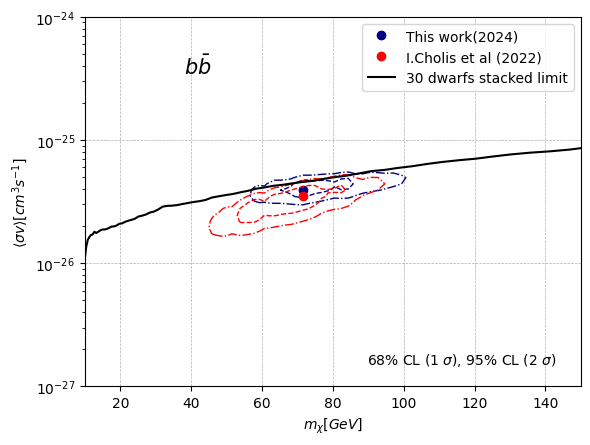

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work(2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$b\bar{b}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

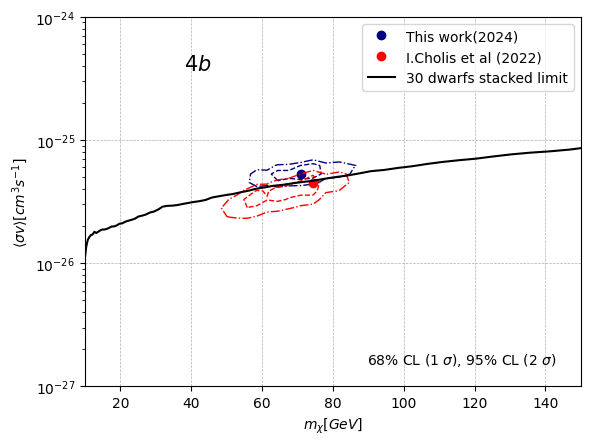

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work(2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 150)
plt.ylim(1e-27, 1e-24)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$4b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

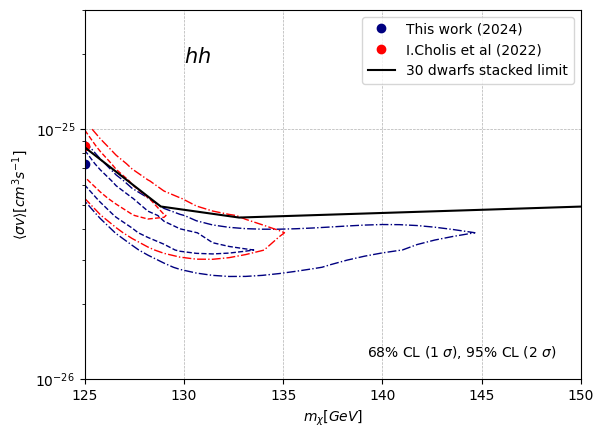

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/hh.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work (2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='dwarf galaxy upper limit(2023)', color='black')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(125, 150)
plt.ylim(1e-26, 3e-25)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.2, 0.90, r'$hh$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
min_chi2, min_chi2_I

(23.874933961499313, 23.32278428186855)

In [ ]:
best_fit_dm, best_fit_sigmav

(124.99999999999994, 7.038135554931547e-26)

In [ ]:
best_fit_dm_I

74.40024273975517

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

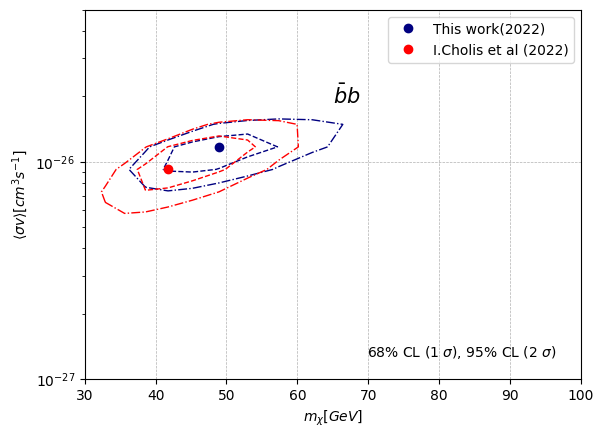

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work(2022)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(30, 100)
plt.ylim(1e-27, 5e-26)
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.5, 0.80, r'$\bar{b}$$b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
min_chi2/12, min_chi2_I/12

(1.4189904755066192, 1.7459960576135864)

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

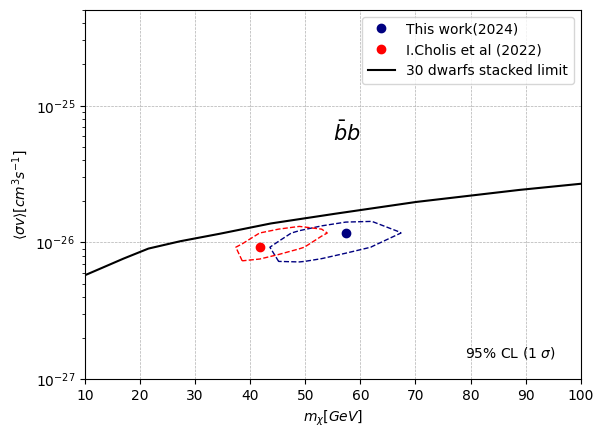

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work(2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 100)
plt.ylim(1e-27, 5e-25)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'95% CL (1 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.5, 0.70, r'$\bar{b}$$b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
min_chi2/12, min_chi2_I/12

(1.4852426164539805, 1.7459960576135864)

Text(0.95, 0.6, '$h_2 h_2$ $m_{h2} = 75 GeV$')

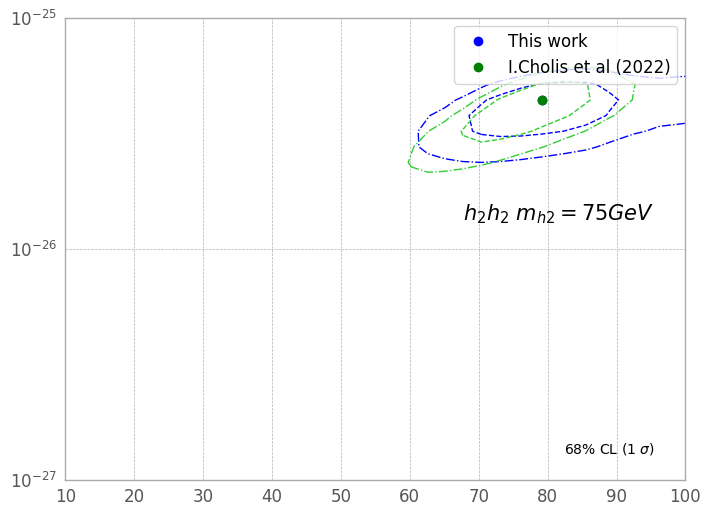

In [ ]:
plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='blue', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label='This work', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='limegreen', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'go', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 100)
plt.ylim(1e-27, 1e-25)
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


plt.text(0.95, 0.05, r'68% CL (1 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.60, r'$h_2 h_2$ $m_{h2} = 75 GeV$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)


Text(0.95, 0.6, '$h_2 h_2$, $m_{h2}$ =55 $GeV$')

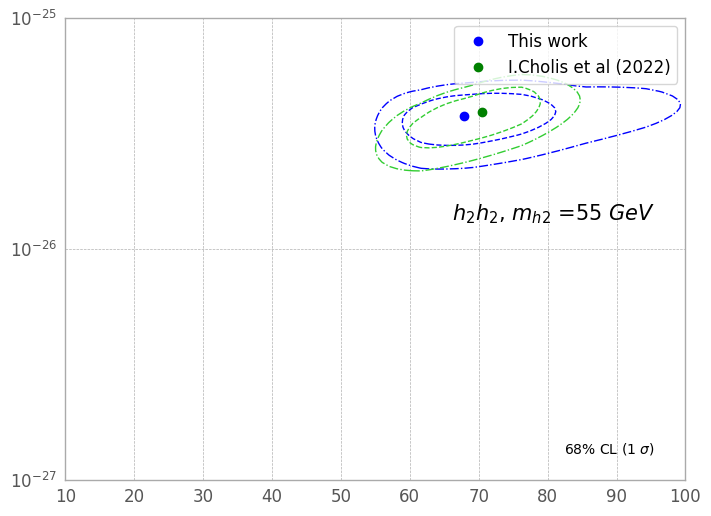

In [ ]:
plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='blue', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label='This work', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='limegreen', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'go', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 100)
plt.ylim(1e-27, 1e-25)
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


plt.text(0.95, 0.05, r'68% CL (1 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.60, r'$h_2 h_2$, $m_{h2}$ =55 $GeV$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)


Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

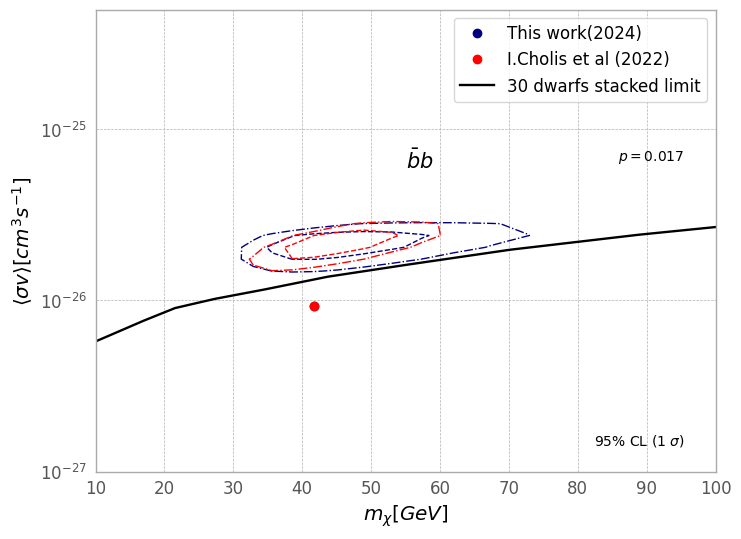

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work(2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 100)
plt.ylim(1e-27, 5e-25)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'95% CL (1 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.5, 0.70, r'$\bar{b}$$b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

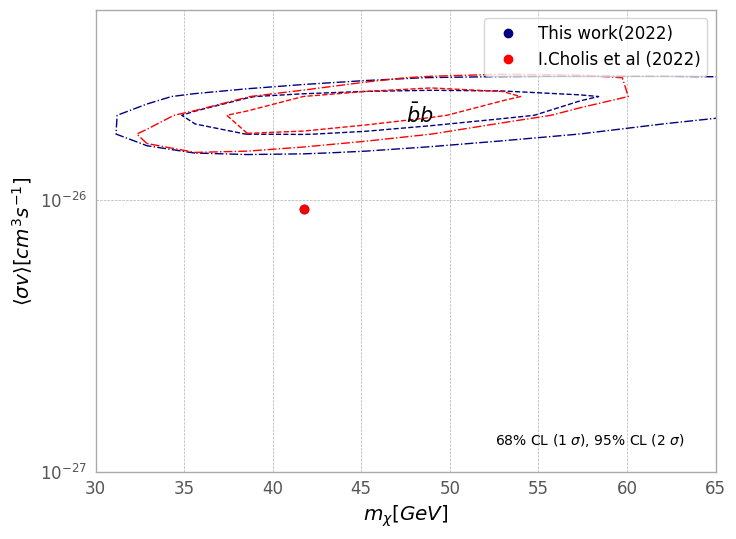

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work(2022)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(30, 65)
plt.ylim(1e-27, 5e-26)
#plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'68% CL (1 $\sigma$), 95% CL (2 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
#         verticalalignment='top', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.text(0.5, 0.80, r'$\bar{b}$$b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

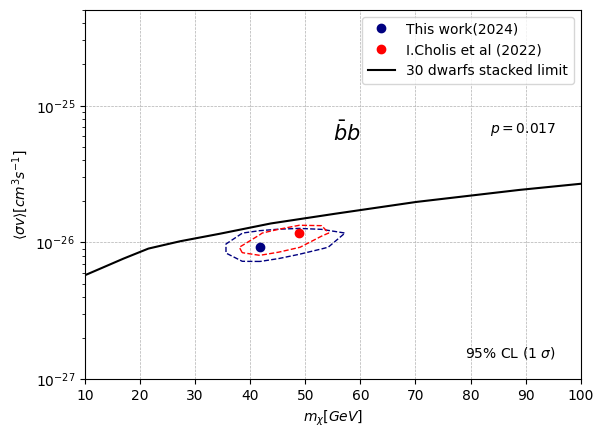

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work(2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 100)
plt.ylim(1e-27, 5e-25)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'95% CL (1 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$p=0.017$', fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.5, 0.70, r'$\bar{b}$$b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
best_fit_sigmav, best_fit_sigmav_I

(9.236708571873847e-27, 1.1721022975334842e-26)

In [ ]:
min_chi2/12, min_chi

1.4801860510085423

In [ ]:
best_fit_sigmav, best_fit_sigmav_I

(2.395026619987491e-26, 2.395026619987491e-26)

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

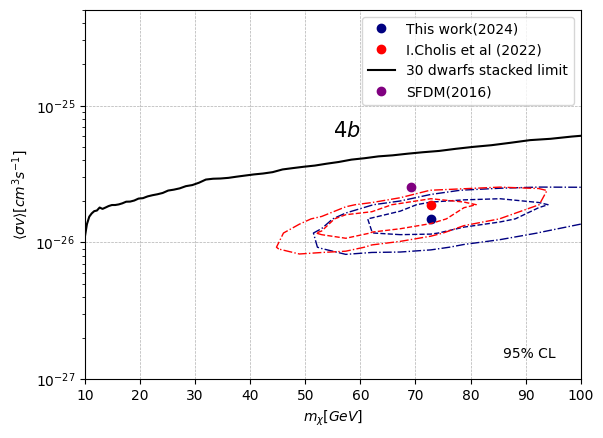

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/4b.txt')


plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o',color='navy', label='This work(2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(10, 100)
plt.ylim(1e-27, 5e-25)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')

plt.plot(69.2, 2.54e-26, 'o', color='purple' , label='SFDM(2016)')


plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid

plt.text(0.95, 0.05, r'95% CL', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
#plt.text(0.95, 0.70, r'$p=0.01$', fontsize=10, color='black',verticalalignment='top', horizontalalignment='right',transform=plt.gca().transAxes)

plt.text(0.5, 0.70, r'$4b$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

#plt.text(0.5-0.3, 0.70, r'$J=2.54\bar{J}$', fontsize=15, color='black',
#         verticalalignment='top', horizontalalignment='left',
#         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
min_chi2_I/12

1.9592375936596913

In [ ]:
best_fit_dm, best_fit_dm_I

(72.7895384398315, 72.7895384398315)

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

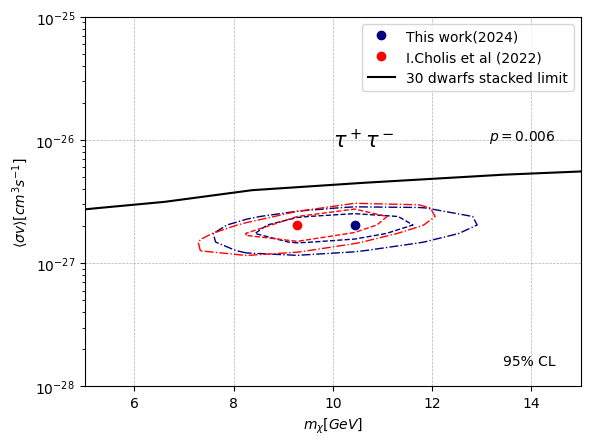

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/tau.txt')

plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
#plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o', color='navy',label='This work(2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
#plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(5, 15)
plt.ylim(1e-28, 1e-25)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


plt.text(0.95, 0.05, r'95% CL', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$p=0.006$', fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.5, 0.70, r'$\tau^+$$\tau^-$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
min_chi2/12

2.890645481750044

In [ ]:
min_chi2_I/12

1.890761598708303

In [ ]:
min_chi2/12

1.611139538185087

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

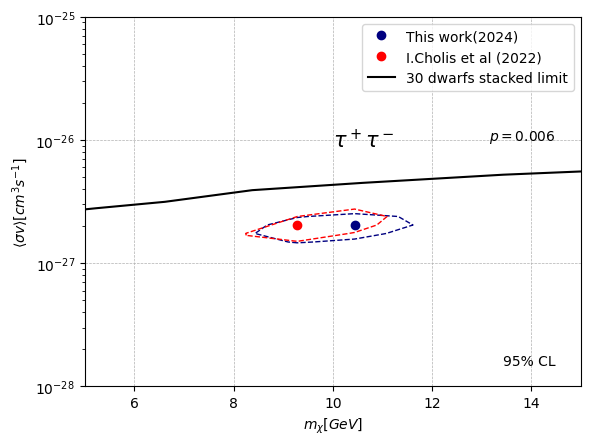

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/tau.txt')

#plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold]), colors='navy', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'o', color='navy',label='This work(2024)', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

#plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I]), colors='red', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'ro', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(5, 15)
plt.ylim(1e-28, 1e-25)
plt.plot(ulm[0:, 0], ulm[0:, 1], label='30 dwarfs stacked limit', color='black')
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


plt.text(0.95, 0.05, r'95% CL', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.70, r'$p=0.006$', fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

plt.text(0.5, 0.70, r'$\tau^+$$\tau^-$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='left',
         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
min_chi2/12

1.611139538185087

In [ ]:
best_fit_dm, best_fit_dm_I

(10.4400917075454, 9.284726129275331)

In [ ]:
cov=np.loadtxt('/home/sanghwan/C.Weniger/covariance.dat')

In [ ]:
np.sqrt(np.diag(cov))

array([5.47722568e-01, 6.32455537e-01, 3.72820044e-04, 2.81605097e-04,
       2.47608060e-07, 2.72895296e-07, 2.74737603e-07, 2.59715697e-07,
       2.51970290e-07, 2.53158909e-07, 2.72033506e-07, 2.34066646e-07,
       2.38360314e-07, 2.15372738e-07, 2.25068068e-07, 2.05760579e-07,
       1.83814246e-07, 1.63657568e-07, 1.40202738e-07, 1.53403265e-07,
       1.28265510e-07, 1.05915198e-07, 8.19694704e-08, 5.86296315e-08])

Text(0.95, 0.8, '$\\mu^+$$\\mu^{-}$')

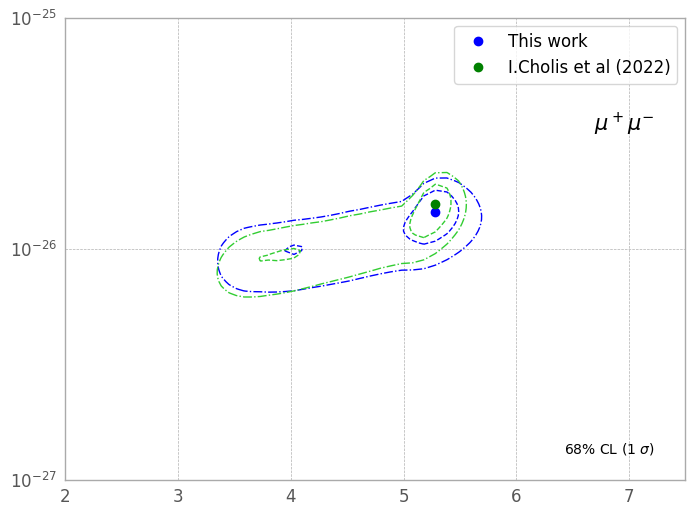

In [ ]:
plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='blue', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label='This work', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='limegreen', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'go', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(2, 7.5)
plt.ylim(1e-27, 1e-25)
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


plt.text(0.95, 0.05, r'68% CL (1 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.80, r'$\mu^+$$\mu^{-}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)


Text(0.95, 0.8, '$e^+$$e^{-}$')

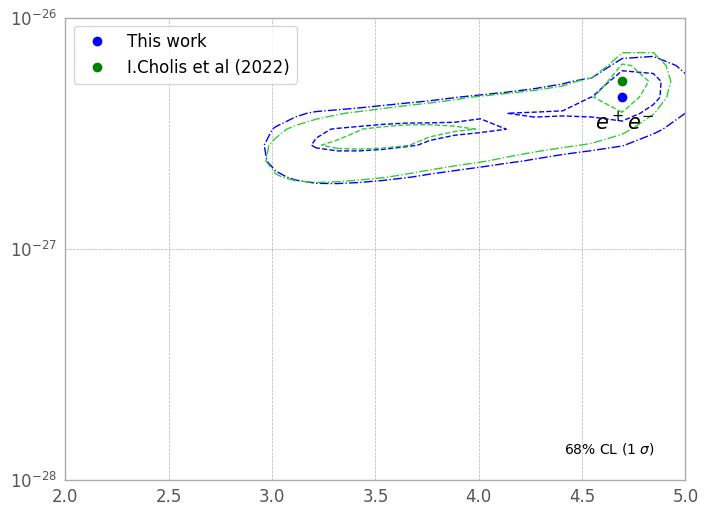

In [ ]:
plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='blue', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label='This work', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='limegreen', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'go', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(2, 5)
plt.ylim(1e-28, 1e-26)
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


plt.text(0.95, 0.05, r'68% CL (1 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.80, r'$e^+$$e^{-}$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)


Text(0.95, 0.8, '$hh$')

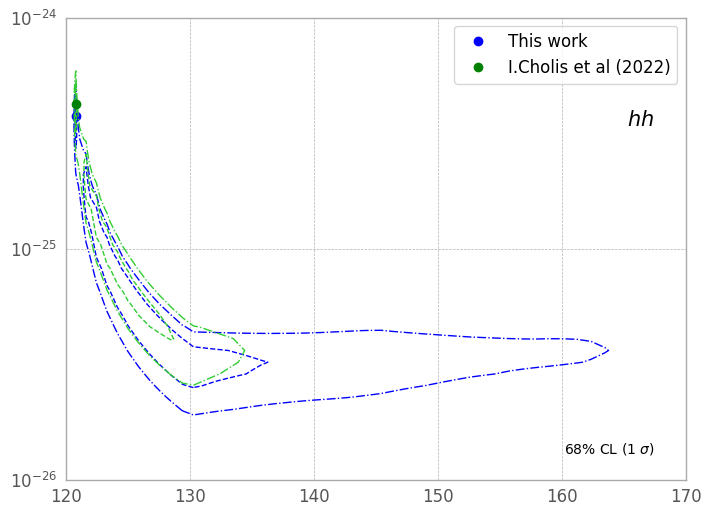

In [ ]:
plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([one_sigma_threshold, two_sigma_threshold]), colors='blue', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label='This work', alpha=1)

#plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
#plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([one_sigma_threshold_I, two_sigma_threshold_I]), colors='limegreen', linestyles=['--', '-.'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'go', label='I.Cholis et al (2022)', alpha=1)


plt.yscale('log')
plt.xscale('linear')
#ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.plot(ulm[0:, 0], ulm[0:, 1])
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'ro', label='SFDM reference value')
plt.xlim(120, 170)
plt.ylim(1e-26, 1e-24)
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


plt.text(0.95, 0.05, r'68% CL (1 $\sigma$)', fontsize=10, color='black',
         verticalalignment='bottom', horizontalalignment='right',
         transform=plt.gca().transAxes)
plt.text(0.95, 0.80, r'$hh$', fontsize=15, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)


In [ ]:
best_fit_dm, best_fit_sigmav

(120.82751500082526, 3.7693909753883634e-25)

In [ ]:
best_fit_dm_I, best_fit_sigmav_I

(120.82751500082526, 4.237587160604055e-25)

In [ ]:
best_fit_dm, best_fit_sigmav

(45.33893187678606, 1.0597662486760708e-26)

In [ ]:
best_fit_dm_I, best_fit_sigmav_I

(45.33893187678606, 1.0597662486760708e-26)

In [ ]:
min_chi2_I/12

1.8617525834790165

In [ ]:
best_fit_dm, best_fit_sigmav

(10.628551770039401, 2.2695105366946686e-27)

In [ ]:
best_fit_dm_w, best_fit_sigmav_w

(9.47113845233269, 3.625117049988528e-27)

In [ ]:
best_fit_dm_I, best_fit_sigmav_I

(9.654893846056297, 2.1544346900318777e-27)

Text(0, 0.5, '$\\langle \\sigma v \\rangle [cm^3 s^{-1}] $')

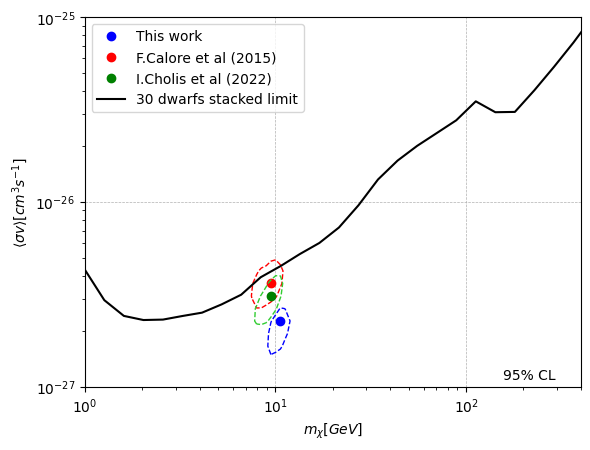

In [ ]:
#plt.pcolormesh(mass_vec, sigmav_vec, chi_square_vec(DM_mass, Sigmav), vmax=min_chi2+100, vmin=min_chi2,cmap='inferno', alpha=0.5)
#plt.pcolormesh(mass_vec, sigmav_vec, chi_square_results, vmax=min_chi2+100, vmin=min_chi2,cmap='inferno', alpha=0.5)
#plt.colorbar()
plt.contour(mass_vec, sigmav_vec, chi_square_results, levels=np.array([two_sigma_threshold]), colors='blue', linestyles=['--'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm, best_fit_sigmav, 'bo', label='This work')

plt.contour(mass_vec, sigmav_vec, chi_square_w_results, levels=np.array([two_sigma_threshold_w]), colors='red', linestyles=['--'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_w, best_fit_sigmav_w, 'ro', label='F.Calore et al (2015)')

plt.contour(mass_vec, sigmav_vec, chi_square_I_results, levels=np.array([two_sigma_threshold_I]), colors='limegreen', linestyles=['--'], linewidths=3*[1],alpha=1)
plt.plot(best_fit_dm_I, best_fit_sigmav_I, 'go', label='I.Cholis et al (2022)')


plt.yscale('log')
plt.xscale('log')


ulm=np.loadtxt(f'/home/FermiLAT/Sanghwan/dwarf_galaxy/tau.txt')
plt.plot(ulm[0:, 0], ulm[0:, 1], color='black', linestyle='-', label='30 dwarfs stacked limit')
#plt.plot(9.96, 0.336*1e-26, 'bo', label='Paper reference value')
#plt.plot(40, 1.4e-26, 'bo', label='Paper reference value')
#plt.plot(38.2, 1.25*1e-26, 'bo', label='Paper reference value')
#plt.plot(49, 1.7e-26, 'bo', label='Paper reference value')
#plt.plot(69.2, 2.26*2.2e-26, 'co', label='SFDM reference value')



plt.xlim(1, 400)
plt.ylim(1e-27, 1e-25)
plt.legend()
plt.grid(True, which='major', linestyle='--', linewidth=0.5)  # Add this line to enable grid


plt.text(0.95, 0.05, '95% CL', fontsize=10, color='black',
         verticalalignment='top', horizontalalignment='right',
         transform=plt.gca().transAxes)

#plt.text(0.95, 0.05, r'$m_{h2}$ = 35 $GeV$', fontsize=15, color='black',
#         verticalalignment='bottom', horizontalalignment='right',
#         transform=plt.gca().transAxes)

plt.xlabel(r'$m_\chi [GeV]$')
plt.ylabel(r'$\langle \sigma v \rangle [cm^3 s^{-1}] $')


In [ ]:
min_chi2_I

54.48418168025135

(1e-27, 1e-24)

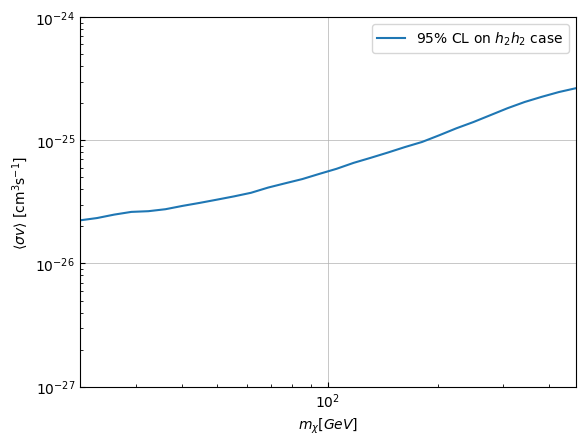

In [ ]:
plt.style.use('default')
plt.tick_params(axis='y', which='both', direction='in', left=True)
plt.tick_params(axis='x', which='both', direction='in', bottom=True)
plt.minorticks_on()
plt.grid(True, which='Major', linestyle='-', linewidth=0.5)

#plt.ylabel(f'$\langle$ $\sigma$ v $\rangle$]')
plt.ylabel(r'$\langle \sigma v \rangle \ [\mathrm{cm}^3 \mathrm{s}^{-1}]$')
plt.xlabel(r'$m_{\chi}[GeV]$')

ulm=np.loadtxt('../dwarf_galaxy/SFDM_h2h2_15GeV.txt')
plt.loglog(ulm[0:, 0], ulm[0:, 1], label=r'95% CL on $h_2 h_2$ case')
plt.legend()
plt.xlim(ulm[0,0], ulm[-1, 0])
plt.ylim(1e-27, 1e-24)

In [ ]:
best_fit_dm, best_fit_sigmav

(19.30978769211259, 5.994842503189421e-27)

In [ ]:
best_fit_dm_w, best_fit_sigmav_w

(8.85849613163886, 2.1544346900318777e-27)

In [ ]:
min_chi2/22

0.790102793798588

In [ ]:
ulm[0:, 0]

array([1.00000000e+00, 1.26638017e+00, 1.60371874e+00, 2.03091762e+00,
       2.57191381e+00, 3.25702066e+00, 4.12462638e+00, 5.22334507e+00,
       6.61474064e+00, 8.37677640e+00, 1.06081836e+01, 1.34339933e+01,
       1.70125428e+01, 2.15443469e+01, 2.72833338e+01, 3.45510729e+01,
       4.37547938e+01, 5.54102033e+01, 7.01703829e+01, 8.88623816e+01,
       1.12533558e+02, 1.42510267e+02, 1.80472177e+02, 2.28546386e+02,
       2.89426612e+02, 3.66524124e+02, 4.64158883e+02, 5.87801607e+02,
       7.44380301e+02, 9.42668455e+02, 1.19377664e+03, 1.51177507e+03,
       1.91448198e+03, 2.42446202e+03, 3.07029063e+03, 3.88815518e+03,
       4.92388263e+03, 6.23550734e+03, 7.89652287e+03, 1.00000000e+04])

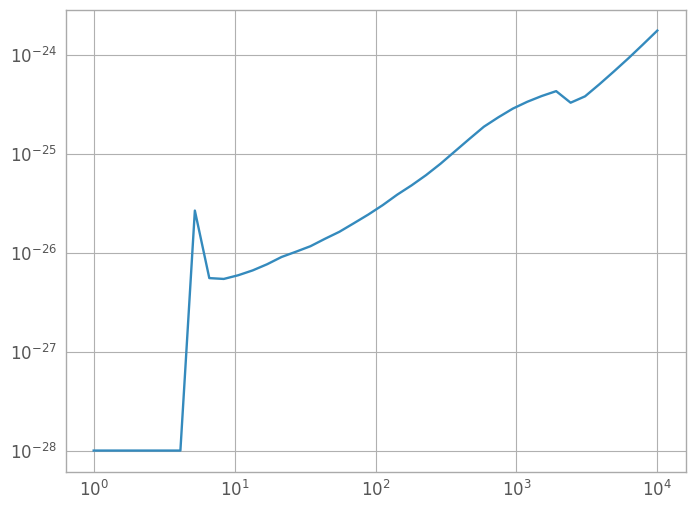

In [ ]:
ulm=np.loadtxt('/home/FermiLAT/Sanghwan/dwarf_galaxy/bb_upper_limit.txt')
#plt.xlim(7, 1e+4)
plt.loglog()
plt.plot(ulm[0:, 0], ulm[0:, 1])


In [ ]:
min_chi2/22

1.5744554256276693

In [ ]:
best_fit_dm, best_fit_sigmav

(62.14465011907717, 1.6681005372000557e-26)

In [ ]:
best_fit_dm_w, best_fit_sigmav_w

(8.85849613163886, 2.1544346900318777e-27)

In [ ]:
a=fits.open('/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/ics_modelF.fits')[0].data

In [ ]:
E_bounds

FITS_rec([( 1,   300000.  , 3.5000000e+05),
          ( 2,   350000.  , 4.0000000e+05),
          ( 3,   400000.  , 4.5000000e+05),
          ( 4,   450000.  , 5.0000000e+05),
          ( 5,   500000.  , 5.5745119e+05),
          ( 6,   557451.2 , 6.2499312e+05),
          ( 7,   624993.1 , 7.0508119e+05),
          ( 8,   705081.2 , 8.0095475e+05),
          ( 9,   800954.75, 9.1695450e+05),
          (10,   916954.5 , 1.0589995e+06),
          (11,  1058999.5 , 1.2353219e+06),
          (12,  1235321.9 , 1.4576299e+06),
          (13,  1457629.9 , 1.7430094e+06),
          (14,  1743009.4 , 2.1171480e+06),
          (15,  2117148.  , 2.6200380e+06),
          (16,  2620038.  , 3.3165858e+06),
          (17,  3316585.8 , 4.3175725e+06),
          (18,  4317572.5 , 5.8242265e+06),
          (19,  5824226.5 , 8.2321720e+06),
          (20,  8232172.  , 1.2404649e+07),
          (21, 12404649.  , 2.0517116e+07),
          (22, 20517116.  , 3.9361808e+07),
          (23, 39361808.  , 9.93

In [ ]:
fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits')[1].data

FITS_rec([(3.00000000e+02,), (3.50000000e+02,), (4.00000000e+02,),
          (4.50000000e+02,), (5.00000000e+02,), (5.57451187e+02,),
          (6.24993125e+02,), (7.05081188e+02,), (8.00954750e+02,),
          (9.16954500e+02,), (1.05899950e+03,), (1.23532188e+03,),
          (1.45762988e+03,), (1.74300938e+03,), (2.11714800e+03,),
          (2.62003800e+03,), (3.31658575e+03,), (4.31757250e+03,),
          (5.82422650e+03,), (8.23217200e+03,), (1.24046490e+04,),
          (2.05171160e+04,), (3.93618080e+04,), (9.93371840e+04,),
          (5.00000000e+05,)], dtype=(numpy.record, [('Energy', '>f8')]))

In [ ]:
fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits')[1].data

FITS_rec([(3.00000000e+02,), (3.50000000e+02,), (4.00000000e+02,),
          (4.50000000e+02,), (5.00000000e+02,), (5.57451187e+02,),
          (6.24993125e+02,), (7.05081188e+02,), (8.00954750e+02,),
          (9.16954500e+02,), (1.05899950e+03,), (1.23532188e+03,),
          (1.45762988e+03,), (1.74300938e+03,), (2.11714800e+03,),
          (2.62003800e+03,), (3.31658575e+03,), (4.31757250e+03,),
          (5.82422650e+03,), (8.23217200e+03,), (1.24046490e+04,),
          (2.05171160e+04,), (3.93618080e+04,), (9.93371840e+04,),
          (5.00000000e+05,)], dtype=(numpy.record, [('Energy', '>f8')]))

In [ ]:
# Revision :: Jul 4, 2024

#In case of Logarithmic scale, central points should be considered logarithmically

model='F'
E_bounds=fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ccube_masked.fits')[1].data
E=np.zeros(len(E_bounds))
for i in range(0, 4, 1):
    E[i] = 1e-3*(E_bounds[i][2] + E_bounds[i][1])/2
for i in range(4, len(E_bounds), 1):
    E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)
    
delta_E=np.zeros(len(E_bounds))
for i in range(0, len(E_bounds), 1):
    delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-3
    

exp_cube=fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits')[0].data
for i in range(0, 4, 1):
    exp_cube[i] = ( fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits')[0].data[i] + fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits')[0].data[i+1] )/2
for i in range(4, len(exp_cube)-1, 1):
    exp_cube[i] = np.sqrt(fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits')[0].data[i]*fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits')[0].data[i+1])

file_name='/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/psc.fits'
psc=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    psc[i] = np.sum(fits.open(file_name)[0].data[i]/a)

file_name=f'/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/pion_model{model}.fits'
pion=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    pion[i] = np.sum(fits.open(file_name)[0].data[i]/a)

file_name=f'/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/bremss_model{model}.fits'
bremss=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    bremss[i] = np.sum(fits.open(file_name)[0].data[i]/a)
    
file_name=f'/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/ics_model{model}.fits'
ics=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    ics[i] = np.sum(fits.open(file_name)[0].data[i]/a)
    
file_name='/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/GCE.fits'
GCE=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    GCE[i] = np.sum(fits.open(file_name)[0].data[i]/a)
    
file_name='/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/fermi_bubble.fits'
bubble=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    bubble[i] = np.sum(fits.open(file_name)[0].data[i]/a)
    
file_name='/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/isotropic.fits'
isotropic=np.zeros(len(fits.open(file_name)[0].data))
for i in range(0, len(fits.open(file_name)[0].data), 1):
    a=exp_cube[i]
    isotropic[i] = np.sum(fits.open(file_name)[0].data[i]/a)
    
counts_per_exp=np.zeros(len(E))
i=0
for i in range(0, len(E), 1):
    a=exp_cube[i]
    counts_per_exp[i]=np.sum( ( (fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ccube_masked.fits')[0].data[i]) /a))

counts_per_exp_err=np.zeros(len(E))
i=0
for i in range(0, len(E), 1):
    a=exp_cube[i]
    counts_per_exp_err[i]=np.sqrt( np.sum( ( np.sqrt(fits.open('/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ccube_masked.fits')[0].data[i]) /a)**2) )
    
sr=0.214411*2
    

In [ ]:
counts_per_exp_err

array([3.87677169e-09, 3.24696991e-09, 2.77764086e-09, 2.42440943e-09,
       2.28242745e-09, 2.15844184e-09, 2.03131642e-09, 1.91698469e-09,
       1.79789516e-09, 1.65527154e-09, 1.52872657e-09, 1.39824740e-09,
       1.27241646e-09, 1.15306728e-09, 1.05006564e-09, 9.41745545e-10,
       8.41830360e-10, 7.31173041e-10, 6.12011680e-10, 4.98324491e-10,
       3.91072286e-10, 2.89275910e-10, 1.93720071e-10, 1.14405533e-10])

In [ ]:
counts_per_exp_err

array([2.31076579e-08, 1.77529826e-08, 1.40970213e-08, 1.15369350e-08,
       1.08812671e-08, 1.04194768e-08, 9.92596491e-09, 9.48079138e-09,
       9.04289205e-09, 8.53067083e-09, 8.18861056e-09, 7.64602963e-09,
       7.26828290e-09, 6.57598135e-09, 6.25352224e-09, 5.54424049e-09,
       4.81639613e-09, 4.04149497e-09, 2.98267999e-09, 1.80172312e-09,
       8.94658483e-10, 4.10925556e-10, 2.32358437e-10, 1.22104783e-10])

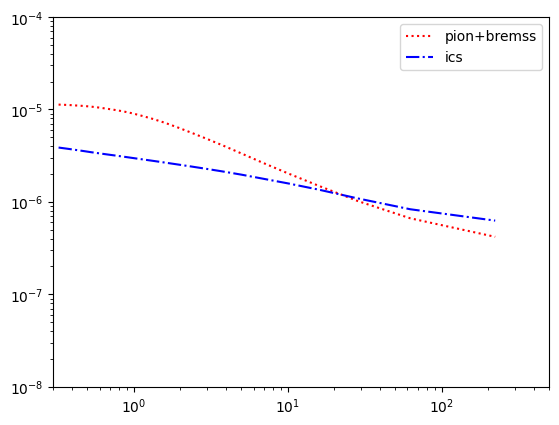

In [ ]:
plt.style.use('default')

plt.ylim(1e-8, 1e-4)
plt.xlim(0.3, 500)

plt.loglog()
plt.plot(E*1e-3, (pion+bremss)*(E**2)/(1000*delta_E*sr), linestyle='dotted', label='pion+bremss', color='red')
plt.plot(E*1e-3, (ics)*(E**2)/(1000*delta_E*sr), linestyle='dashdot', label='ics', color='blue')
plt.legend()

In [ ]:
%%bash
gtmodel outtype=ccube
    /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_srcmap_model_f_masked.fits
    /home/FermiLAT/Sanghwan/GC_14yr/data/Model/ics_modelF.xml
    /home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/ics_modelF_new.fits
    P8R3_ULTRACLEANVETO_V3
    /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ltcube.fits
    /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits

Source maps (or counts map) file[/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_srcmap_model_a_masked.fits]     /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_srcmap_model_f_masked.fits
    /home/FermiLAT/Sanghwan/GC_14yr/data/Model/ics_modelF.xmlbremss_modelF.xml]  
Output file[/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/bremss_modelF_new.fits]     /home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/ics_modelF_new.fits
Response functions[P8R3_ULTRACLEANVETO_V3]     P8R3_ULTRACLEANVETO_V3
Exposure cube[/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ltcube.fits]     /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ltcube.fits
Binned exposure map[/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits]     /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits


In [ ]:
%%bash
gtmodel outtype=ccube
    /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_srcmap_model_f_masked.fits
    /home/FermiLAT/Sanghwan/GC_14yr/data/Model/pion_modelF.xml
    /home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/pion_modelF_new.fits
    P8R3_ULTRACLEANVETO_V3
    /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ltcube.fits
    /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits

Source maps (or counts map) file[/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_srcmap_model_f_masked.fits]     /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_srcmap_model_f_masked.fits
Source model file[/home/FermiLAT/Sanghwan/GC_14yr/data/Model/ics_modelF.xml]     /home/FermiLAT/Sanghwan/GC_14yr/data/Model/pion_modelF.xml
    /home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/pion_modelF_new.fitsew.fits]  
Response functions[P8R3_ULTRACLEANVETO_V3]     P8R3_ULTRACLEANVETO_V3
Exposure cube[/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ltcube.fits]     /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ltcube.fits
Binned exposure map[/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits]     /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits


In [ ]:
%%bash
gtmodel outtype=ccube
    /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_srcmap_model_f_masked.fits
    /home/FermiLAT/Sanghwan/GC_14yr/data/Model/bremss_modelF.xml
    /home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/bremss_modelF_new.fits
    P8R3_ULTRACLEANVETO_V3
    /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ltcube.fits
    /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits

Source maps (or counts map) file[/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_srcmap_model_f_masked.fits]     /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_srcmap_model_f_masked.fits
Source model file[/home/FermiLAT/Sanghwan/GC_14yr/data/Model/pion_modelF.xml]     /home/FermiLAT/Sanghwan/GC_14yr/data/Model/bremss_modelF.xml
Output file[/home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/pion_modelF_new.fits]     /home/FermiLAT/Sanghwan/GC_14yr/data/Model_Map/bremss_modelF_new.fits
Response functions[P8R3_ULTRACLEANVETO_V3]     P8R3_ULTRACLEANVETO_V3
Exposure cube[/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ltcube.fits]     /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_ltcube.fits
Binned exposure map[/home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits]     /home/FermiLAT/Sanghwan/GC_14yr/GC_14yr_expcube.fits
